# Предсказание клика рекламы Advandex

ССылка на проект на Git Hub:

https://github.com/Konopatskaya/Ad_click

_____

**Название проекта**  Прогноз вероятности клика (CTR) на рекламное объявление

_____
**Описание исследования.** Компания Advandex занимается проведением реклаиных аукционов. Она выступает посредником между рекламодателями, желающими продвигать свои товары, и издателями — сайтами и приложениями, которые показывают рекламу. Задача Advandex — выбрать лучшее объявление для конкретного пользователя и конкурировать с другими платформами за право контролировать рекламный слот.

Для улучшения качества работы сервиса критически важно повысить точность прогноза коэффициента кликабельности CTR. Если вероятность клика предсказана неточно, платформа примет ошибочное решение в аукционе и потеряет доход.

    1. Тип: Задача обучения с учителем
    
    2. Целевая переменная (Target) - `clik`, бинарный признак, где:
    - 1 - был совершён клик по баннеру (положительный класс "positive")
    - 0 - клика не было(отрицательный класс "negative")
_____
**Цель исследования.** построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление

Бизнес-контекст и цель:

- Проблема: низкое качество прогноза CTR, что приводит к: 
  - низкой эффективности рекламы. Средний CTR на платформе Advandex составляет около 0.05%, что существенно ниже типичных значений 1–1.5% в аналогичных цифровых каналах.
  - недовольство рекламодателей
  - прямые финансовые потери для платформы. Advandex получает доход только при кликах (модель CPC). улучшение CTR приведёт к существенному увеличению ежедневной и годовой выручки. 
- Цель бизнеса: Увеличить прибыли, за счёт повышения качественного прогноза CTR.
- Цель ML: построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление. Это позволит повысить эффективность рекламы, привлечь рекламодателей, а, следовательно, увеличить прибыль Advandex. 
    
_____
**Задачи исследования.**

1.	Изучение данных и предобработка: 

-	Ознакомьться с исходным датасетом, изучить признаки устройства пользователя (возраст, устройство, время, история кликов) и характеристики рекламы (тематика, формат, место показа).
-	Выполнить базовую очистку данных: уберать пропуски, выделить категориальные и числовые признаки.
-	Провести базовый анализ распределений и взаимосвязей входных признаков с целевой переменной.
2.	Отбор признаков: 

-	Для заполнения пропусков в числовых признаках использовать медиану или среднее. 
-	Выполнить масштабирование числовых данных, если это необходимо.
-	Применить One-Hot Encoding для признаков с малым числом уникальных категорий. Применить Target Encoding для признаков с высокой кардинальностью — например, для site_domain.
-	Применить фильтрационные методы отбора признаков — рассчитайть коэффициент корреляции между каждым признаком и целевой переменной. Отобрать топ лучших признаков.
-	Применить хотя бы один метод-обёртку для отбора признаков.

3.	Обучение базовых моделей классификации: 

-	Обучить логистическую регрессию и метод опорных векторов с линейным ядром.
-	Проанализировать влияние гиперпараметров на качество моделей, используя GridSearchCV.
-	Проверить результаты на валидационной выборке с помощью метрик PR-AUC и Log Loss.
4.	Калибровка вероятностей: 

-	Построить диаграмму калибровки для оценки исходной калибровки модели.
-	Выполнить калибровку предсказаний с помощью изотонической регрессии.
-	Оценить улучшение калибровки с помощью оценки Бриера и визуализировать изменения на диаграммах калибровки.
5.	Оценка и анализ результатов: 

-	Провести комплексную оценку всех моделей.
-	Сравнить качество до и после калибровки, а также с разными наборами признаков.
-	Подготовить отчёт с графиками, метриками и анализом ошибок.

Критерии успешности и метрики качества:
- Учитывая сильный дисбаланс классов, выбор метрик является критически важным:
  - Основная метрика: F2-Score;
- Калибровка вероятностей - критически важна для прогнозирования вероятностей:
  - Основная метрика: Log Loss, метрика Бриера.

Обоснование: F2-Score настраивает систему так, чтобы она повысила CTR, за счет большего веса, в 2 раза, Recall(полнота), по сравнению с Precission (точность).

Почему это важно: В нашей задаче ложнопропущенный клик (False Negative) стоит бизнесу гораздо дороже, чем ложное срабатывание (False Positive). Если мы пропустим клик, то неправильно рассчитаем коэффициент кликабельности, и проиграем аукцион торгов, что приведет к упущенной выгоде. 

Матрица ошибок (Confusion Matrix) используется  для визуальной интерпретации количества True Positive, False Positive, True Negative и, самиое важное для нас, False Negative.

Log Loss и метрика Бриера - основне метрики в случае предсказания не только классов, но и вероятности. Качество модели, основанной только на PR_AUC, не достатоно, поскольку предсказанные этой метрикой вероятности могут отличаться от реального распределения 1 и 0 целевой переменной `clik`. 

Ожидаемый выход модели: Модель дложна возвращать для каждого рекламного объявления вероятность принадлежности к классу 1 (вероятность клика) и определять вероятности наиболее близкие к истинным меткам класса. Это позволит повысить прогноз вероятности клика на рекламное размещение.

_____
**Исходные данные.**
    
Для решения задачи компания Advandex предоставила датасет.  Данные были собраны из AdTech-платформы Advandex, которая показывает рекламные объявления пользователям в режиме реального времени.

Что важно знать про данные:
-	**Период агрегации.** Данные содержат информацию о показе рекламных баннеров и действиях пользователей за фиксированный временной промежуток.
-	**Формат данных.** Данные представлены в виде готовой аналитической витрины. Это означает, что для каждого показа рекламного баннера уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.
-	**Структура.** Каждая строка соответствует одному уникальному событию показа рекламы. Все признаки предварительно обработаны и представлены в виде числовых и категориальных значений.
-	**Данные анонимизированы.** В этом проекте вы будете работать с датасетом, который прошёл предварительную обработку для обеспечения анонимности и сохранности данных. Например, в признаке site_category содержатся такие категории, как 50e219e0 и 3e814130


Идентификаторы и временные метки:

-	id — уникальный идентификатор записи о показе баннера;
-	hour — час, в который был показан баннер, в формате YYMMDDHH.

Характеристики рекламной площадки ( Site ):
-	site_id — идентификатор веб-сайта, на котором был показан баннер;
-	site_domain — домен веб-сайта;
-	site_category — тематическая категория веб-сайта.

Характеристики рекламируемого приложения ( App ):
-	app_id — идентификатор рекламируемого мобильного приложения;
-	app_domain — домен рекламируемого приложения;
-	app_category — категория рекламируемого приложения.

Характеристики устройства и соединения пользователя:
-	device_id — идентификатор браузера или устройства;
-	device_ip — IP-адрес устройства;
-	device_model — модель устройства;
-	device_type — тип устройства пользователя: например, смартфон, планшет, ПК;
-	device_conn_type — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

Характеристики рекламного баннера и аукциона:
-	C1 — анонимизированный признак, характеризующий контекст показа;
-	banner_pos — позиция баннера на веб-странице;
-	C14 — C21 — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

Машинно-сгенерированные признаки (ML Features):
-	ml_feature_1, ml_feature_3 — ml_feature_6, ml_feature_8 — ml_feature_10 — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
-	ml_feature_2, ml_feature_7 — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

Целевая переменная:
-	click — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.




# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

!pip install --upgrade phik 
!pip install  --upgrade scikit-learn 
!pip install --upgrade category_encoders 
!pip install --upgrade mlxtend 


In [1]:
#!pip install -r requirements.txt 

In [2]:
# Библиотеки для работы с данными и визуализации
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders
from phik import phik_matrix
import joblib
import mlxtend
# Основная библиотека машинного обучения
import sklearn
import sys
import json


# Классы из sklearn для разбиения данных и кросс-валидации
from sklearn.model_selection import train_test_split, KFold, cross_validate, StratifiedKFold

# Классы для построения пайплайнов
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
#  для надежности установить опцию в sklearn, чтобы он всегда в пандас выводил
# Шаг 1: Импортируем функцию
from sklearn import set_config
# Шаг 2: Вызываем функцию для изменения глобальной настройки
set_config(transform_output="pandas")

# Трансформеры для предобработки данных
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import make_column_transformer
from category_encoders import CountEncoder


# Энкодеры категориальных признаков
from category_encoders import TargetEncoder

# Базовые классы для создания собственных трансформеров
from sklearn.base import BaseEstimator, TransformerMixin

# Модель для классификации
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, average_precision_score, accuracy_score, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import brier_score_loss 
from time import time
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, precision_score


# Модули для построения диаграммы калибровки
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_validate 
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import precision_recall_curve

In [3]:
print("Scikit-learn version:", sklearn.__version__)
print("Category encoders version:", category_encoders.__version__) 

Scikit-learn version: 1.7.2
Category encoders version: 2.8.1


Настраиваем единообразное отображение графиков по всему проекту

In [4]:
plt.rcParams.update({
    "figure.figsize": (12, 8),   # Размер графика
    "font.size": 14,             # Размер шрифта по умолчанию
    "lines.linewidth": 2          # Толщина линий на графике
})

In [5]:
#!pip freeze > requirements.txt

In [6]:
df=pd.read_csv('ds_s16_ad_click_dataset.csv', decimal=".")
df2=df.copy()

In [7]:
RANDOM_SEED=42

## 2. Исследовательский анализ данных (EDA)


#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

Знакомство с датасетом: вывод информации о датафрейме, приведение названия полей к Snake case, считает кол-во типов полей и выводит описание по ним

In [8]:
BOLD = '\033[1m'
RESET = '\033[0m'
def show_df(tmp0):
    # Приводим наввания столбцов к нижнему регистру 
    tmp0.columns=tmp0.columns.str.lower()
    # Заменяем пробелы на подчеркивание
    df.columns = df.columns.str.replace(" ", "_")

    # Вывод информации о датафрейме
    display(tmp0.head())
    print('\n' + '='*50 + '\nИнформация о DataFrame:\n' + '='*50)
    tmp0.info()
    
     # Вывод названий полей и подсчёт их типов с описанием
    count_float = 0
    count_object=0
    count_int=0
    count_datetime=0
    list_fl=[]
    list_obj=[]
    list_int=[]
    list_dt=[]
    for col in tmp0.columns:
        if tmp0[col].dtype in ['float16', 'float32', 'float64']:
            list_fl.append(col)
            count_float += 1
        if tmp0[col].dtype in ['object']:
            list_obj.append(col)
            count_object += 1
        if tmp0[col].dtype in ['int16', 'int32', 'int64']:
            list_int.append(col)
            count_int += 1
        if tmp0[col].dtype in ['datetime64[ns]']:
            list_dt.append(col)
            count_datetime += 1
        
    return print(f'\n Датафрейм содержит: строк - {BOLD}{tmp0.shape[0]}{RESET}, столбцов - {BOLD}{tmp0.shape[1]}{RESET} \n'
                 f'\n Названия столбцов датафрейма приведены к стилю {BOLD}snake case{RESET} \n'
                 f'\n Столбцов типа {BOLD}float{RESET}: {count_float} : {list_fl}\n' 
                 f'\n Столбцов типа {BOLD}object: {count_object}{RESET}\n : {list_obj}'
                 f'\n Столбцов типа {BOLD}int: {count_int}{RESET}\n : {list_int}'
                 f'\n Столбцов типа {BOLD}datetime: {count_datetime}{RESET} :{list_dt}'
                 )

show_df(df)

,id,click,hour,c1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   c1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  c14            

Пропусков нет - хорошо!

Понизим разрядность числовых полей для экономии вычислительных ресурсов и памяти

In [9]:
# Преобразовывает список полей в заданный тип поля с понижением разрядности,
# считает количество преобразований, пишет вывод
BOLD = '\033[1m'
RESET = '\033[0m'

def type_to_type(tmp0, value, to_type):
    '''
    Преобразовывает список полей в заданный тип поля с понижением разрядности,
    считает количество преобразований, пишет вывод

    tmp0 - имя датафрейма
    value - список полей, которые надо преобразовать/понизить разрядность
    to_type - тип, в который надо преобразовать поле (строка, например 'float32')
    '''
    results = []  # Для хранения сообщений о преобразованиях
    count_col = 0

    # Проверка существования колонок
    missing_cols = [col for col in value if col not in tmp0.columns]
    if missing_cols:
        print(f"Предупреждение: колонки {missing_cols} не найдены в DataFrame.")
        value = [col for col in value if col in tmp0.columns]  # Фильтруем список

    if to_type in ['float16', 'float32', 'float64', 'float']:
        for col in value:
            tmp0[col] = pd.to_numeric(tmp0[col], downcast='float')
            count_col += 1
            results.append(f'{col}')
    elif to_type in ['int16', 'int32', 'int64', 'int']:
        for col in value:
            tmp0[col] = pd.to_numeric(tmp0[col], downcast='integer')
            count_col += 1
            results.append(f'{col}')
    elif to_type in ['datetime64','datetime64[ns]', 'datetime']:
        for col in value:
            try:
                tmp0[col] = pd.to_datetime(tmp0[col])
                count_col+=1
                results.append(f'{col}')
            except ValueError as e:
                display(f'Ошибка при преобразовании {col}: {e}')

    return print('\n'.join(results), f"\n\nВсего преобразовано в {BOLD} {to_type} {RESET} с понижением разрядности {BOLD} {count_col} {RESET} полей\n")  # Возвращаем отчёт для дальнейшего использования

type_to_type(df, ['click', 'hour', 'c1', 'banner_pos', 'device_type', 'device_conn_type', 'c14', 
                  'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_4'], 'int')
type_to_type(df, ['id', 'ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 
                  'ml_feature_8', 'ml_feature_9', 'ml_feature_10'], 'float')


click
hour
c1
banner_pos
device_type
device_conn_type
c14
c15
c16
c17
c18
c19
c20
c21
ml_feature_4 

Всего преобразовано в  int  с понижением разрядности  15  полей

id
ml_feature_1
ml_feature_3
ml_feature_5
ml_feature_6
ml_feature_8
ml_feature_9
ml_feature_10 

Всего преобразовано в  float  с понижением разрядности  8  полей



In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int8   
 2   hour              50000 non-null  int32  
 3   c1                50000 non-null  int16  
 4   banner_pos        50000 non-null  int8   
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int8   
 15  device_conn_type  50000 non-null  int8   
 16  c14               50000 non-null  int16 

Ищем явные дубликаты

In [11]:
def obvious_duplicates(tmp0):
    """
    Функция для удаления явных дубликатов.
    """
    # Отсортируем датафрейм по всем столбцам
    df_sorted = tmp0.sort_values(by=tmp0.columns.tolist())
    # Находим дубликаты
    duplicates = df_sorted[df_sorted.duplicated(keep=False)]

    df_no_duplicated = df_sorted.drop_duplicates()
    display(f'Удалено явных дубликатов: {duplicates.shape[0]}, Число строк в датафрейме: {df_no_duplicated.shape[0]}')
    return df_no_duplicated

df=obvious_duplicates(df)

df.shape

'Удалено явных дубликатов: 0, Число строк в датафрейме: 50000'

(50000, 34)

In [12]:
# Функция для удаления НЕявных дубликатов
def implicit_duplicates(values):
    # Отсортируем датафрейм по свем столбцам
    df_sorted3=df.sort_values(by=df.columns.tolist())
     # Удаляем дубликаты (1 запись удалим)
    df_no_duplicated3=df_sorted3.drop_duplicates(subset=values)
    count_df_no_duplicated3=df.shape[0]-df_no_duplicated3.shape[0]
    display(f'Удалено неявных дубликатов по столбцам {values}: {count_df_no_duplicated3}')
    procent=round(1-df_no_duplicated3.shape[0]/len(df_sorted3), 3)
    display(f'доля неявных дубликатов в датафрейме {procent} ')
    
implicit_duplicates(['id', 'hour', 'site_id', 'site_domain', 'site_category',
'app_id', 'app_domain', 'app_category', 'device_id', 'device_model', 'device_type', 'banner_pos',
                    'click'])

"Удалено неявных дубликатов по столбцам ['id', 'hour', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_model', 'device_type', 'banner_pos', 'click']: 0"

'доля неявных дубликатов в датафрейме 0.0 '

 Датафрейм содержит: строк - 50000, столбцов - 34 

 Названия столбцов датафрейма приведены к стилю snake case.
 Понизили разрядность для **15** числовых полей типа **int** и **8** полей типа **float**.
 

 Столбцов типа float: 8 : ['id', 'ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

 Столбцов типа object: 11
 : ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']
 
 Столбцов типа int: 15
 : ['click', 'hour', 'c1', 'banner_pos', 'device_type', 'device_conn_type', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_4']
 Столбцов типа datetime: 0 :[]
 
 Пропусков в столбцах нет. Явных и неявных дубликатов не обнаружено.
 

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

In [13]:
display("Уникальные значения:", df['click'].unique())
display("Число уникальных значений:", df['click'].nunique())
display("Число пропусков:", df['click'].isna().sum())
doly_click=round(df['click'].mean(), 2)
display("Доля рекламы, на которую кликнули", doly_click)
doly_zeero=round(len(df[df['click']==0])/df['click'].shape[0], 2)
display("Доля рекламы, на которую не кликнули", doly_zeero)

'Уникальные значения:'

array([0, 1], dtype=int8)

'Число уникальных значений:'

2

'Число пропусков:'

np.int64(0)

'Доля рекламы, на которую кликнули'

np.float64(0.17)

'Доля рекламы, на которую не кликнули'

0.83

Целевая переменная `click` распределена не равномерно. 

Доля рекламы, на которую кликнули: 0.17%.
Доля рекламы, на которую НЕ кликнули: 0.83%

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

К явно бесполезным признакам отнесём id-идентификаторы: **id, site_id, app_id,  
device_id**.

Итого удалим **4 признака**.
Также здесь удаляю признак `device_model` (2521 уникальных значений), который долго общитывается на этапе 2.2 Корреляции. В результате коэффициент корреляции с site_domain равен 1. Поэтому он всё равно удаляется, но считаться будет быстрее.

In [14]:
df=df.drop(columns=['id', 'site_id', 'app_id', 'device_id', 'device_ip', 'device_model'])
df.shape

(50000, 28)

Категориальные текстовые признаки: `['site_domain', 'site_category', 'app_domain', 
 'app_category', 'ml_feature_2', 'ml_feature_7', 'device_model']`
 
 
Категориальные (бинарные) числовые признаки: `['click', 'banner_pos', 'device_type', 
'device_conn_type']`

Числовые столбцы типа int: `['hour', 'c1',  'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 
'c21', 'ml_feature_4']`
 
Числовые столбцы типа float: `['ml_feature_1', 'ml_feature_3', 'ml_feature_5', 
'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']`

Таким образом, обнаружено 10 категориальных признаков: 6 текстовых и 4 числовых.

Числовых признаков 17.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

In [15]:
df.isna().sum()

click               0
hour                0
c1                  0
banner_pos          0
site_domain         0
site_category       0
app_domain          0
app_category        0
device_type         0
device_conn_type    0
c14                 0
c15                 0
c16                 0
c17                 0
c18                 0
c19                 0
c20                 0
c21                 0
ml_feature_1        0
ml_feature_2        0
ml_feature_3        0
ml_feature_4        0
ml_feature_5        0
ml_feature_6        0
ml_feature_7        0
ml_feature_8        0
ml_feature_9        0
ml_feature_10       0
dtype: int64

Пропущенных значений в датафрейме нет


#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

Анализ категориальных данных

In [16]:
# анализ категориальных данных
def analiz_category (value):
    '''
    анализ категориальных данных
    value - список полей/поле
    '''
    
    rez=[]
    
    for column in value:
        display(f"\nColumn: {column}")
        display("\nUnique values:", df[column].unique())
        display("\nUnique values count:", df[column].nunique())
        display("\nMissing values count:", df[column].isna().sum())
        if df[column].isna().any()==True:  # есть ли хоть один пропуск
            proportion_of=df[column].isna().sum()/df.shape[0]
            display("\nProportion of missing values:", proportion_of)
        display("\nValue counts:\n")
        display(df[column].value_counts(dropna=False), "\n")

analiz_category (['site_domain', 'site_category', 'app_domain', 'app_category', 
                  'ml_feature_2', 'ml_feature_7', 'click', 'banner_pos', 'device_type', 
                  'device_conn_type']) 

'\nColumn: site_domain'

'\nUnique values:'

array(['c4e18dd6', '7e091613', '9690165f', ..., '935b14a9', '443e7920',
       '99856521'], shape=(1013,), dtype=object)

'\nUnique values count:'

1013

...

'\nMissing values count:'

np.int64(0)

'\nValue counts:\n'

device_conn_type
0    43021
2     4163
3     2774
5       42
Name: count, dtype: int64

'\n'

Из 6 категориальных признаков: site_domain (1013), site_category (18), app_domain (67), app_category (22), ml_feature_2 (5), ml_feature_7 (3) наибольшее число категорий у site_domain и app_domain (1013 и 67 соответственно). К ним применим метод **TargetEncoder** и заменим данные средними значениями y.

Для преобразования site_category (18), app_category (22), ml_feature_2 (5), ml_feature_7 (3) воспользуемся **OneHotEncoder**

Для числовых: banner_pos (7), device_type (4), device_conn_type (4) посмотрим распределения с помощью столбиковых диаграмм.

Строим стобликовые диаграммы для изучения распределений числовых категорий

Описательные статистики для столбца  banner_pos :
count    50000.000000
mean         0.291380
std          0.514201
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          7.000000
Name: banner_pos, dtype: float64


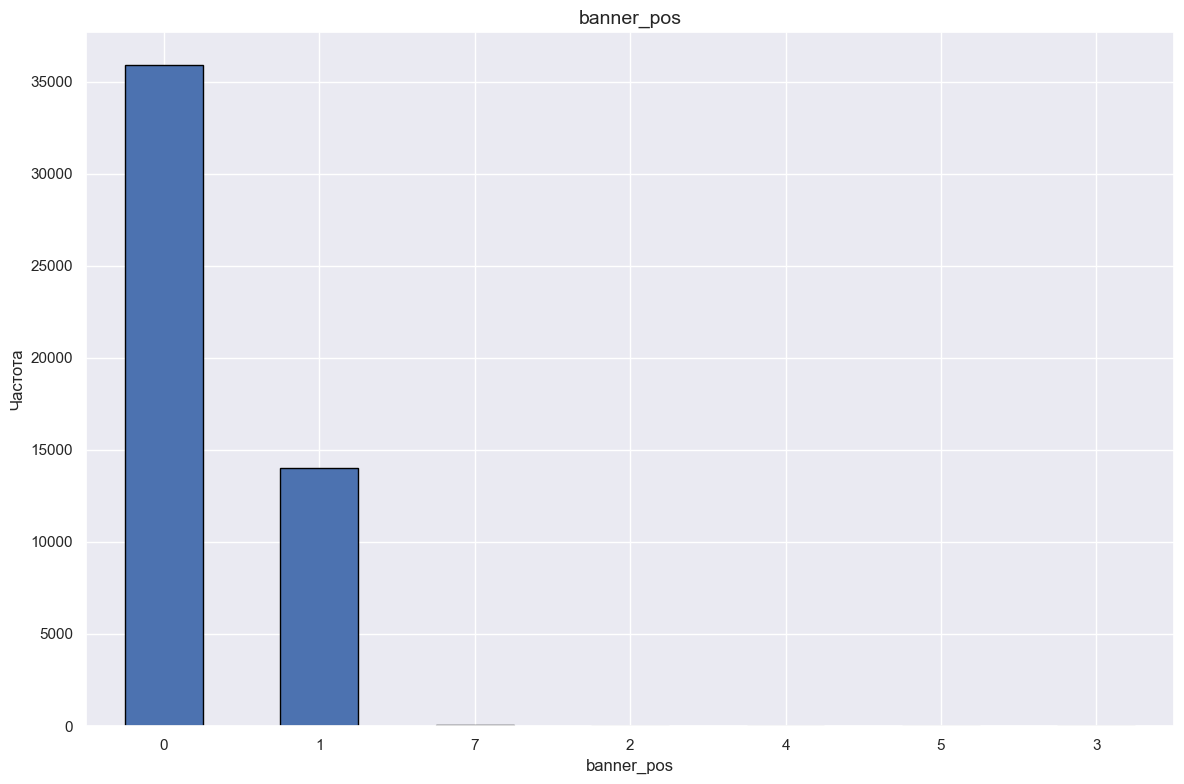

Описательные статистики для столбца  device_type :
count    50000.000000
mean         1.018120
std          0.538477
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: device_type, dtype: float64


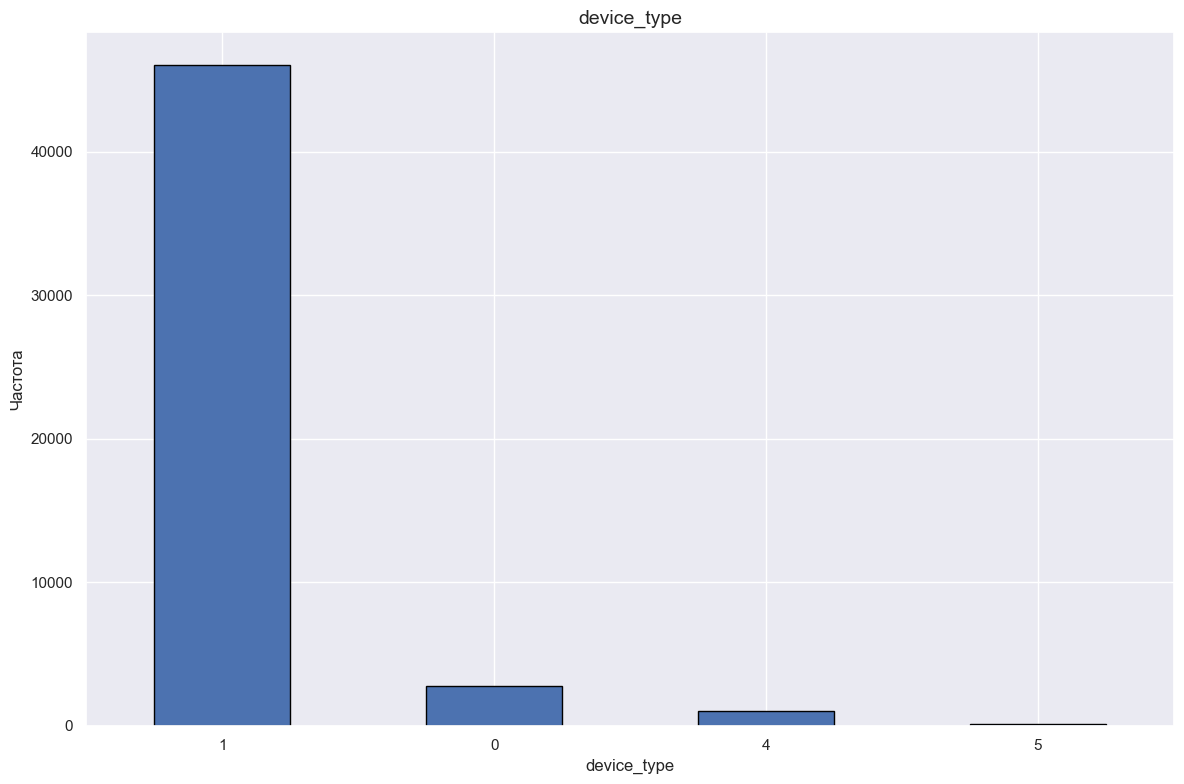

Описательные статистики для столбца  device_conn_type :
count    50000.000000
mean         0.337160
std          0.860057
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: device_conn_type, dtype: float64


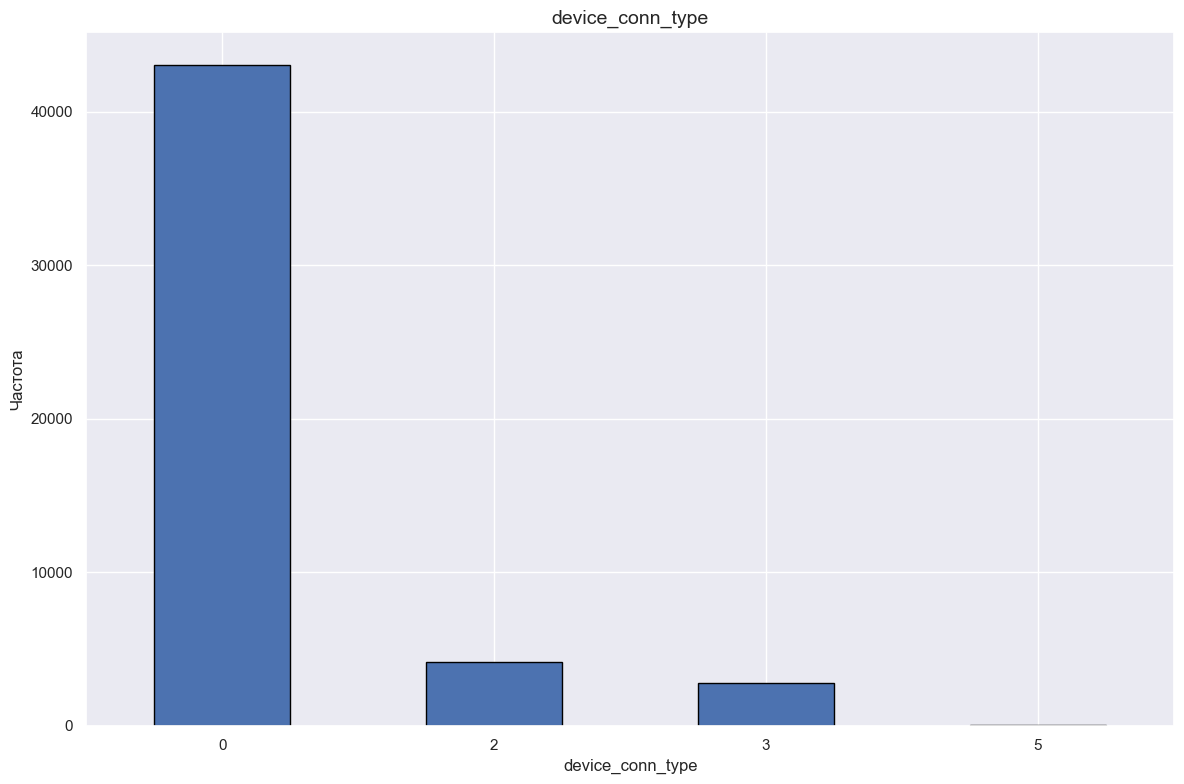

In [17]:
def feature_category (tmp0, value):
    '''
    Исследует категориальные (числовые) признаки по столбцам:
      Считает описательные статистики
      столбчатые диаграммы по столвцам/столбцу
    
    value - столбцы/столбец
    
    '''
    BOLD = '\033[1m' 
    RESET = '\033[0m'
    
    for col in value:
        print(f'Описательные статистики для столбца {BOLD} {col} {RESET}:')  # Заголовок отдельно
        print(tmp0[col].describe())
        sns.set_theme(style="darkgrid")
        tmp0[col].value_counts().plot(
            kind='bar',
            #color='mediumvioletred',
            edgecolor='black',
            rot=0 # Подписи по оси X не поворачиваются
        )

        # Добавляем подписи и заголовок
        plt.title(col, fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Частота', fontsize=12)

        # Улучшаем макет, чтобы подписи не обрезались
        plt.tight_layout()

        # Показываем график
        plt.show()

feature_category (df, ['banner_pos', 'device_type', 'device_conn_type'])

Распределения не равномерные, в пользу одной какой-либо категории. Либо совсем удалить эти признаки, как не особенно подходящие для анализа рекламных объявлений по смыслу: тип устройства пользователя: например, смартфон, планшет, ПК (device_type), тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G (device_conn_type). Либо при обработке использовать стандартизацию StandardScaler, которая меньше реагирует на выбросы.

### 2.6 Анализ выбросов и распределений
Проверьте, есть ли явные выбросы в числовых признаках.
Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

Исследуем распределение признаков по столбцам. Считаем описательные статистики. Строим гистограммы распределения, ящики с усами для непрерывных числовых признаков

Описательные статистики для столбца  hour :
count    5.000000e+04
mean     1.410256e+07
std      2.967892e+02
min      1.410210e+07
25%      1.410230e+07
50%      1.410260e+07
75%      1.410281e+07
max      1.410302e+07
Name: hour, dtype: float64


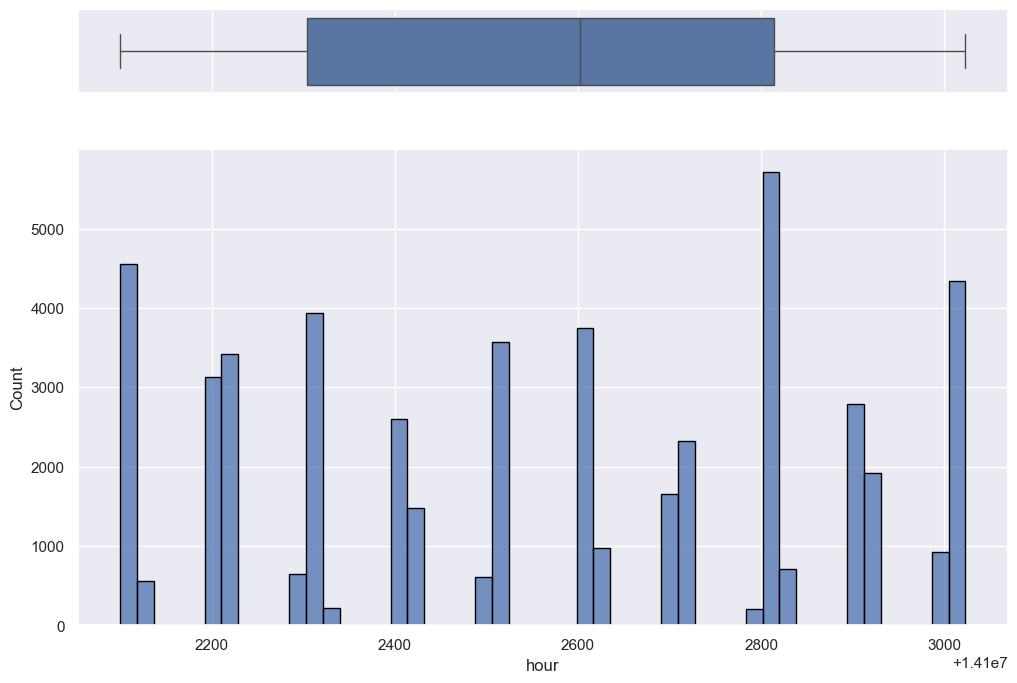

Описательные статистики для столбца  c1 :
count    50000.000000
mean      1004.970060
std          1.110202
min       1001.000000
25%       1005.000000
50%       1005.000000
75%       1005.000000
max       1012.000000
Name: c1, dtype: float64


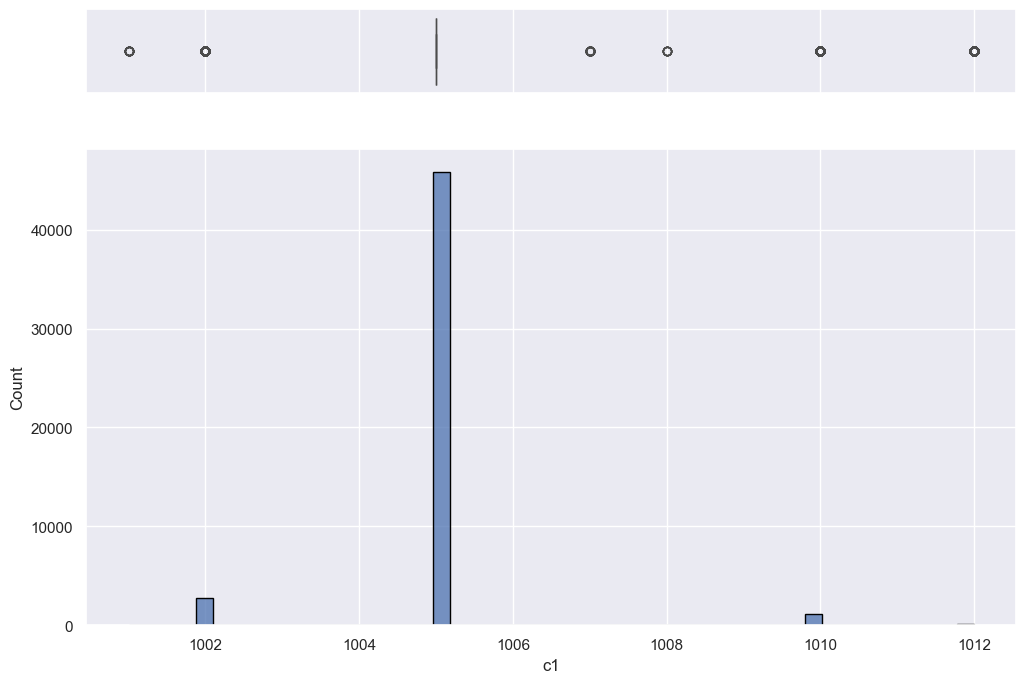

Описательные статистики для столбца  c14 :
count    50000.000000
mean     18826.648680
std       4983.064178
min        375.000000
25%      16920.000000
50%      20346.000000
75%      21916.000000
max      24043.000000
Name: c14, dtype: float64


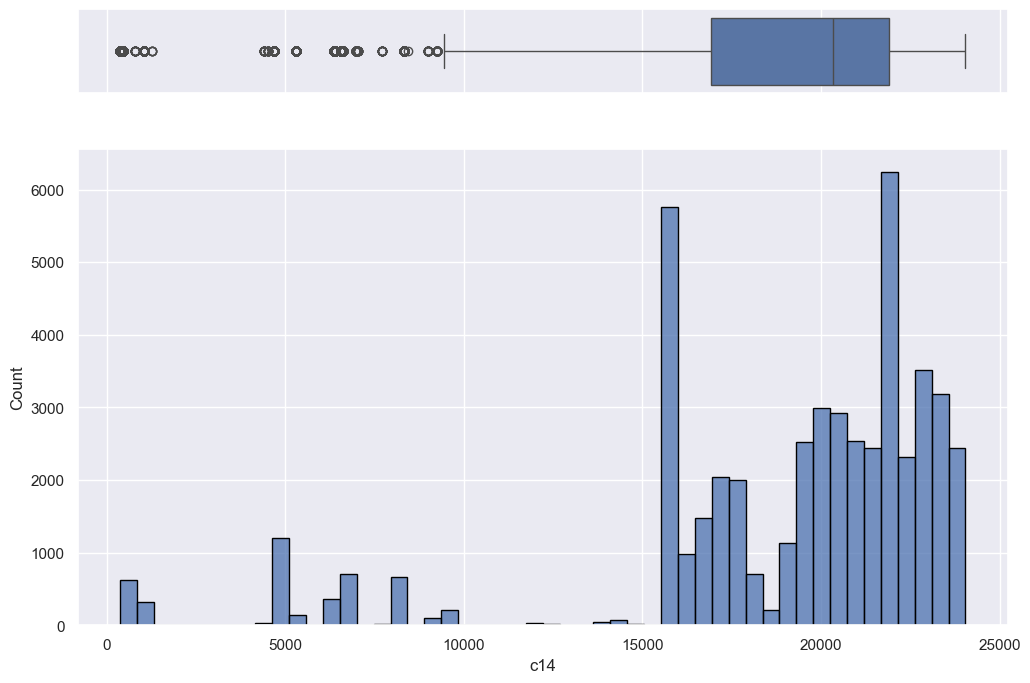

Описательные статистики для столбца  c15 :
count    50000.00000
mean       318.86640
std         20.56153
min        120.00000
25%        320.00000
50%        320.00000
75%        320.00000
max       1024.00000
Name: c15, dtype: float64


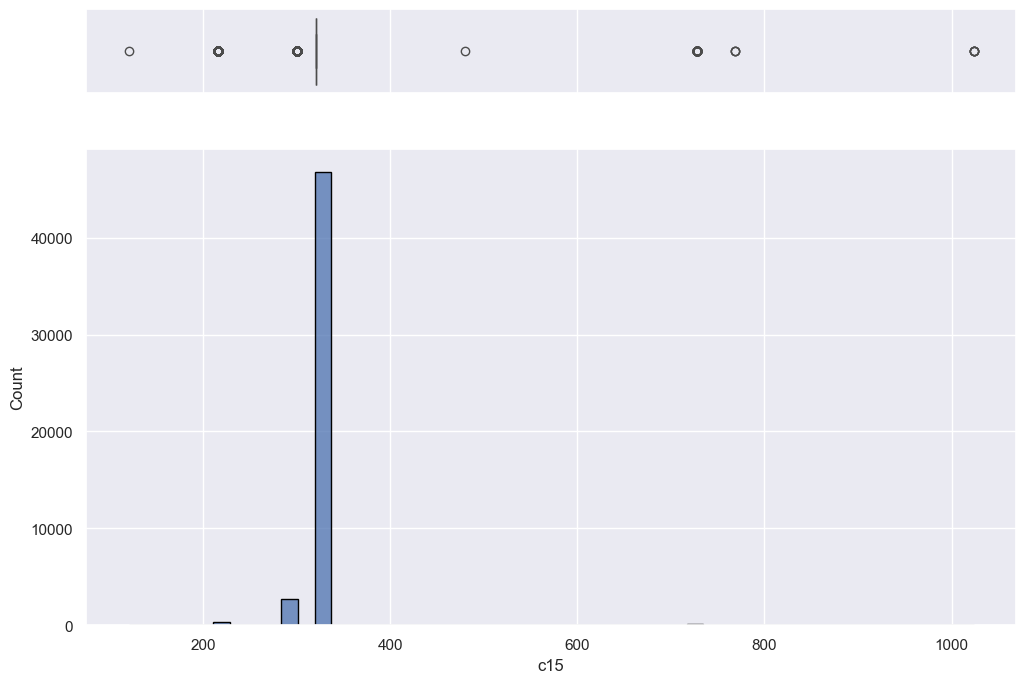

Описательные статистики для столбца  c16 :
count    50000.000000
mean        59.692480
std         46.720842
min         20.000000
25%         50.000000
50%         50.000000
75%         50.000000
max       1024.000000
Name: c16, dtype: float64


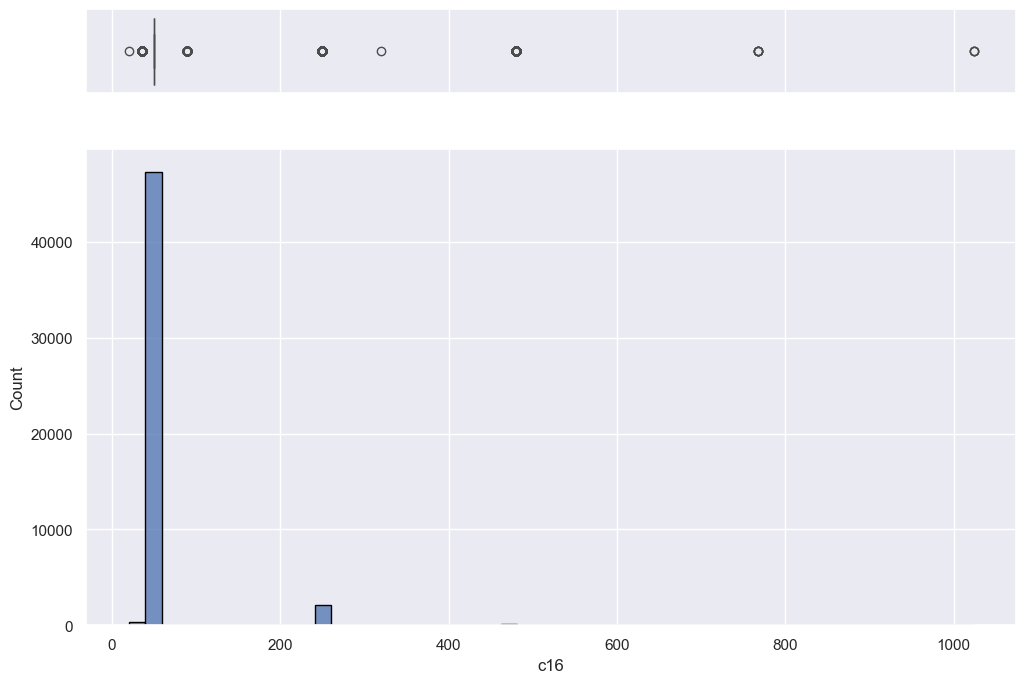

Описательные статистики для столбца  c17 :
count    50000.000000
mean      2109.781020
std        612.963141
min        112.000000
25%       1823.000000
50%       2323.000000
75%       2526.000000
max       2757.000000
Name: c17, dtype: float64


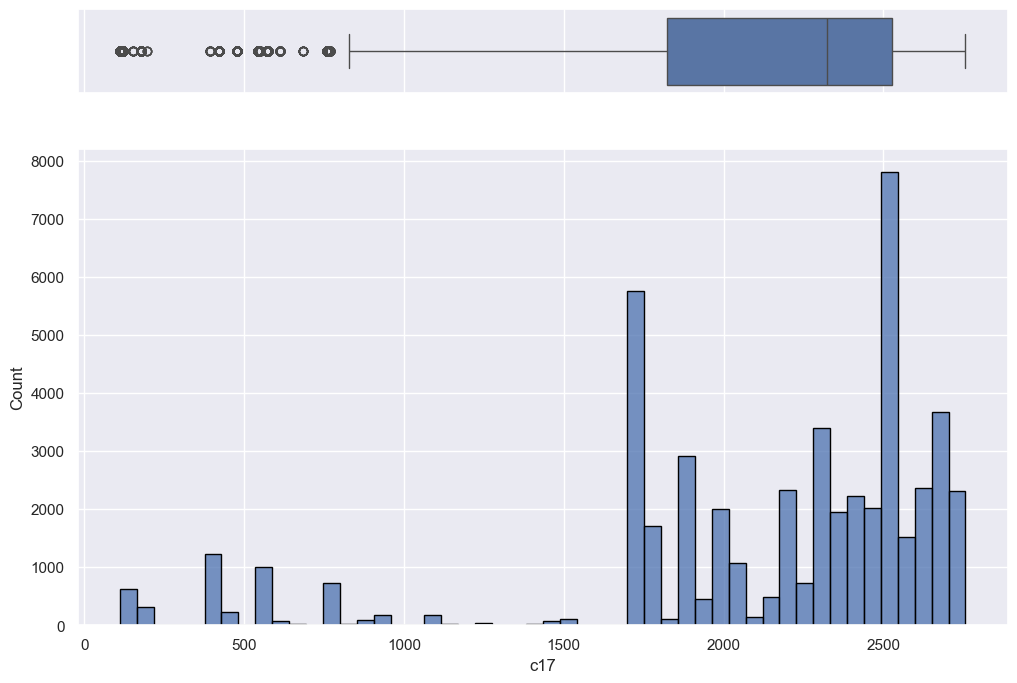

Описательные статистики для столбца  c18 :
count    50000.000000
mean         1.428100
std          1.327413
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: c18, dtype: float64


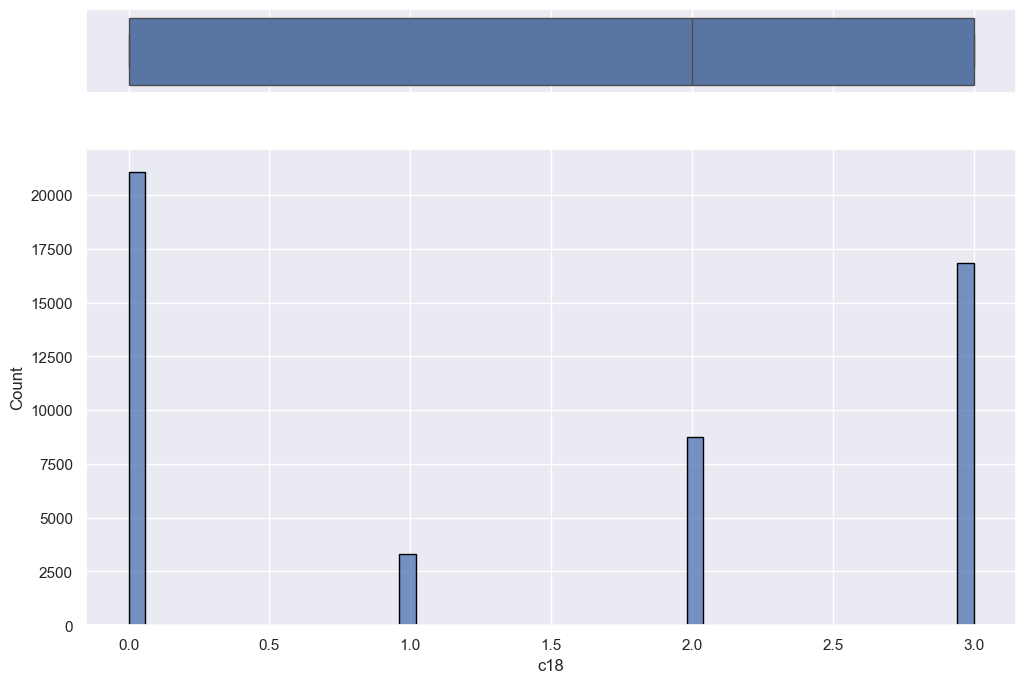

Описательные статистики для столбца  c19 :
count    50000.000000
mean       227.703800
std        351.592108
min         33.000000
25%         35.000000
50%         39.000000
75%        171.000000
max       1839.000000
Name: c19, dtype: float64


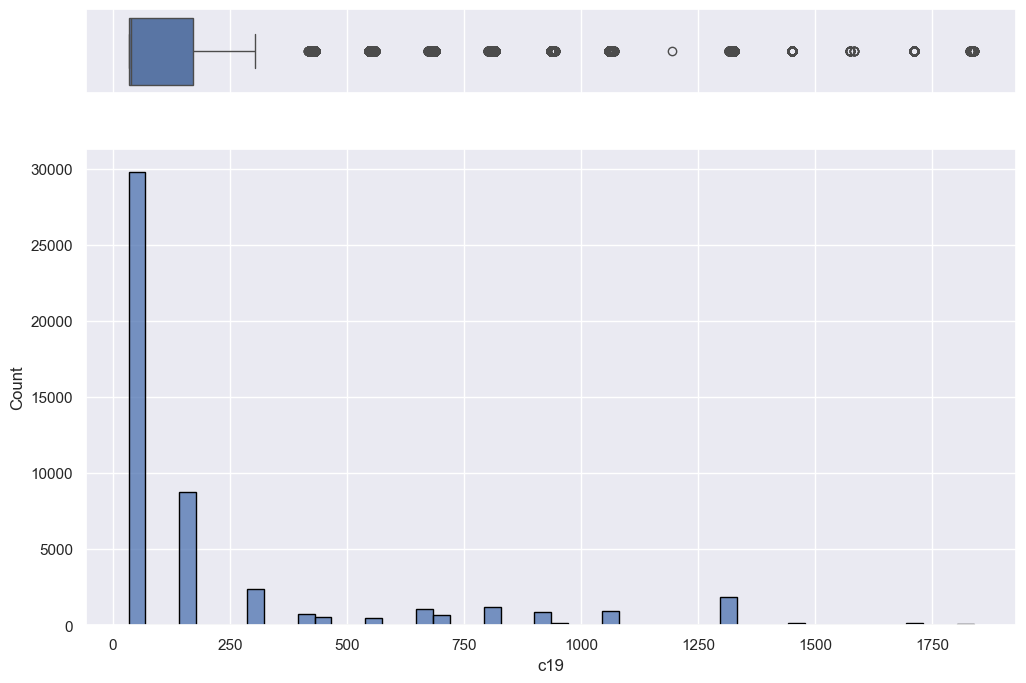

Описательные статистики для столбца  c20 :
count     50000.000000
mean      53173.383240
std       49960.181871
min          -1.000000
25%          -1.000000
50%      100049.000000
75%      100094.000000
max      100248.000000
Name: c20, dtype: float64


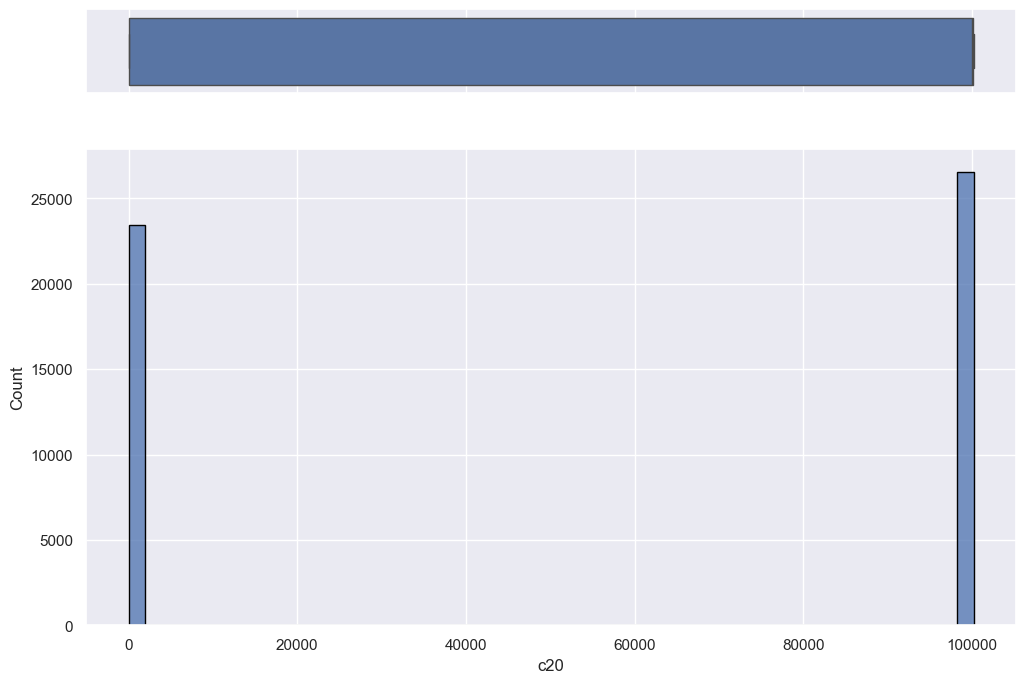

Описательные статистики для столбца  c21 :
count    50000.000000
mean        83.685180
std         70.539513
min         13.000000
25%         23.000000
50%         61.000000
75%        108.000000
max        255.000000
Name: c21, dtype: float64


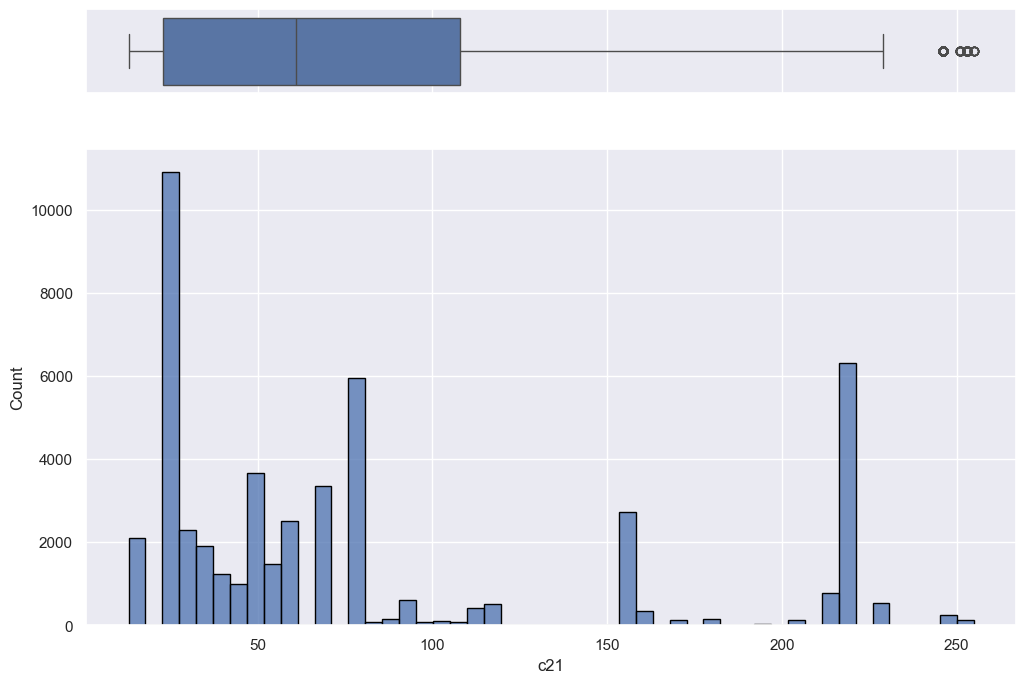

Описательные статистики для столбца  ml_feature_4 :
count    50000.000000
mean         0.498040
std          0.500001
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: ml_feature_4, dtype: float64


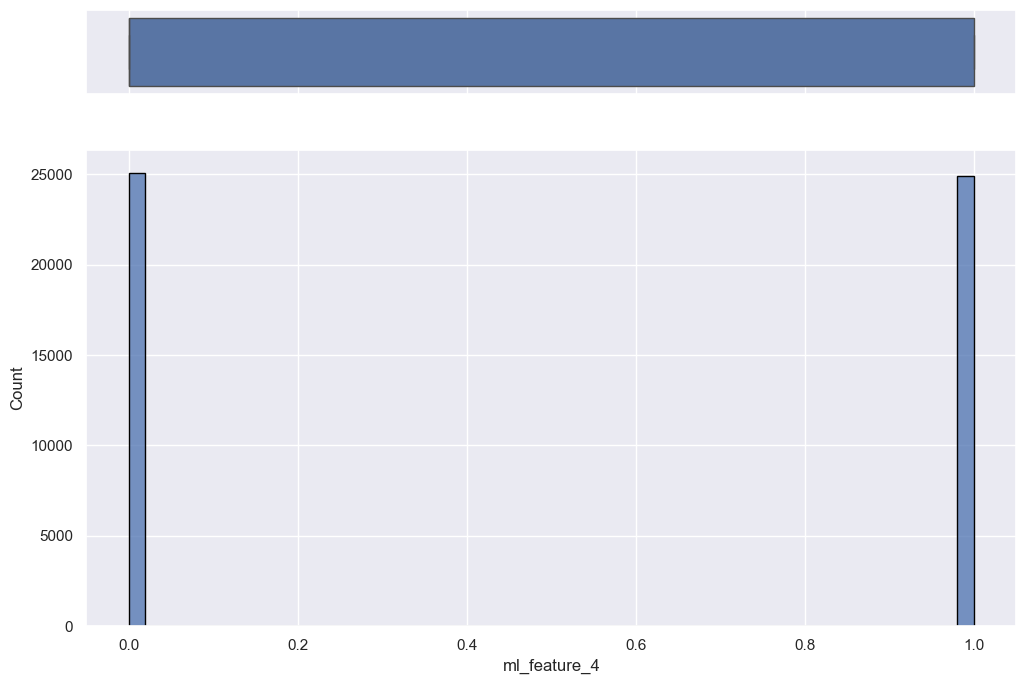

Описательные статистики для столбца  ml_feature_1 :
count    50000.000000
mean        -0.002445
std          1.000277
min         -4.631262
25%         -0.677784
50%         -0.003776
75%          0.673534
max          3.793828
Name: ml_feature_1, dtype: float64


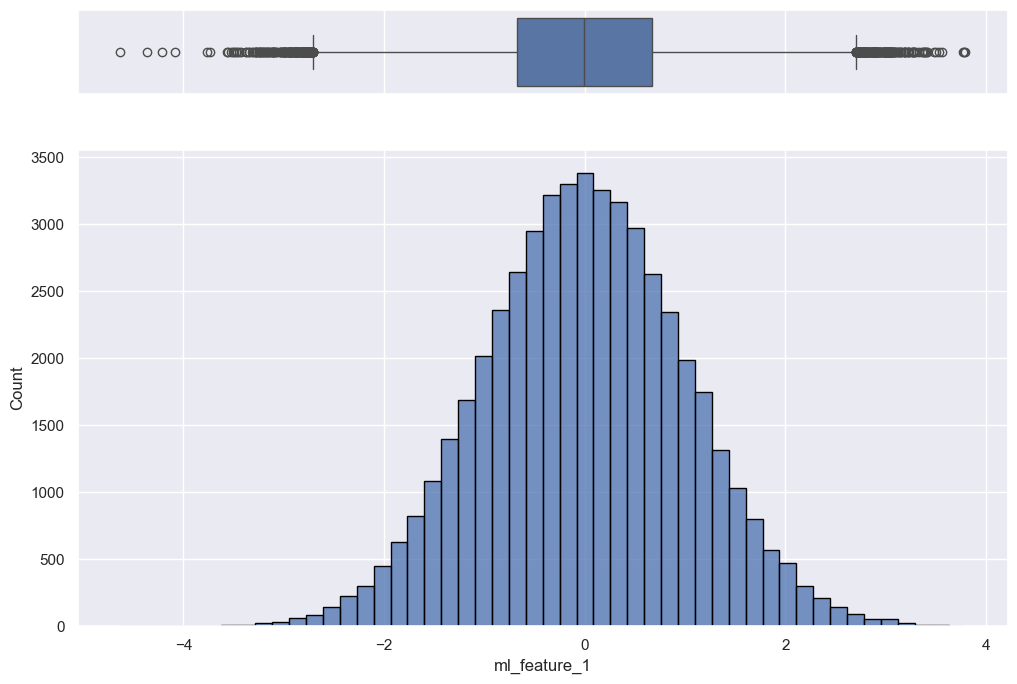

Описательные статистики для столбца  ml_feature_3 :
count    50000.000000
mean        -0.036381
std          5.792313
min         -9.999742
25%         -5.059555
50%         -0.056155
75%          4.985939
max          9.999975
Name: ml_feature_3, dtype: float64


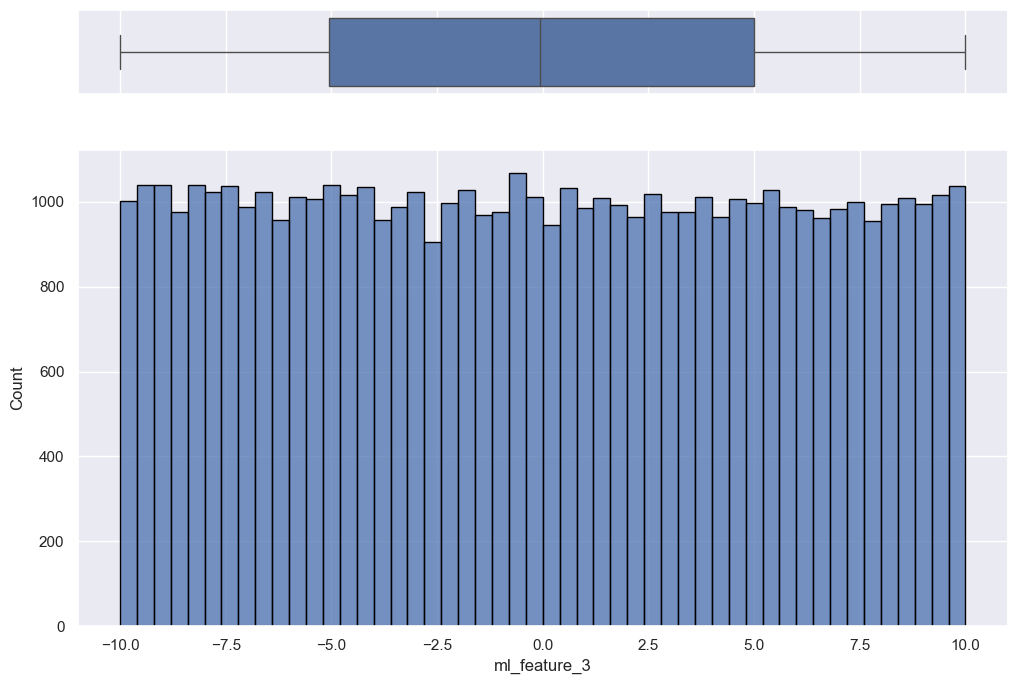

Описательные статистики для столбца  ml_feature_5 :
count    50000.000000
mean         0.034729
std          1.002113
min         -4.631853
25%         -0.639829
50%          0.028112
75%          0.707594
max          4.230623
Name: ml_feature_5, dtype: float64


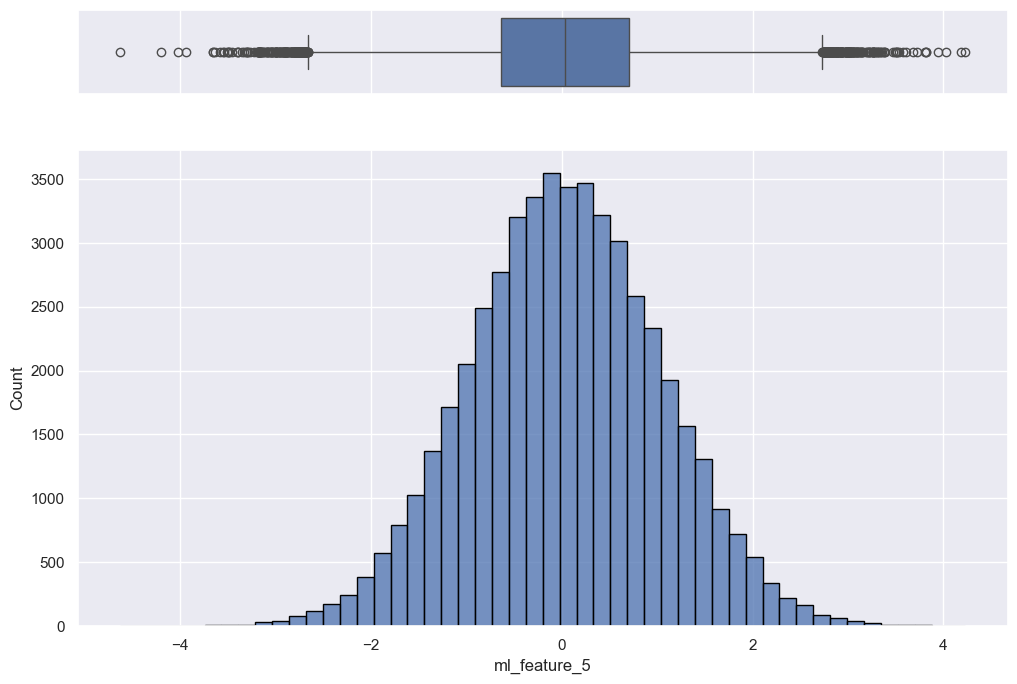

Описательные статистики для столбца  ml_feature_6 :
count    50000.000000
mean         0.022948
std          0.656691
min         -1.000000
25%         -0.579775
50%          0.037786
75%          0.637131
max          1.000000
Name: ml_feature_6, dtype: float64


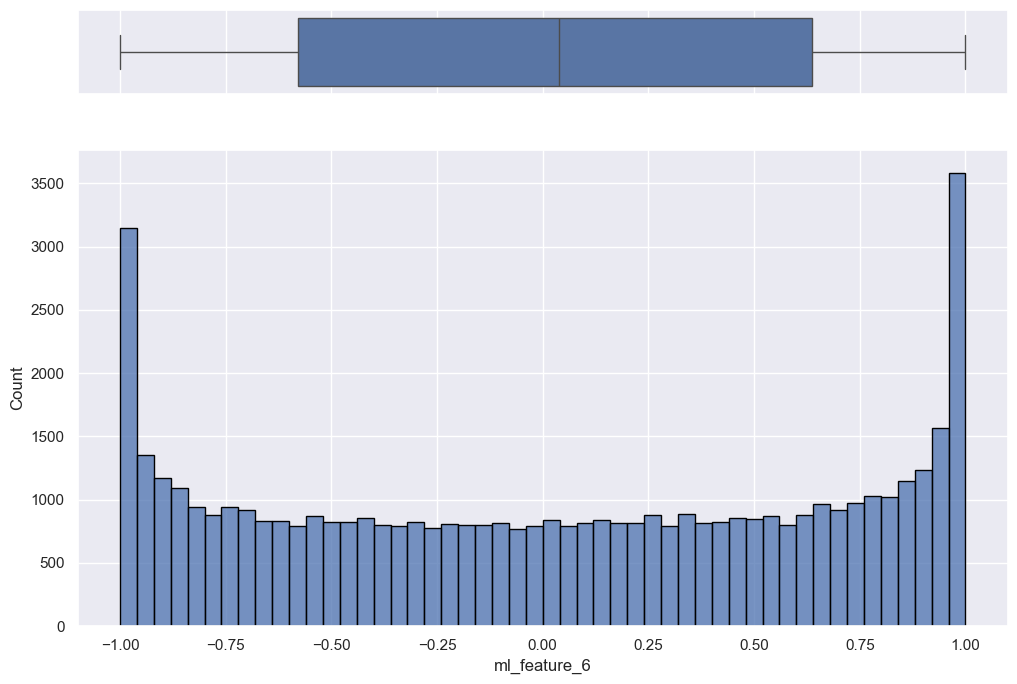

Описательные статистики для столбца  ml_feature_8 :
count    50000.000000
mean         0.025465
std          0.578024
min         -0.999965
25%         -0.470627
50%          0.027348
75%          0.521117
max          1.119858
Name: ml_feature_8, dtype: float64


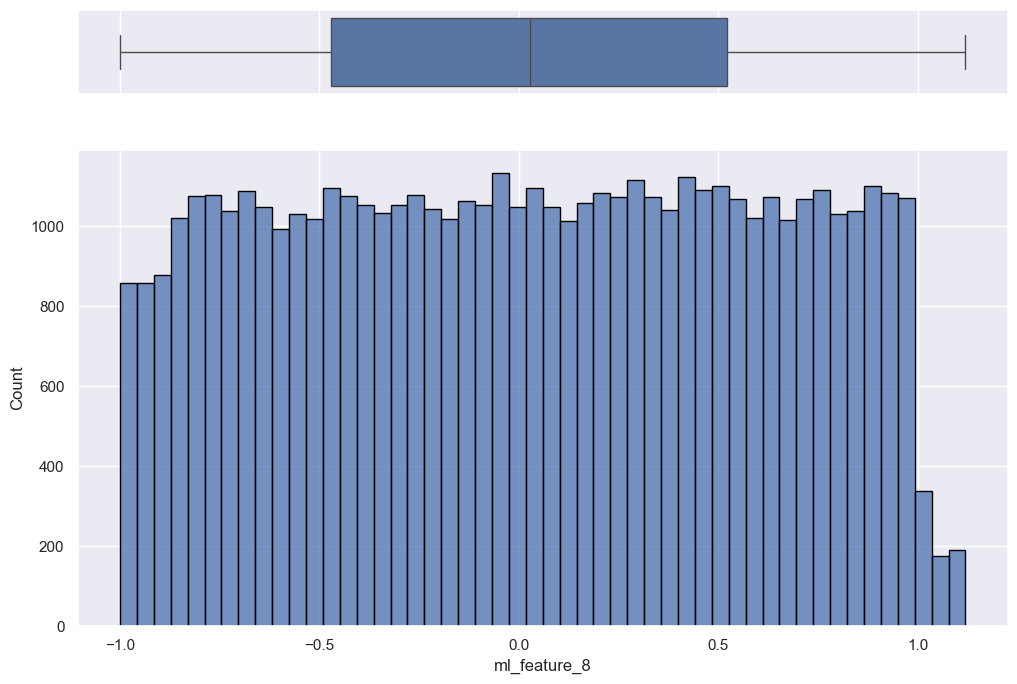

Описательные статистики для столбца  ml_feature_9 :
count    50000.000000
mean         0.035361
std          0.505033
min         -2.147526
25%         -0.304077
50%          0.035985
75%          0.374152
max          2.120786
Name: ml_feature_9, dtype: float64


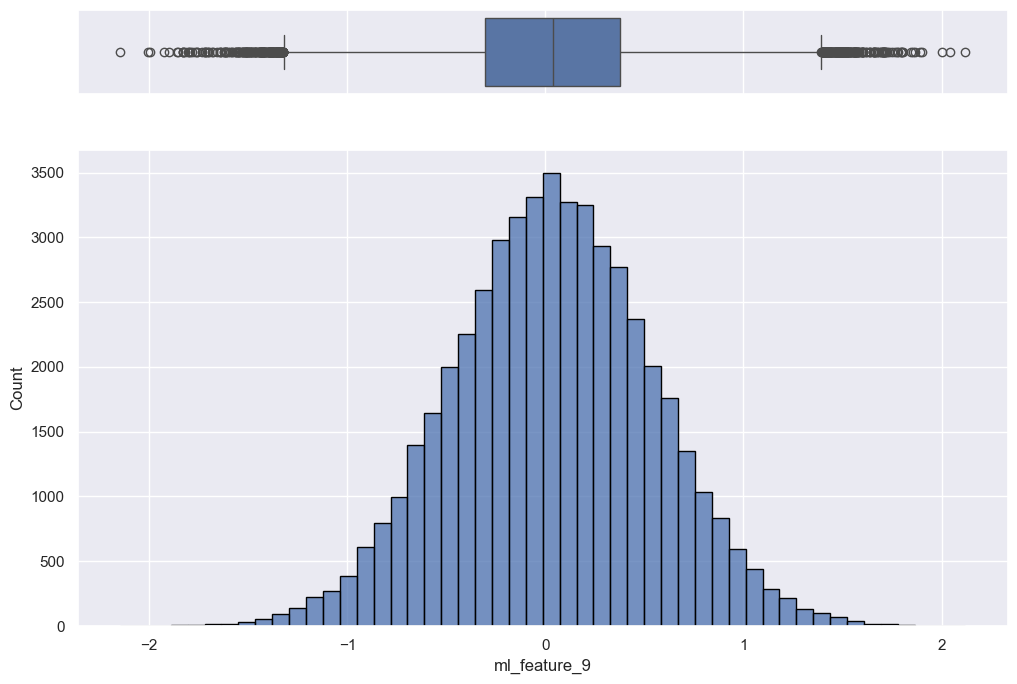

Описательные статистики для столбца  ml_feature_10 :
count    50000.000000
mean         0.020226
std          0.303308
min         -1.287965
25%         -0.182386
50%          0.018930
75%          0.224080
max          1.202300
Name: ml_feature_10, dtype: float64


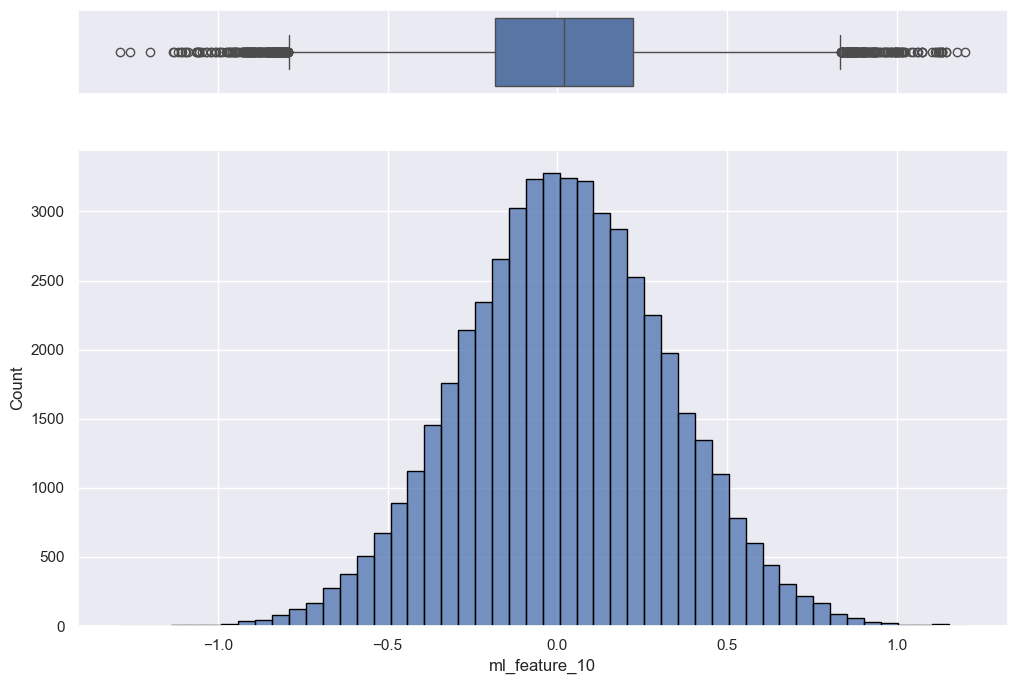

In [18]:
def feature_distribution (value):
    '''
    Исследует распределение признаков по столбцам:
      Считает описательные статистики
      Строит гистограммы распределения, ящики с усами по столвцам/столбцу
    
    value - столбцы/столбец
    
    '''
    BOLD = '\033[1m' 
    RESET = '\033[0m'
    
    for col in value:
        print(f'Описательные статистики для столбца {BOLD} {col} {RESET}:')  # Заголовок отдельно
        print(df[col].describe())
        sns.set_theme(style="darkgrid")
        # creating a figure composed of two matplotlib.Axes objects (ax_box and ax_hist)
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

        # assigning a graph to each ax
        sns.boxplot(data=df, x=col, orient="h", ax=ax_box)  # Явно указываем data и x
        sns.histplot(data=df, x=col, ax=ax_hist, bins=50, edgecolor='black')

        # Remove x axis name for the boxplot
        ax_box.set(xlabel='')
        plt.show()
    
feature_distribution (['hour', 'c1',  'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 
'c21', 'ml_feature_4', 'ml_feature_1', 'ml_feature_3', 'ml_feature_5', 
'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'])

В ходе анализа распределений выявили:
 1. Признаки c1, c15, c16, c20, ml_feature_4` - дискретные числоыве признаки. По ним построим столбиковые диаграммы. Отнесём к категоиарьным данным.
 2. Признаки `hour, c14, c17, c19, c21` - непрерывные, много вершинные распределения (левый хвост), содержат выбросы
 3. Признаки `ml_feature_1, ml_feature_5,  ml_feature_10` - с нормальным распределением
 4. Признаки `ml_feature_3, ml_feature_6, ml_feature_9` - не содержат выбросов.

Описательные статистики для столбца  c1 :
count    50000.000000
mean      1004.970060
std          1.110202
min       1001.000000
25%       1005.000000
50%       1005.000000
75%       1005.000000
max       1012.000000
Name: c1, dtype: float64


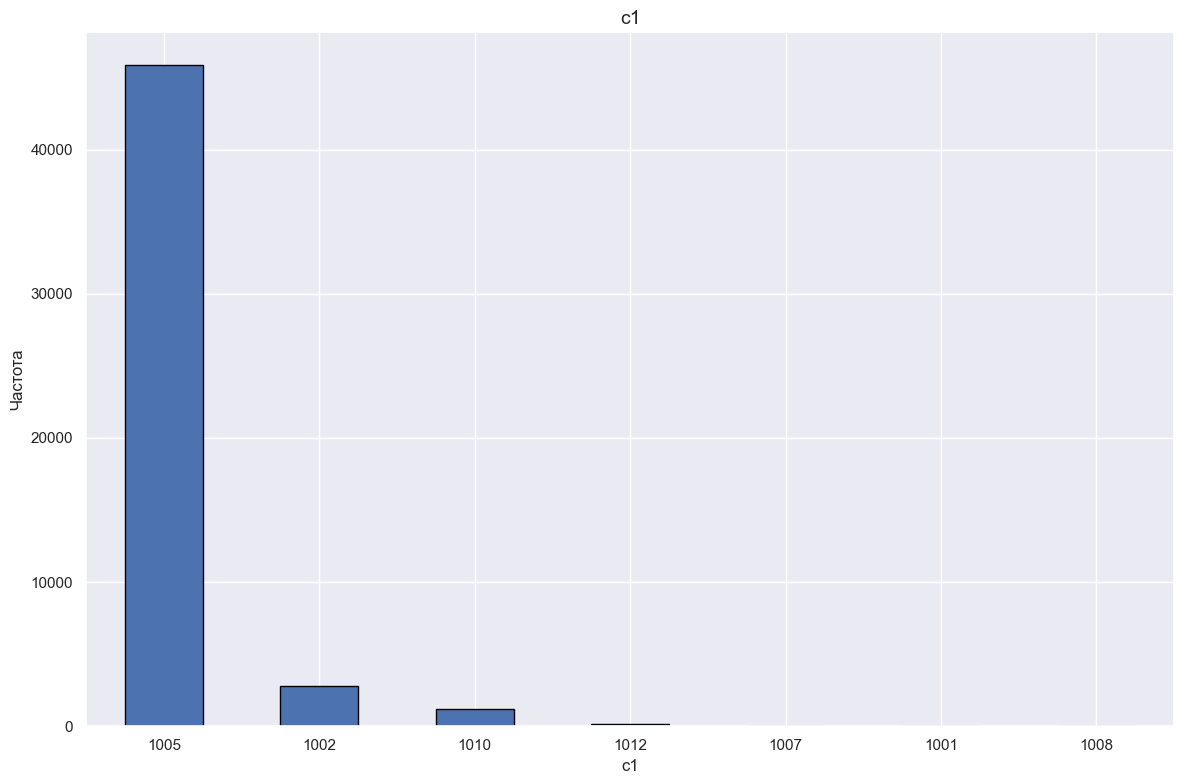

Описательные статистики для столбца  c15 :
count    50000.00000
mean       318.86640
std         20.56153
min        120.00000
25%        320.00000
50%        320.00000
75%        320.00000
max       1024.00000
Name: c15, dtype: float64


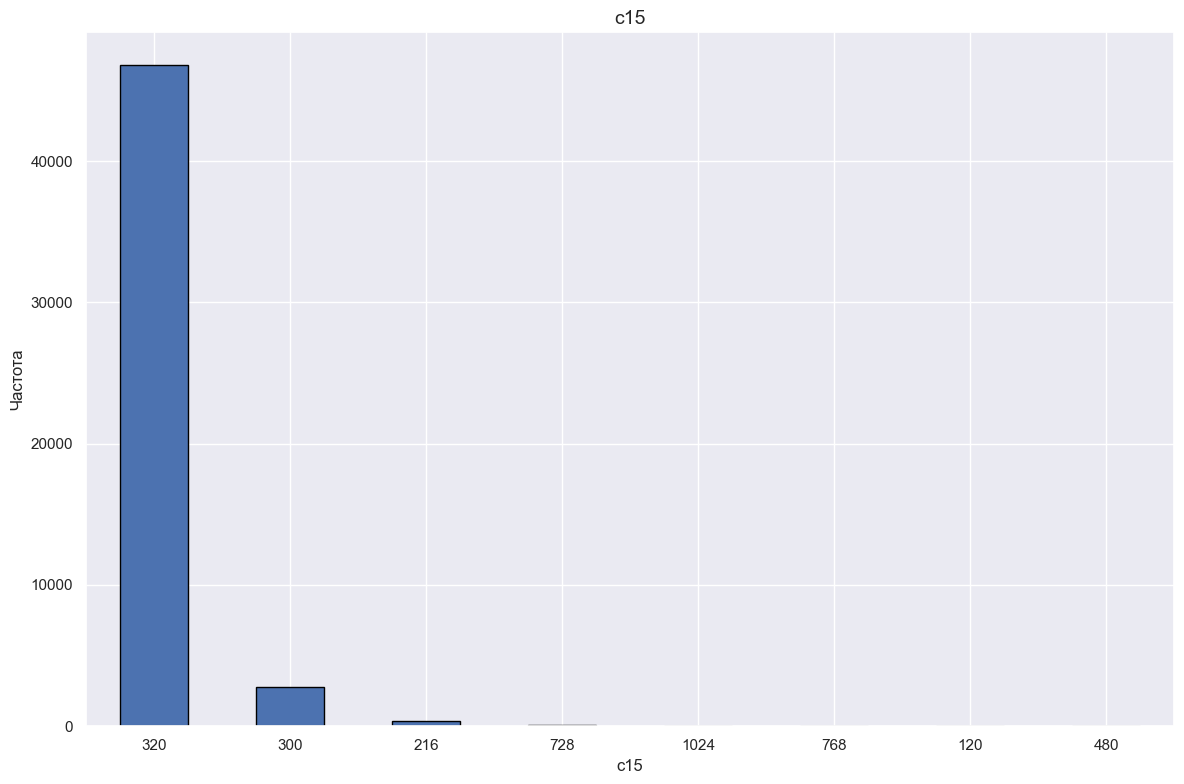

Описательные статистики для столбца  c16 :
count    50000.000000
mean        59.692480
std         46.720842
min         20.000000
25%         50.000000
50%         50.000000
75%         50.000000
max       1024.000000
Name: c16, dtype: float64


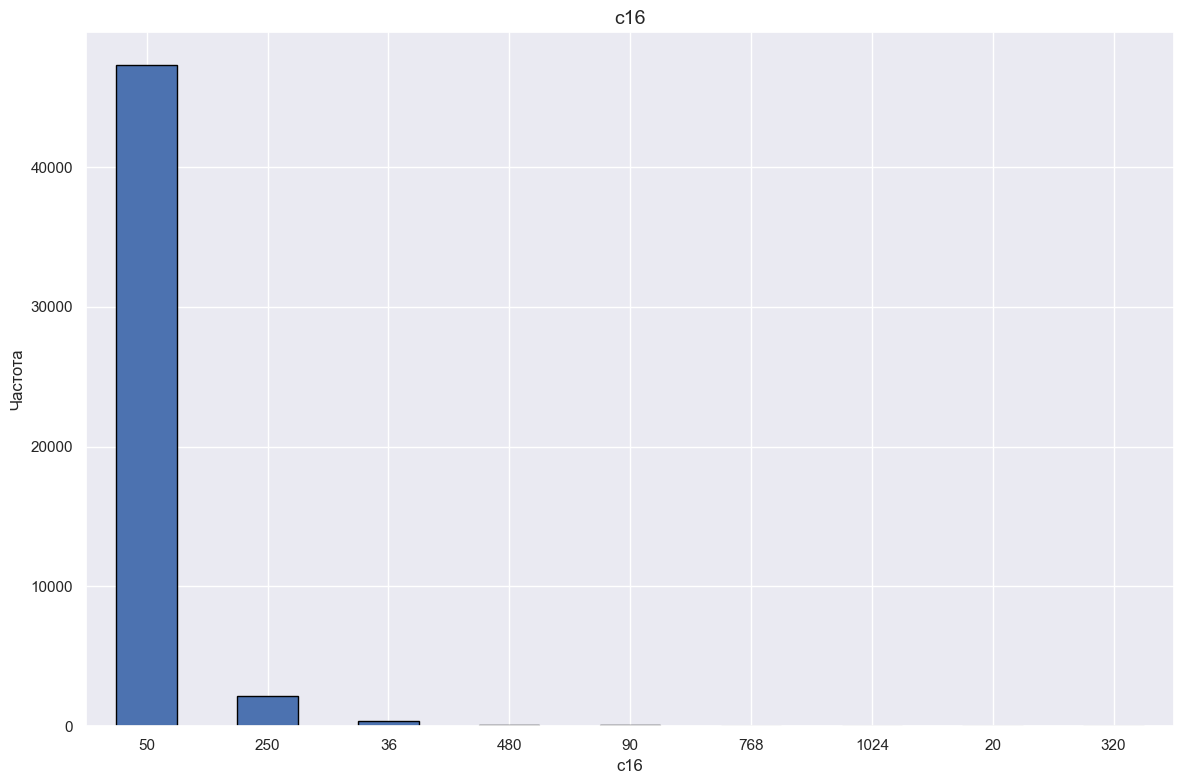

Описательные статистики для столбца  c20 :
count     50000.000000
mean      53173.383240
std       49960.181871
min          -1.000000
25%          -1.000000
50%      100049.000000
75%      100094.000000
max      100248.000000
Name: c20, dtype: float64


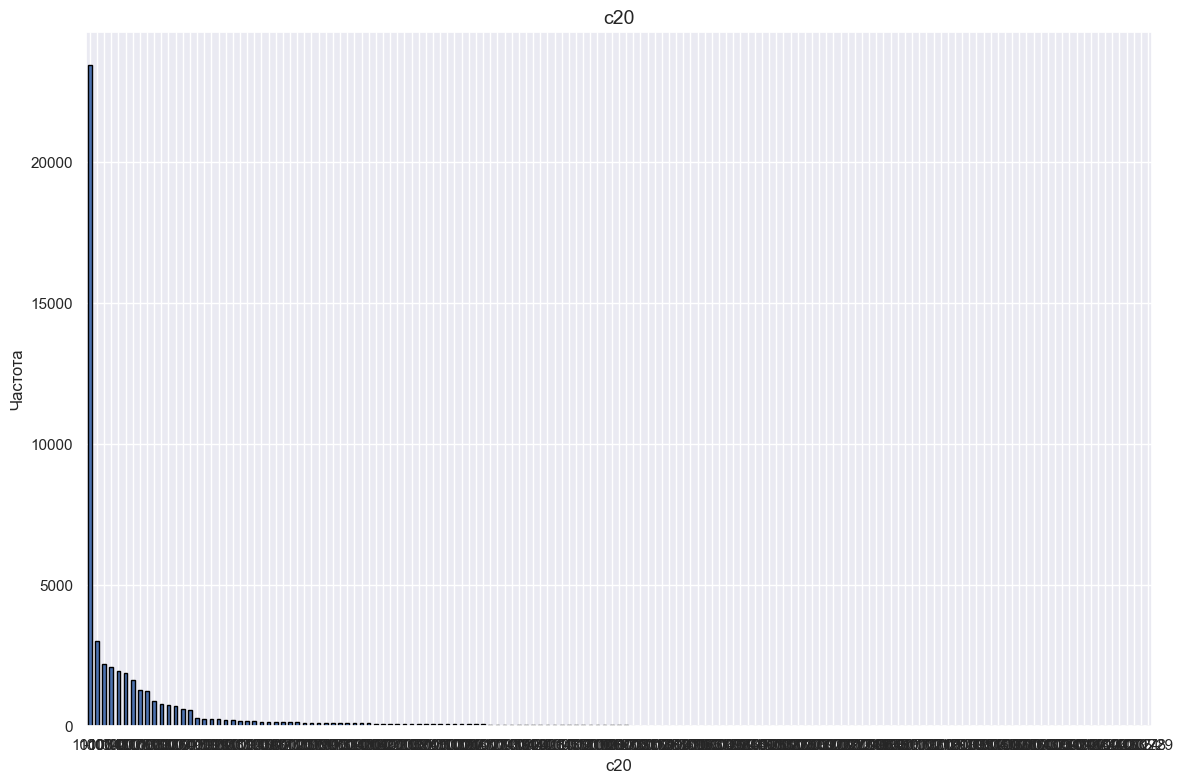

Описательные статистики для столбца  ml_feature_4 :
count    50000.000000
mean         0.498040
std          0.500001
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: ml_feature_4, dtype: float64


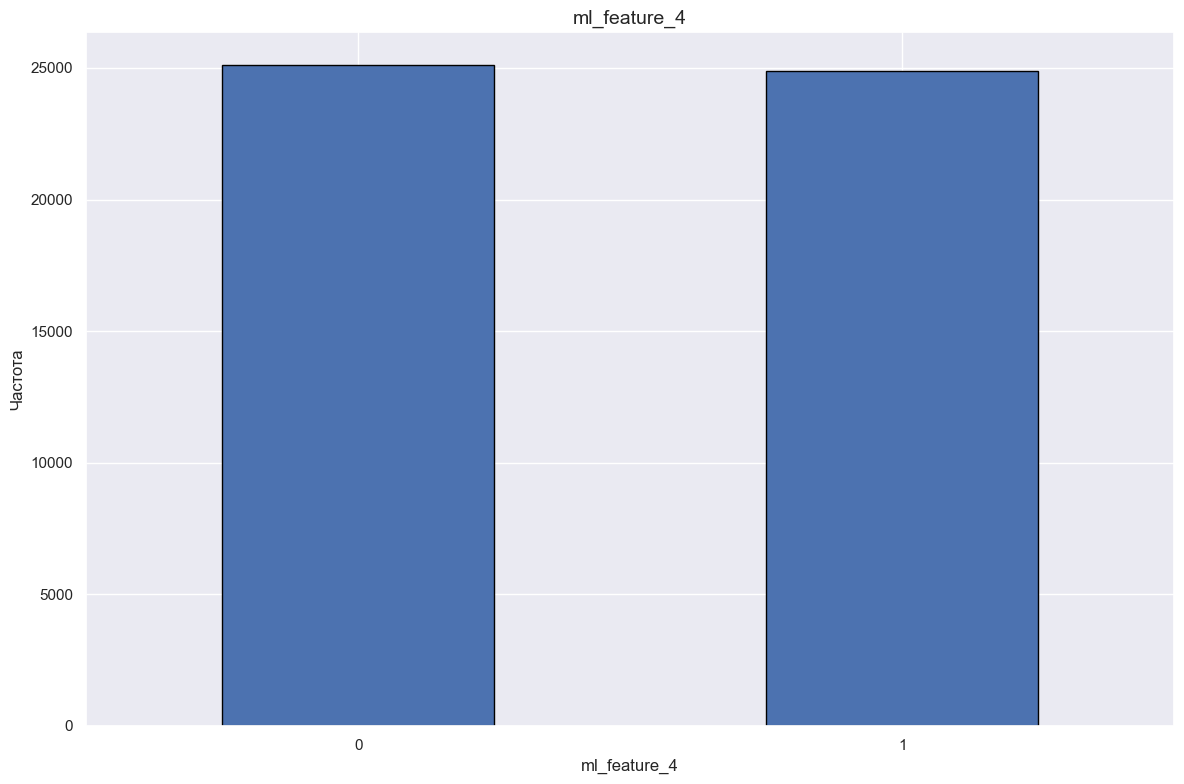

In [19]:
feature_category (df, ['c1', 'c15', 'c16', 'c20', 'ml_feature_4'])

Очень сильный дисбаланс в данных: `'c1', 'c15', 'c16', 'c20', 'banner_pos', 'device_type', 'device_conn_type'` можно применить вычисления, например, извлечь корень квадратный

Для скошенных левосторонних распределений: `c14, c17, c19, c21` можно применить логарифмирование.

### 3.0.7  2.7 Корреляции
Определите, какие признаки коррелируют с целевой переменной.
Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

Создаем новые признаки на основе существующих с целью улучшеня модели в п.8-9


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 22659 to 6020
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   click             50000 non-null  int8   
 1   hour              50000 non-null  int32  
 2   c1                50000 non-null  int16  
 3   banner_pos        50000 non-null  int8   
 4   site_domain       50000 non-null  object 
 5   site_category     50000 non-null  object 
 6   app_domain        50000 non-null  object 
 7   app_category      50000 non-null  object 
 8   device_type       50000 non-null  int8   
 9   device_conn_type  50000 non-null  int8   
 10  c14               50000 non-null  int16  
 11  c15               50000 non-null  int16  
 12  c16               50000 non-null  int16  
 13  c17               50000 non-null  int16  
 14  c18               50000 non-null  int8   
 15  c19               50000 non-null  int16  
 16  c20               50000 non-null  int32  


In [21]:
df.columns

Index(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'site_category',
       'app_domain', 'app_category', 'device_type', 'device_conn_type', 'c14',
       'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1',
       'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9',
       'ml_feature_10'],
      dtype='object')

Строим тепловую карту по корреляционной матрице для заданной переменной 

C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(


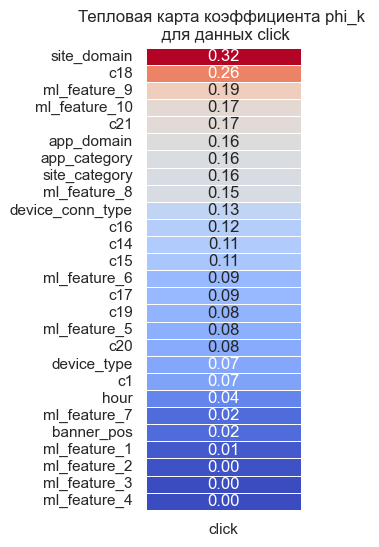

In [22]:
def correl_matrix_column(value, col):
    '''
    Строит тепловую карту по корреляционной матрицы для заданной переменной 
    value - столбцы/столбец
    col- столбец, для которого выводят коэффициенты корреляции
    interval_cols - список непрерывных признаков
    При использовании phik крайне важно настроить параметр interval_cols, передав ему список с 
    названиями непрерывных признаков: если этого не сделать, библиотека своими силами будет 
    пытаться разнести признаки по типам, и она часто делает в этом ошибки - от этого в свою очередь 
    мы получаем некорректную оценку корреляций, так как от типа признака зависит метод оценки корреляции.
    '''
    continuous_features = ['hour', 'c1', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 
                           'ml_feature_1', 
                           'banner_pos', 'device_type', 'device_conn_type',
                           'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 
                           'ml_feature_8', 'ml_feature_9', 'ml_feature_10']
    
    correlation_matrix = df[value].phik_matrix(interval_cols=continuous_features)
    
    # Строим тепловую карту
    plt.figure(figsize=(2, 6))
    correlation_matrix.loc[correlation_matrix.index != col][[col]].sort_values(by=col, ascending=False)
    # Сохраняем матрицу корреляции признака col с другими признаками 
    data_heatmap = correlation_matrix.loc[correlation_matrix.index != col][[col]].sort_values(by=col, ascending=False)
    sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )
    # Добавляем заголовок и подпись по оси Х
    plt.title(f'Тепловая карта коэффициента phi_k \n для данных {col}')
    # Выводим график
    plt.show()
    


correl_matrix_column(['click','hour', 'device_type', 'c1', 'banner_pos', 'site_domain', 'site_category',
       'device_conn_type', 'c14', 'app_domain', 'app_category', 
       'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1',
       'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9',
       'ml_feature_10'], 'click')

In [23]:
df.columns

Index(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'site_category',
       'app_domain', 'app_category', 'device_type', 'device_conn_type', 'c14',
       'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1',
       'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9',
       'ml_feature_10'],
      dtype='object')

C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(


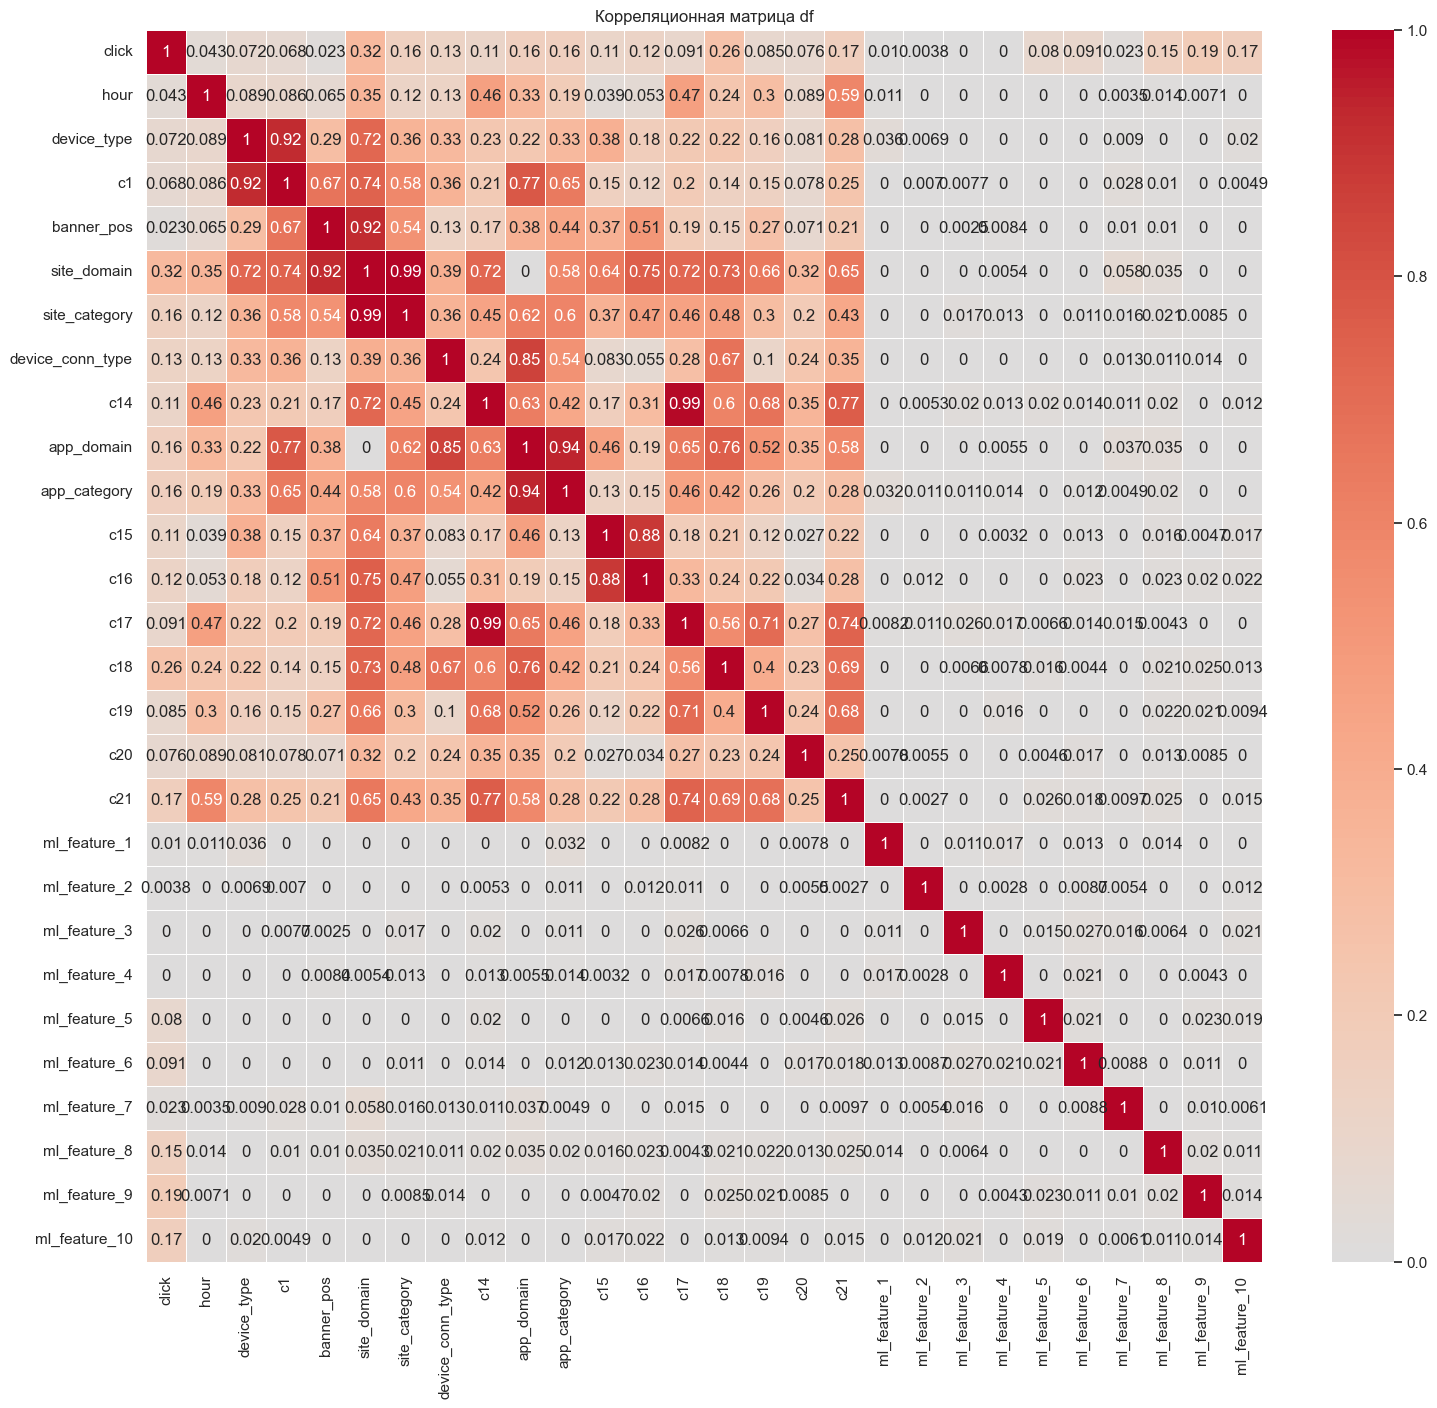

In [24]:
columns_to_analyze = [
                       'click','hour', 'device_type', 'c1', 'banner_pos', 'site_domain', 'site_category',
       'device_conn_type', 'c14', 'app_domain', 'app_category', 
       'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1',
       'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9',
       'ml_feature_10'
]

continuous_features = ['hour', 'c1', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 
                           'ml_feature_1', 
                           'banner_pos', 'device_type', 'device_conn_type',
                           'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 
                           'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

correlation_matrix = df[columns_to_analyze].phik_matrix(interval_cols=continuous_features)
#display(correlation_matrix)

# Построим тепловую карту
plt.figure(figsize=(18,16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица df')
plt.show()

Коллинеарность между:
- device_model и c1 (0.95), site_domain (1), app_domain (0.99), app_category (0.9)
- с17и с14 0,99
- app_category app_domain 0.94, device_conn_type app_domain 0.85
- site_domain banner_pos 0.92
- site_category site_domain 0.99
- c1 device_type 0.88, c1 banner_pos 0.84

Не выявлено взаимосвязей для признаков: ml_feature_1 - ml_feature_10


Чтобы избавиться от коллинеарности уберём 'site_category', 'c14', 'c16', 'app_domain'  чтобы убрать корреляции 0,
'app_domain'

In [25]:
df.columns

Index(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'site_category',
       'app_domain', 'app_category', 'device_type', 'device_conn_type', 'c14',
       'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1',
       'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9',
       'ml_feature_10'],
      dtype='object')

C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(


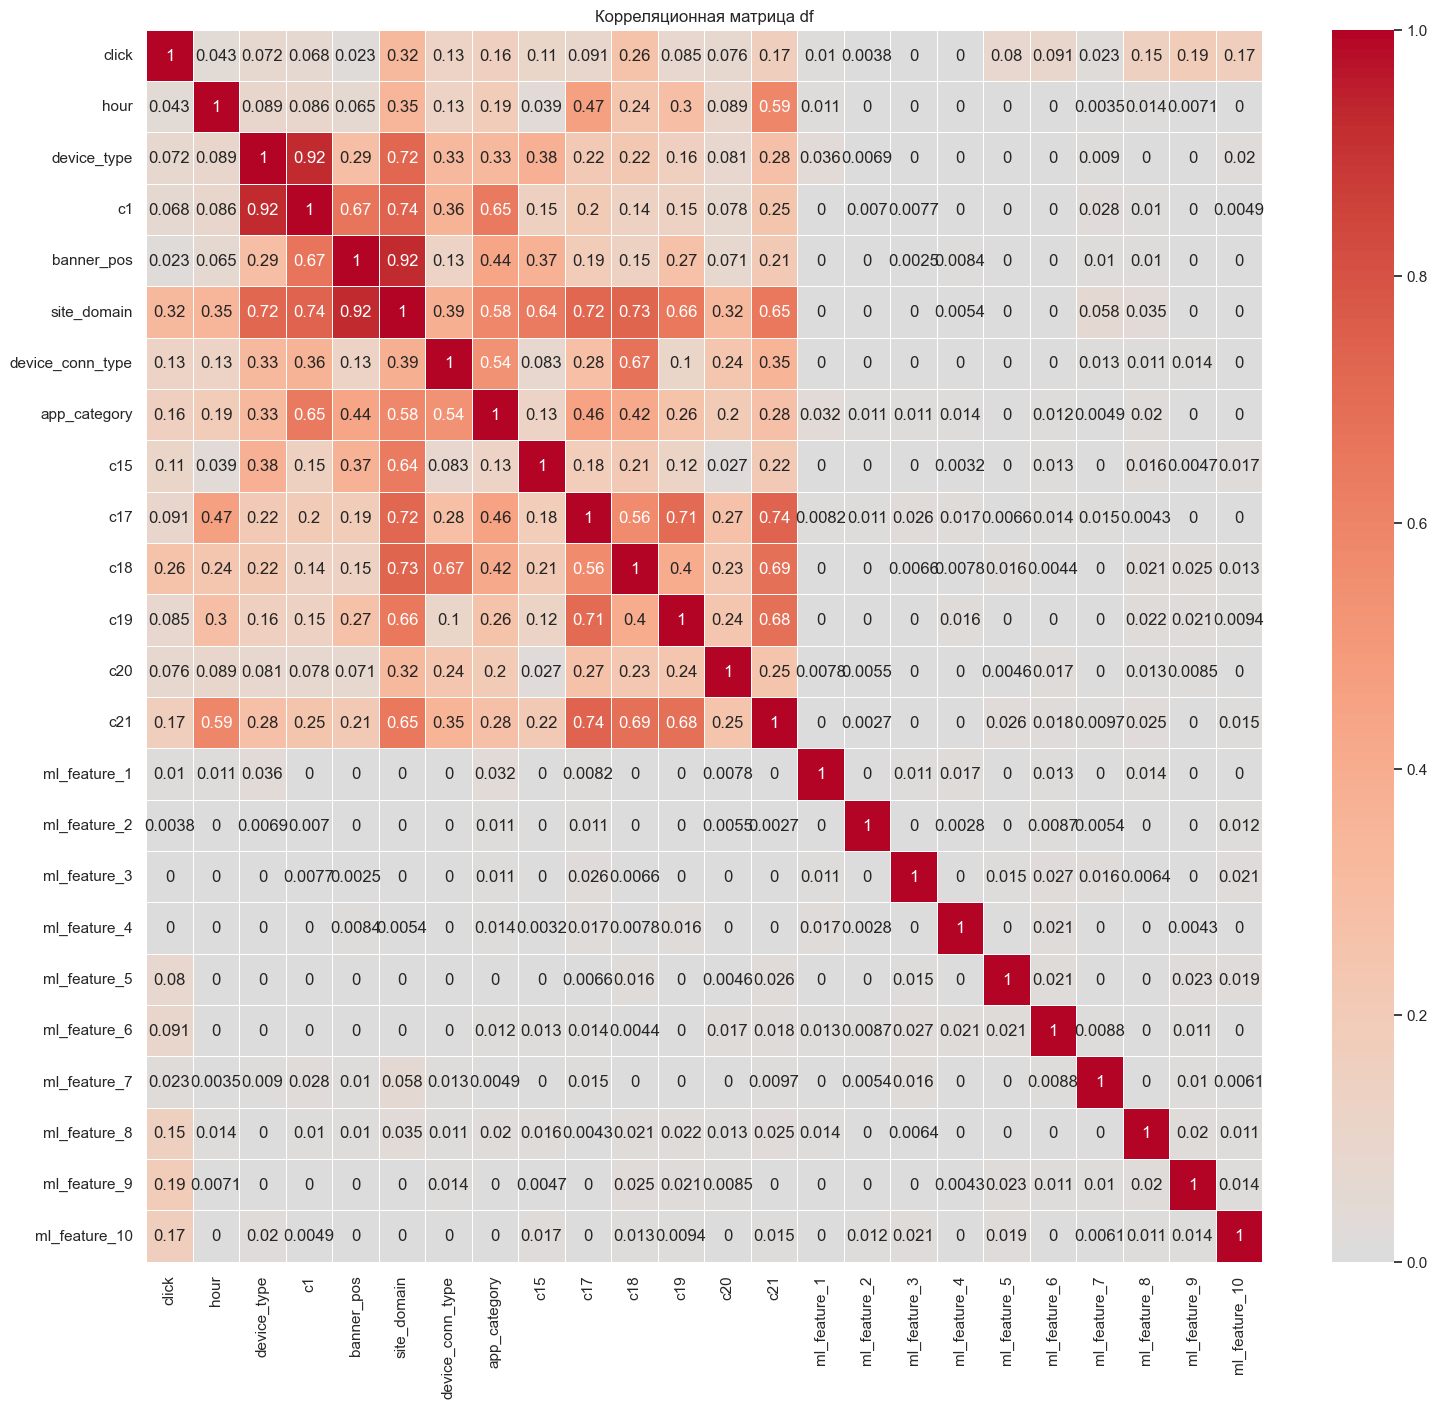

In [26]:
columns_to_analyze = [
     'click','hour', 'device_type', 'c1', 'banner_pos', 'site_domain', 
       'device_conn_type',  'app_category', 
       'c15', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1',
       'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9',
       'ml_feature_10'
]

continuous_features = ['hour', 'c1',  'c15', 'c17', 'c18', 'c19', 'c20', 'c21', 
                           'ml_feature_1', 
                           'banner_pos', 'device_type', 'device_conn_type',
                           'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 
                           'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

correlation_matrix = df[columns_to_analyze].phik_matrix(interval_cols=continuous_features)
#display(correlation_matrix)

# Построим тепловую карту
plt.figure(figsize=(18,16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица df')
plt.show()

##### В результате удаления признаков `'site_category', 'app_domain', 'с14', 'c16'` коэффициенты кореляции стали <0.93

C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(


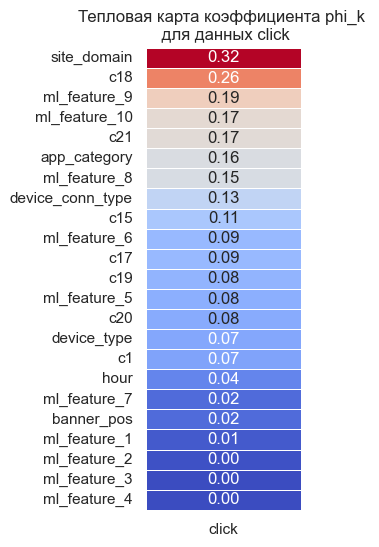

In [27]:
correl_matrix_column(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 
       'app_category',  'device_type',
       'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10'], 'click')

###### Перестроили корреляции для признака click. Наиболее сильная связи с site_domain (0.32) и c18 (0.26)


Удалим из датафрейма признаки: `'site_category', 'c14', 'c16', 'app_domain'`

In [28]:
df=df.drop(columns=['site_category', 'c14', 'c16', 'app_domain'])

In [29]:
df.columns

Index(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'app_category',
       'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10'],
      dtype='object')

### 3.0.8  2.8 Выводы по EDA
Кратко опишите ключевые находки.
Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
Определите действия по предобработке данных, которые необходимо проделать.

1. Датафрейм содержит: строк - 50000, столбцов - 34 

2. Названия столбцов датафрейма приведены к стилю snake case 

 Столбцов типа float: 8 : ['id', 'ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

 Столбцов типа object: 11
 : ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']
 Столбцов типа int: 15
 : ['click', 'hour', 'c1', 'banner_pos', 'device_type', 'device_conn_type', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_4']
 Столбцов типа datetime: 0 :[]
Пропусков нет.

3. Понизили разрядность числовых полей для экономии вычислительных ресурсов и памяти: преобразовано в  int  с понижением разрядности  15  полей, преобразовано в  float  с понижением разрядности  8  полей.

4. Явных дубликатов не обнаружено
5. Неявных дубликатов по столбцам ['id', 'hour', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_model', 'device_type', 'banner_pos', 'click'] не обнаружено

5. Целевая переменная `click` распределена не равномерно. 

Доля рекламы, на которую кликнули: **0.17%**.
Доля рекламы, на которую НЕ кликнули: **0.83%**

6. Обнаружено 10 категориальных признаков: 6 текстовых и 4 числовых. Числовых признаков 17.

7. Из 6 категориальных признаков: site_domain (1013), site_category (18), app_domain (67), app_category (22), ml_feature_2 (5), ml_feature_7 (3) наибольшее число категорий у site_domain и app_domain (1013 и 67 соответственно). К ним применим метод **TargetEncoder** и заменим данные средними значениями y.

Для преобразования site_category (18), app_category (22), ml_feature_2 (5), ml_feature_7 (3) воспользуемся **OneHotEncoder**

Для числовых: banner_pos (7), device_type (4), device_conn_type (4) посмотрим распределения с помощью столбиковых диаграмм.

8. Построили столбиковые диаграммы для изучения числовых категорий. Распределения не равномерные, в пользу одной какой-либо категории. Либо совсем удалить эти признаки, как не особенно подходящие для анализа рекламных объявлений по смыслу: тип устройства пользователя: например, смартфон, планшет, ПК (device_type), тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G (device_conn_type). Либо при обработке использовать стандартизацию StandardScaler, которая меньше реагирует на выбросы.

9. В ходе анализа распределений выявили:
 1. Признаки c1, c15, c16, c20, ml_feature_4` - дискретные числоыве признаки. По ним построим столбиковые диаграммы. Отнесём к категоиарьным данным.
 2. Признаки `hour, c14, c17, c19, c21` - непрерывные, много вершинные распределения (левый хвост), содержат выбросы
 3. Признаки `ml_feature_1, ml_feature_5,  ml_feature_10` - с нормальным распределением
 4. Признаки `ml_feature_3, ml_feature_6, ml_feature_9` - не содержат выбросов.

Очень сильный дисбаланс в данных: `'c1', 'c15', 'c16', 'c20', 'banner_pos', 'device_type', 'device_conn_type'` можно применить вычисления, например, извлечь корень квадратный

Для скошенных левосторонних распределений: `c14, c17, c19, c21` можно применить логарифмирование.

10. Коллинеарность между:
- device_model и c1 (0.95), site_domain (1), app_domain (0.99), app_category (0.9)
- с17и с14 0,99
- app_category app_domain 0.94, device_conn_type app_domain 0.85
- site_domain banner_pos 0.92
- site_category site_domain 0.99
- c1 device_type 0.88, c1 banner_pos 0.84

Не выявлено взаимосвязей для признаков: ml_feature_1 - ml_feature_10


Чтобы избавиться от коллинеарности уберём 'site_category', 'c14', 'c16', 'app_domain' .
В результате удаления признаков 'site_category', 'app_domain', 'с14', 'c16' коэффициенты кореляции стали <0.93


11. Перестроили корреляции для признака click. Наиболее сильная связи с site_domain (0.32) и c18 (0.26). 
12. Из датафрейма удалили признаки: `'site_category', 'c14', 'c16', 'app_domain'`.


**Таким образом, было решено :**
- применить логарифмирование к числовым признакам: `['c17', 'c19', 'c21']`
- применить извлечение квадратного корня к признакам: `['c20', 'banner_pos', 'device_type', 'device_conn_type']`
- категораильные признаки типа **object** преобразуем с помощью **OneHotEncoder**
- к признаку `'site_domain'` применим **TargetEncoder**, поскольку много категорий, больше 1000.

В последствии, от преобразований признаков отказалась, поскольку модели svc лучше не стала.

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

Разделим датафрейм на целевую функцию и признаки

In [30]:
X=df.drop(columns='click')
y=df['click']

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 22659 to 6020
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   click             50000 non-null  int8   
 1   hour              50000 non-null  int32  
 2   c1                50000 non-null  int16  
 3   banner_pos        50000 non-null  int8   
 4   site_domain       50000 non-null  object 
 5   app_category      50000 non-null  object 
 6   device_type       50000 non-null  int8   
 7   device_conn_type  50000 non-null  int8   
 8   c15               50000 non-null  int16  
 9   c17               50000 non-null  int16  
 10  c18               50000 non-null  int8   
 11  c19               50000 non-null  int16  
 12  c20               50000 non-null  int32  
 13  c21               50000 non-null  int16  
 14  ml_feature_1      50000 non-null  float32
 15  ml_feature_2      50000 non-null  object 
 16  ml_feature_3      50000 non-null  float32


Выделим тестовую выборку (20%), обучающую, валидационную и калибровочную выборки, используем стратифицированное разделение, чтобы сохранить баланс классов

X_train, X_test,  y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

In [32]:
# --- ШАГ 1: Отделяем финальный Тестовый набор (20% от N_TOTAL) ---
# Оставшиеся данные: 80% (400 образцов)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# --- ШАГ 2: Делим оставшиеся данные на Train, Validation и Calib ---

# Сначала отделяем Train
X_non_train, X_train, y_non_train, y_train = train_test_split(
    X_train_full, y_train_full, test_size=0.6, random_state=RANDOM_SEED, stratify=y_train_full
)

# Теперь делим X_non_train пополам для Validation и Calib
# test_size=0.5 гарантирует равное деление
X_calib, X_val, y_calib, y_val = train_test_split(
    X_non_train, y_non_train, test_size=0.5, random_state=RANDOM_SEED, stratify=y_non_train
)



In [33]:
X_val.shape

(8000, 23)

In [34]:
# --- Проверка размеров и целей ---
print(f"Общее количество образцов: {len(X)}")
print("-" * 40)
print("Набор данных | Размер | Цель")
print("-" * 40)
print(f"Тренировочный (Train) | {len(X_train)} | Обучение базовой модели")
print(f"Валидационный (Val)   | {len(X_val)}   | Настройка гиперпараметров")
print(f"Калибровочный (Calib) | {len(X_calib)}   | Обучение калибратора")
print(f"Тестовый (Test)       | {len(X_test)}  | Финальная оценка")
print("-" * 40)
print(f"Сумма: {len(X_train) + len(X_val) + len(X_calib) + len(X_test)}")


Общее количество образцов: 50000
----------------------------------------
Набор данных | Размер | Цель
----------------------------------------
Тренировочный (Train) | 24000 | Обучение базовой модели
Валидационный (Val)   | 8000   | Настройка гиперпараметров
Калибровочный (Calib) | 8000   | Обучение калибратора
Тестовый (Test)       | 10000  | Финальная оценка
----------------------------------------
Сумма: 50000


Убедимся, что сохранён баланс классов по y

In [35]:
display(y_train.mean(),y_val.mean(), y_calib.mean(), y_test.mean() )

np.float64(0.17204166666666668)

np.float64(0.172)

np.float64(0.172125)

np.float64(0.1721)

Разделили на `X_train, X_test,  y_train, y_test`, баланс сохранён

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

Предобработка и обучение модели проведем на **X_train** .

Категориальные признаки для **OneHotEncoder**:
ml_feature_2, ml_feature_7

Категориальные признаки для **TargetEncoder**:
site_domainб,app_domain 

Числовые категории, извлечь корень квадратный: 'c16', 'c20', 'banner_pos', 'device_type', 'device_conn_type' 

Числовые категории,  логарифмирование: c17, c19, c21

Числовые без преобразований: c18, ml_feature_1, ml_feature_3, ml_feature_4, ml_feature_5, ml_feature_6, ml_feature_8, ml_feature_9, ml_feature_10

In [36]:
df.columns

Index(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'app_category',
       'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10'],
      dtype='object')

In [37]:
# from sklearn.preprocessing import FunctionTransformer

def log_change(X):
    """
    Проверяет датафрейм и логарифмирует числовые колонки
    Отрицательные значения заменяются на 1e-10 перед операцией.
    """
    X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
    X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные
    
    for column in X_copy.columns:
        if np.issubdtype(X_copy[column].dtype, np.number):
            X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
            X_copy[column] = np.log1p(X_copy[column])   
    return X_copy 

def sqrt_change(X):
    """
    Проверяет датафрейм и извлекает корень квадратный из числовых колонок
    Отрицательные значения заменяются на 0 перед операцией.
    """
    X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
    X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные
    
    for column in X_copy.columns:
        if np.issubdtype(X_copy[column].dtype, np.number):
            X_copy[column] = np.sqrt(X_copy[column].clip(lower=0)) 
            
    return X_copy    


num_column = ['hour', 'c1', 'c15', 'c18', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 
                  'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 
                  'ml_feature_9', 'ml_feature_10']
log_column = ['c17', 'c19', 'c21']
sqrt_column = ['c20', 'banner_pos', 'device_type', 'device_conn_type']
cat_column = ['ml_feature_2', 'ml_feature_7']
catEnc_column = ['site_domain', 'app_category']


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

# словарь cv_results для сохранения результатов по трём метрикам: recall, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        'recall' : [],
        'precision' : [],
        'pr_auc' : [],
        'log_loss' : []
}

X_train = X_train.reset_index(drop=True) 
y_train = y_train.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('log', FunctionTransformer(log_change, validate=False)),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
sqrt_pipeline=Pipeline(steps=[
    ('sqrt', FunctionTransformer(sqrt_change, validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])

preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('sqrt_pipeline', sqrt_pipeline, sqrt_column),
            ('cat_pipeline', cat_pipeline, cat_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
    ])
full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
])

full_pipeline.fit(X_train, y_train)

res1 = cross_validate(
    estimator=full_pipeline,           # модель или pipeline
    X=X_train,                          # признаки
    y=y_train,                          # целевая переменная
    scoring=['recall', 'precision', 'average_precision', 'neg_log_loss'],   # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=-1                     # использовать все ядра
) 

cv_results_mean1 = {
     'recall': np.mean(res1["train_recall"]).round(3),  # среднее значение
     'precision' : np.mean(res1["train_precision"]).round(3),
     'pr_auc': np.mean(res1["train_average_precision"]).round(3),
    'log_loss': (-np.mean(res1["train_neg_log_loss"])).round(3) 
}

display(cv_results_mean1)


{'recall': np.float64(0.132),
 'precision': np.float64(0.621),
 'pr_auc': np.float64(0.411),
 'log_loss': np.float64(0.399)}

## 5. Отбор признаков

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

На этапе **EDA** (Корреляции 2.2) нами были определены коэффициенты корреляции и для целевой переменной `click` и для всех признаков датафрейма. В результате были удалено **5** признаков (`'device_model', 'site_category', 'c14', 'c16', 'app_domain'`) с коэффициентами корреняции больше 0.92

Теперь выведем 5 лучших и 5 худших корреляций, отбор автоматизируем:

In [38]:
df.columns

Index(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'app_category',
       'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10'],
      dtype='object')

C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(


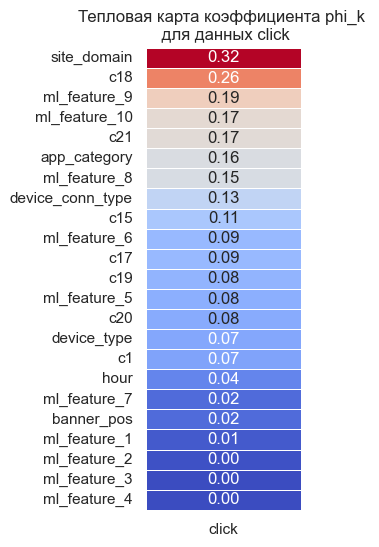

In [39]:
correl_matrix_column(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'app_category',
       'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10'], 'click')

К признакам **top**, с наилучшей корреляцией отнесём: `'site_domain', 'c18', 'ml_feature_9',
       'ml_feature_10',  'c21', 'app_category', 'ml_feature_8'`
       как признаки с ниибльшим коэффициентом корреляции.
       
       
**Отберём признаки с наилучщими и наихудшими корреляциями.** 

In [40]:
# Список признаков оценок по шкале 0-6, которые мы анализируем
rating_features = ['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'app_category',
       'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10']


continuous_features = ['hour', 'c1', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 
                           'ml_feature_1', 
                           'banner_pos', 'device_type', 'device_conn_type',
                           'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 
                           'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

phik_corr_matrix = df[rating_features].phik_matrix(interval_cols=continuous_features)


# Извлекаем корреляции для click
phik_click_correlation_all = phik_corr_matrix['click'].drop('click')

# Извлекаем корреляции с 'click' для признаков из списка rating_features
phik_click_rating = phik_click_correlation_all.filter(rating_features)

print("\n"+"="*80)
print(" АНАЛИЗ ИНФОРМАТИВНОСТИ (PHI_K vs. CLICK) - Только RATING_FEATURES")
print("="*80)
print("--- Признаки с самой слабой связью среди оценок ---")
# Выводим 5 самых слабых оценочных признаков
print(phik_click_rating.sort_values(ascending=False).tail(6).to_string(float_format="%.4f")) 

print("\n--- Признаки с самой сильной связью среди оценок ---")
# Выводим 5 самых сильных оценочных признаков
print(phik_click_rating.sort_values(ascending=False).head(6).to_string(float_format="%.4f"))


C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(



 АНАЛИЗ ИНФОРМАТИВНОСТИ (PHI_K vs. CLICK) - Только RATING_FEATURES
--- Признаки с самой слабой связью среди оценок ---
ml_feature_7   0.0226
banner_pos     0.0226
ml_feature_1   0.0101
ml_feature_2   0.0038
ml_feature_3   0.0000
ml_feature_4   0.0000

--- Признаки с самой сильной связью среди оценок ---
site_domain     0.3210
c18             0.2578
ml_feature_9    0.1878
ml_feature_10   0.1700
c21             0.1662
app_category    0.1565


**Удалите признаки с очень низкой вариацией `VarianceThreshold`**

Выявлены слабые взаимосвязи признаков с `click`. Самая сильные из них: `site_domain, c18` - домен веб-сайта и  параметры баннера, пользователя или аукциона.

Можно удалить самые слабые, практически нулевые, признаки, где **phik < 0.01**:
ml_feature_4, ml_feature_3, ml_feature_2 - ml_feature_1


Проверим ещё одним способом самые низкие корреляции, определим признаки очень низкой вариацией с помощью `VarianceThreshold` и удалим их.

In [41]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hour              24000 non-null  int32  
 1   c1                24000 non-null  int16  
 2   banner_pos        24000 non-null  int8   
 3   site_domain       24000 non-null  object 
 4   app_category      24000 non-null  object 
 5   device_type       24000 non-null  int8   
 6   device_conn_type  24000 non-null  int8   
 7   c15               24000 non-null  int16  
 8   c17               24000 non-null  int16  
 9   c18               24000 non-null  int8   
 10  c19               24000 non-null  int16  
 11  c20               24000 non-null  int32  
 12  c21               24000 non-null  int16  
 13  ml_feature_1      24000 non-null  float32
 14  ml_feature_2      24000 non-null  object 
 15  ml_feature_3      24000 non-null  float32
 16  ml_feature_4      24000 non-null  int8  

На этом этапе убрала преобразования логарифмирования и извлечение корня, поскольку эти вычисления не нужны для определения колонок, но мешатют при выводе.

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 22659 to 6020
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   click             50000 non-null  int8   
 1   hour              50000 non-null  int32  
 2   c1                50000 non-null  int16  
 3   banner_pos        50000 non-null  int8   
 4   site_domain       50000 non-null  object 
 5   app_category      50000 non-null  object 
 6   device_type       50000 non-null  int8   
 7   device_conn_type  50000 non-null  int8   
 8   c15               50000 non-null  int16  
 9   c17               50000 non-null  int16  
 10  c18               50000 non-null  int8   
 11  c19               50000 non-null  int16  
 12  c20               50000 non-null  int32  
 13  c21               50000 non-null  int16  
 14  ml_feature_1      50000 non-null  float32
 15  ml_feature_2      50000 non-null  object 
 16  ml_feature_3      50000 non-null  float32


In [43]:
# I. Подготовка данных
# Очистка: Удаление ID-колонок
df.drop(columns=[c for c in['Unnamed: 0', 'id'] if c in df.columns], inplace=True)

# Целевая переменная
y=df['click'].apply(lambda x: 1 if x == 'click' else 0)
X=df.drop('click', axis=1)

# Делим признаки на числовые и категориальные
# numerical_features нам не нужно поскольку делю 
# числовые признаки на способы их проебразования
# Делаю ради тренировки
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()


num_column = ['hour', 'c1', 'c15', 'c18', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 
                  'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 
                  'ml_feature_9', 'ml_feature_10']
log_column = ['c17', 'c19', 'c21']
sqrt_column = ['c20', 'banner_pos', 'device_type', 'device_conn_type']
cat_column = ['ml_feature_2', 'ml_feature_7']
catEnc_column = ['site_domain', 'app_category']


X_train = X_train.reset_index(drop=True) 
y_train = y_train.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
sqrt_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])


preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('sqrt_pipeline', sqrt_pipeline, sqrt_column),
            ('cat_pipeline', cat_pipeline, cat_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
        ],
        remainder='drop'
)

# Добавляем порог для отбора признаков.
# выберем малое значение, например 0.05 или 0.1, чтобы увидеть эффект.
selector = VarianceThreshold(threshold=0.16) 

full_pipeline2=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('selector', selector)
])

transformed_features=full_pipeline2.fit_transform(X_train, y_train)
feature_names=full_pipeline2.get_feature_names_out()

X_train_transformed=pd.DataFrame(transformed_features, columns=feature_names)


display('Исходные данные:\n', X_train.shape)
display('\nДанные после отбора:\n', X_train_transformed.shape)

'Исходные данные:\n'

(24000, 23)

'\nДанные после отбора:\n'

(24000, 24)

In [44]:
print(feature_names)

['num_pipeline__hour' 'num_pipeline__c1' 'num_pipeline__c15'
 'num_pipeline__c18' 'num_pipeline__ml_feature_1'
 'num_pipeline__ml_feature_3' 'num_pipeline__ml_feature_4'
 'num_pipeline__ml_feature_5' 'num_pipeline__ml_feature_6'
 'num_pipeline__ml_feature_8' 'num_pipeline__ml_feature_9'
 'num_pipeline__ml_feature_10' 'log_pipeline__c17' 'log_pipeline__c19'
 'log_pipeline__c21' 'sqrt_pipeline__c20' 'sqrt_pipeline__banner_pos'
 'sqrt_pipeline__device_type' 'sqrt_pipeline__device_conn_type'
 'cat_pipeline__ml_feature_2_D' 'cat_pipeline__ml_feature_2_E'
 'cat_pipeline__ml_feature_7_X' 'cat_pipeline__ml_feature_7_Y'
 'cat_pipeline__ml_feature_7_Z']


In [45]:
X_train_transformed.head()

,num_pipeline__hour,num_pipeline__c1,num_pipeline__c15,num_pipeline__c18,num_pipeline__ml_feature_1,num_pipeline__ml_feature_3,num_pipeline__ml_feature_4,num_pipeline__ml_feature_5,num_pipeline__ml_feature_6,num_pipeline__ml_feature_8,...,log_pipeline__c21,sqrt_pipeline__c20,sqrt_pipeline__banner_pos,sqrt_pipeline__device_type,sqrt_pipeline__device_conn_type,cat_pipeline__ml_feature_2_D,cat_pipeline__ml_feature_2_E,cat_pipeline__ml_feature_7_X,cat_pipeline__ml_feature_7_Y,cat_pipeline__ml_feature_7_Z
0,-1.505314,0.029043,0.048598,1.190146,-0.957802,-0.774303,-0.999000,1.828111,-1.138077,1.309430,...,-0.866262,0.937806,-0.567242,-0.03324,-0.387570,0.0,0.0,1.0,0.0,0.0
1,0.164233,0.029043,-0.874291,1.190146,1.334509,0.364040,-0.999000,-0.998129,1.439097,1.623348,...,-0.866262,0.936926,-0.567242,-0.03324,-0.387570,1.0,0.0,1.0,0.0,0.0
2,-1.150451,0.029043,0.048598,-1.069029,-1.632054,1.052466,-0.999000,-0.914200,-1.298288,-0.479401,...,-0.071973,-1.066453,-0.567242,-0.03324,-0.387570,1.0,0.0,1.0,0.0,0.0
3,1.522852,0.029043,0.048598,-1.069029,-0.190782,-0.814511,1.001001,-0.083688,0.564016,0.762633,...,-0.071973,-1.066453,-0.567242,-0.03324,-0.387570,0.0,0.0,0.0,1.0,0.0
4,-0.826004,0.029043,0.048598,1.190146,-0.100521,0.425573,1.001001,0.485417,-1.488030,0.417237,...,-0.979732,-1.066453,-0.567242,-0.03324,1.948949,1.0,0.0,0.0,0.0,1.0


Анализ применения двух подходов: 
- в первом случае удаляю сама признаки, которые попали в шестерку худших, потому что у них низкий коэффициент корреляции. Я вижу эти коллеряции, вижу названия признаков и удаляю. Удобно, понятно. Это можно сделать благодаря тому, что phik умеет обрабатывать категориальные признаки

- во втором случучае я не знаю какие именно признаки будут удалены, поскольку `VarianceThreshold` удаляет сам признаки с заданным порогом дисперсии. Кроме того, `VarianceThreshold` работает только с числовыми признаками, поэтому категориальные надо сперва преобразовать в числовые с помощью OneHotEncoder. Также применение StandardScaler может вызвать конфликт с `VarianceThreshold`. В нашем случае - обошлось, но признаки удаляются уже другие. Также метод все равно подвержен влиянию / мнению исследователя, потому что порог задаю я сама. Чтобы убрать 3 признака (после проебразований их было 25), порог дисперсии 0,16 устанавливала сама, подбирала.

Второй способ сразу встраивается в пайалайн, что удобно. Остальные признаки уберем другими метдами

#### 5.2  Примените методы-обёртки
Используйте методы-обёртки для поиска оптимального набора признаков.

1. Применяю пайплайн + обработка признаков по VarianceThreshold(из этапа 5) + обертка RFS

Просто всё в одном месте смотреть

пытаюсь в один пайплайн объединить всё

Последующая обработка full_pipeline. Применяем обёртку **RFE** к **логистическоё регрессии**

На данном этапе хотела в пайплайне ещё преобразовать признаки с помощью логарифмирования и извлечения квадратного корня. Для этого создала функции **fast_log_change** и **fast_sqrt_change** и включила в пайплайны **log_pipeline** и **sqrt_pipeline**. Здесь столкнулась с тем, что  в процессе преобразований, применений **fast_log_change** и **fast_sqrt_change** теряются названия столбцов. Выходит ошибка: 

AttributeError: Estimator log does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()? 

Имена столбцов нужны дальше, для определения и отбора самых  весомых на этапе применения оберток Как решить эту задачу? Если подскажете верное направление, то будет здорово!

**Ответы:**

-Добавь в FunctionTransformer параметр feature_names_out='one-to-one'
С учетом того, что ты не переименовываешь столбцы, это должно сработать
- Ошибка как будто указывает на то, что из модели, а не препроцессора метод вызывается. 
А какая версия sklearn у тебя? 
Лучше поставить 1.6.1 в старых версиях ColumnTransformer get_feature_names_out не поддерживал.
И еще для надежности установить опцию в sklearn, чтобы он всегда в пандас выводил:
    - from sklearn import set_config
    - set_config(transform_output="pandas")

25.07.26 На этапе "Финальный отчёт" обратила внимание на то, что **pr-auc** в базовой модели **LR** выше, чем в финальной, лучшей модели, хотя при отборе финальных параметров настройкм базовой модели **grid search** тоже перебирал.

Стала детальнее изучать проблему и выяснила, что на этапе **TargetEncoder** происходит **утечка данных**. Модель переобучается и **pr-auc** - завышена. Проверяла через замену TargetEncoder на CountEncoder. В результате такой замены метрика pr-auc в логистической регрессии упала с 0.408 до 0.339, а в svc с 0,239 до 0.197 **Утечка данных!!**

Решить утечку информации с TargetEncoder возможно с помощью:
1. `TargetEncoder(cv=5, smoothing=1.0)` Но в этом случае, библиотека category_encoders, она должна быть от версии 3.x. У меня версия `category_encoders 2.8.1`. Просто обновить до версии 3.x не получается - не дают зависимости других библиотек
2. Прописываем в TargetEncoder параметры, тогда строка пайплайна примет вид: 
('encoder', TargetEncoder(smoothing=1.0, handle_unknown='value', handle_missing='value')),

- handle_unknown='value': если в тесте появится новый домен, которого не было в обучении этого конкретного шага, он получит среднее значение таргета (после сглаживания), а не упадет с ошибкой.
- handle_missing='value': защищает от пропусков после импутации.

**Важно:** Этот вариант всё еще имеет небольшую утечку по сравнению с OOF-кодированием, но результат всё равно становиться луче. Было решено оставить так, но проверать вторым способом: через **обучение** пайплайна, в этом слуае переобучения нет.

**Вопро1с**: как решается утечка в случае TargetEncoder? У меня не получилось сделать всю предобработку обним пайплайном - распараллеливание процессов идёт. Пришлось делать по частям, в два этапа, поэтому утечка и образовалась(
**Ответ1**: проблема распараллеливания и и утечки решается, если не разбивать пайплайн на две части, всё сделать **за раз и тут же обучить!** (это оказался оптимальный вариант!)

**Стало лучше, но переобучение всё равно есть! Как исправить?**

**Ответ2**: Разбила пайплайн на два. В первом: преобразование столбцов без TargetEncoder и RFE, во втором:  TargetEncoder и SVC. Не такой сбалансированный способ, как единый пайплайн без функций!

**Вопрос2: как автоматизировать отбор разного типа признаков, а не в ручную? Потому что использование data.select_dtypes(include=[np.number]).columns выбираются все числовые признаки. А мне надо разбить их на группы: какие преобразовать логорифмированием, извлечением корня?**

**Вариант Б. Если цель — выжать максимум качества (Production / Kaggle)**
Убедитесь, что окружение позволяет импортировать dirty_cat.
Замените только одну строку:
from dirty_cat import TargetEncoder as SafeTargetEncoder

catEnc_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # Вся магия защиты скрыта здесь
    ('encoder', SafeTargetEncoder(smoothing=1.0)), 
    ('scaler', StandardScaler()) 
])

Этот вариант **не пошёл** - импортировать библиотеку **dirty_cat** корректно не получилось



**ИТАК, было создано и проверено на эффективность 3 варианта пайплайна svc модели:**
1. пайплан с преобразованием некоторых признаков (логарифмирование и извлечение корня) (PR_AUC на выбрках (базовая модель train), (Gred Search train), (Gred Search val), (калиброванная, на test) соответственно: 0.227, 0.3105, **0.1199**, 0.3051
2. единый пайплайн без преобразования признаков (PR_AUC на выбрках (базовая модель train), (Gred Search train), (Gred Search val), (калиброванная, на test) соответственно: 0.188, 0.3151, 0.2814, 0.2656
3. двойной пайплайн без преобразования признаков для уменьшения утечки TergetEncoder (PR_AUC на выбрках (базовая модель train), (Gred Search train), (Gred Search val), (калиброванная, на test) соответственно: 0.2, 0.2651, 0.1243, 0.2728.

**Лучший вариант2** (единый пайплайн без преобразования признаков), наиболее сбалансированный, на val метрика не "проваливается".

У **логистической регрессии** более стабильные результаты. Оставлен пайплайн с функциями логарифмирования и извлечения квадратного корня у части признаков.

**Создаём финальный пайплайн для логистической регрессии**

In [46]:
df.columns

Index(['click', 'hour', 'c1', 'banner_pos', 'site_domain', 'app_category',
       'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10'],
      dtype='object')

In [47]:
def log_change(X):
    """
    Проверяет датафрейм и логарифмирует числовые колонки
    Отрицательные значения заменяются на 1e-10 перед операцией.
    """
    X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
    X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные
    
    for column in X_copy.columns:
        if np.issubdtype(X_copy[column].dtype, np.number):
            X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
            X_copy[column] = np.log1p(X_copy[column])   
    return X_copy 

def sqrt_change(X):
    """
    Проверяет датафрейм и извлекает корень квадратный из числовых колонок
    Отрицательные значения заменяются на 0 перед операцией.
    """
    X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
    X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные
    
    for column in X_copy.columns:
        if np.issubdtype(X_copy[column].dtype, np.number):
            X_copy[column] = np.sqrt(X_copy[column].clip(lower=0)) 
            
    return X_copy    


num_column = ['hour', 'c1', 'c15', 'c18', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 
                  'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 
                  'ml_feature_9', 'ml_feature_10']
log_column = ['c17', 'c19', 'c21']
sqrt_column = ['c20', 'banner_pos', 'device_type', 'device_conn_type']
cat_column = ['ml_feature_2', 'ml_feature_7', 'app_category']
catEnc_column = ['site_domain']


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

# словарь cv_results для сохранения результатов по трём метрикам: recall, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        'recall' : [],
        'precision' : [],
        'pr_auc' : [],
        'log_loss' : []
}

X_train = X_train.reset_index(drop=True) 
y_train = y_train.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('log', FunctionTransformer(log_change, validate=False)),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
sqrt_pipeline=Pipeline(steps=[
    ('sqrt', FunctionTransformer(sqrt_change, validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder(smoothing=10.0, handle_unknown='value', handle_missing='value'))
    ])


preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('sqrt_pipeline', sqrt_pipeline, sqrt_column),
            ('cat_pipeline', cat_pipeline, cat_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
            
        ],
        remainder='drop',
        verbose_feature_names_out=False # Убираем технические префиксы в именах
)

#Названия столбцов берём только из препроцессинга preprocessor,
# тогда не попадут отобранные столбцы на этапе RFE
#transformed_features=preprocessor.transform(X_train)
#feature_names=preprocessor.get_feature_names_out()
#X_train_transformed_pre=pd.DataFrame(transformed_features, columns=feature_names)


lr_final_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('variance_filter', VarianceThreshold(threshold=0.0)),
     ('feature_selector', RFE(
        estimator=LogisticRegression(solver='liblinear', class_weight='balanced'),
        n_features_to_select=40, 
        step=1
    )),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced'))
])

# Создаем финальный пайплайн
lr_pipeline = lr_final_pipeline.fit(X_train, y_train)

prep_step = lr_final_pipeline.named_steps['preprocessing'] 
rfe_step = lr_final_pipeline.named_steps['feature_selector'] # RFE включает в себя VarianceFilter

# Имена ПОСЛЕ трансформации (индексы/метки энкодера)
transformed_features = prep_step.transform(X_train)
reduced_features = rfe_step.transform(transformed_features)

# Получаем имена, которые соответствуют уже уменьшенной матрице
final_feature_names = rfe_step.get_feature_names_out()

X_train_final = pd.DataFrame(reduced_features, columns=final_feature_names)

print(f"Выбрано трансформированных признаков: {len(final_feature_names)}")
print("Список трансформированных признаков:", final_feature_names.tolist())

Выбрано трансформированных признаков: 40
Список трансформированных признаков: ['c1', 'c15', 'c18', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'c17', 'c21', 'c20', 'banner_pos', 'device_type', 'device_conn_type', 'ml_feature_2_A', 'ml_feature_2_B', 'ml_feature_2_C', 'ml_feature_2_D', 'ml_feature_2_E', 'ml_feature_7_X', 'ml_feature_7_Y', 'ml_feature_7_Z', 'app_category_09481d60', 'app_category_0bfbc358', 'app_category_0f2161f8', 'app_category_0f9a328c', 'app_category_2281a340', 'app_category_4681bb9d', 'app_category_4ce2e9fc', 'app_category_75d80bbe', 'app_category_879c24eb', 'app_category_8ded1f7a', 'app_category_8df2e842', 'app_category_a3c42688', 'app_category_cef3e649', 'app_category_d1327cf5', 'app_category_dc97ec06', 'app_category_f95efa07', 'app_category_fc6fa53d', 'site_domain']


num_column = X.select_dtypes(include=['number']).columns.tolist()
cat_column = [
    col for col in X.select_dtypes(include=['object']).columns
    if col != 'site_domain'
]
catEnc_column = ['site_domain']


X_train = X_train.reset_index(drop=True) 
y_train = y_train.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        # Борьба с утечкой TargetEncoder
        ('encoder', TargetEncoder(smoothing=10.0, handle_unknown='value', handle_missing='value')), 
        ('scaler', StandardScaler()) 
    ])


preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('cat_pipeline', cat_pipeline, cat_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
            
        ],
        remainder='drop',
        verbose_feature_names_out=False # Убираем технические префиксы в именах
)

#Названия столбцов берём только из препроцессинга preprocessor,
# тогда не попадут отобранные столбцы на этапе RFE
#transformed_features=preprocessor.transform(X_train)
#feature_names=preprocessor.get_feature_names_out()
#X_train_transformed_pre=pd.DataFrame(transformed_features, columns=feature_names)


lr_final_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('variance_filter', VarianceThreshold(threshold=0.0)),
     ('feature_selector', RFE(
        estimator=LogisticRegression(solver='liblinear', class_weight='balanced'),
        n_features_to_select=40, 
        step=1
    )),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced'))
])

# Создаем финальный пайплайн
lr_pipeline = lr_final_pipeline.fit(X_train, y_train)

prep_step = lr_final_pipeline.named_steps['preprocessing'] 
rfe_step = lr_final_pipeline.named_steps['feature_selector'] # RFE включает в себя VarianceFilter

# Имена ПОСЛЕ трансформации (индексы/метки энкодера)
transformed_features = prep_step.transform(X_train)
reduced_features = rfe_step.transform(transformed_features)

# Получаем имена, которые соответствуют уже уменьшенной матрице
final_feature_names = rfe_step.get_feature_names_out()

X_train_final = pd.DataFrame(reduced_features, columns=final_feature_names)

print(f"Выбрано трансформированных признаков: {len(final_feature_names)}")
print("Список трансформированных признаков:", final_feature_names.tolist())

Финальный пайплайн lr_final_pipeline создан. В нём проводится полная предобработка данных, удяляются признаки с нулевыми весами (variance_filter), с помощью обертки RFE оставляются самые весомые признаки. Теперь этот пайплайн можно использовать для следующих работ, в том числе, для подбора параметров Grid Search

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

В качестве константной модели использовалась DummyClassifier (из библиотеки sckit-learn):

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html#sklearn.dummy.DummyClassifier - эта модель как раз создана для генерирования константных предсказаний.

Но можно вместо "most_frequent" задать параметр "stratified" для моделей с несбалансированной выборкой. В этом случае 0.72

In [48]:
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train)
DummyClassifier(strategy='stratified')
dummy_clf.predict(X_train)

dummy_model = dummy_clf.score(X_train, y_train)


In [49]:
print(dummy_model)

0.71325


**Вывод DummyClassifier**: точность базовой модели равна **0.83**. Это означает, любая построенная нами модель должна показывать существенно более высокую точность, чем 0.83, чтобы считаться полезной. 

Для несбалансированной выборки ('stratified') точность базовой модели равна **0.72**

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

Пайплайн **full_pipeline** с отбором признаков находится в пункте 5

In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

# словарь cv_results для сохранения результатов по трём метрикам: recall, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
lr_results={
        #'accuracy' : [],
        'recall' : [],
        'precision' : [],
        'pr_auc' : [],
        'log_loss' : []
}

scores_lr_basa = cross_validate(
    estimator=lr_final_pipeline,
    X=X_train,
    y=y_train,
    cv=cv, 
    scoring=['recall', 'precision', 'average_precision', 'neg_log_loss'],
    return_train_score=True, # Чтобы получить метрики и на трейне тоже
    n_jobs=-1 # Используем все ядра процессора для ускорения
)

lr_basa_results_mean1 = {
     #'accuracy': np.mean(scores["train_accuracy"]).round(3),  # среднее значение
     'recall': np.mean(scores_lr_basa["train_recall"]).round(3),  # среднее значение
     'precision' : np.mean(scores_lr_basa["train_precision"]).round(3),
     'pr_auc': np.mean(scores_lr_basa["train_average_precision"]).round(3),
     'log_loss': (-np.mean(scores_lr_basa["train_neg_log_loss"])).round(3) 
}

display(lr_basa_results_mean1)

{'recall': np.float64(0.665),
 'precision': np.float64(0.316),
 'pr_auc': np.float64(0.412),
 'log_loss': np.float64(0.589)}

In [51]:
lr_basa_results_mean = {
    key.replace('train_', ''): np.mean(value).round(3) 
    for key, value in scores_lr_basa.items() 
    if key.startswith('train')
}
print("Тренировочные метрики lr кросс-валидации:", lr_basa_results_mean)

Тренировочные метрики lr кросс-валидации: {'recall': np.float64(0.665), 'precision': np.float64(0.316), 'average_precision': np.float64(0.412), 'neg_log_loss': np.float64(-0.589)}


{'recall': np.float64(0.659),
 'precision': np.float64(0.314),
 'pr_auc': np.float64(0.408),
 'log_loss': np.float64(0.592)}
 
Отбор признаков улучшил модель. Очень низкие метритки: и по 'pr_auc': 0.4, и по 'log_loss': 0.592.

Accuracy= 0.832 чуть больше, чем у DummyClasifier = 0.828 такие метрики при lr_estimator = LogisticRegression(solver='liblinear')

Если добавить параметр для несбалансированной выборки lr_estimator = LogisticRegression(solver='liblinear', class_weight='balanced'), какя у нас есть, остальные метрики, кроме 'accuracy', повысятся



### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`


24.07.26 Поняла зачем в модели svc, на этом этапе (временно), надо установить probability=False, ведь тогда нельзя просчитать вероятности!!! Это надо для того, чтобы обучение gred search проходило не 40 минут, а быстро!!!

Использование двух моделей SVC позволяет:
- быстро отработать Grid Search на этапе отбора признаков RFE, поскольку применяется параметр probability=False
- подставить в лучшую модель параметр probability=True, сохранить лучшую модель с настройками и использовать её 

**Создаём финальный пайплайн для SVC**

Использование функций логарифмирования и извлечения корня ухудшают разделяющую поверхность модели, поэтому удалим их из пайплайна.

In [52]:
num_column = X.select_dtypes(include=['number']).columns.tolist()
cat_column = [
    col for col in X.select_dtypes(include=['object']).columns
    if col != 'site_domain'
]
catEnc_column = ['site_domain']


X_train = X_train.reset_index(drop=True) 
y_train = y_train.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        # Борьба с утечкой TargetEncoder
        ('encoder', TargetEncoder(smoothing=10.0, handle_unknown='value', handle_missing='value')), 
        ('scaler', StandardScaler()) 
    ])


preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('cat_pipeline', cat_pipeline, cat_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
            
        ],
        remainder='drop',
        verbose_feature_names_out=False # Убираем технические префиксы в именах
)


# 1. Создаем ОТДЕЛЬНЫЙ экземпляр для RFE 
svc_for_rfe = SVC(
    C=1.0,              
    kernel='linear', 
    probability=False, # TRUE сильно замедляет этап кросс валидации!
    class_weight='balanced', 
    random_state=RANDOM_SEED,    
    tol=0.001,           
    max_iter=1000        
)

# 2. Создаем отдельный экземпляр для финального классификатора 
# (можно с теми же параметрами, но это должен быть другой объект в памяти)
final_svc_classifier = SVC(
    C=1.0,              
    kernel='linear', 
    probability=True, # TRUE сильно замедляет этап кросс валидации!
    class_weight='balanced',
    random_state=RANDOM_SEED,    
    tol=0.001,           
    max_iter=1000        
)

# 3. Собираем пайплайн из разных объектов
svc_final_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('variance_filter', VarianceThreshold(threshold=0.0)),
    ('feature_selector', RFE(
        estimator=svc_for_rfe,       # Используем первый объект
        n_features_to_select=40, 
        step=1
    )),
    ('classifier', final_svc_classifier) # Используем второй объект
])


# Создаем финальный пайплайн
svc_basa = svc_final_pipeline.fit(X_train, y_train)

# Получение столбцов после этапа RFE
# Достаем промежуточные результаты через named_steps
prep_step = svc_final_pipeline.named_steps['preprocessing']
rfe_step = svc_final_pipeline.named_steps['feature_selector'] # RFE включает в себя VarianceFilter

start_time=time()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

# словарь cv_results для сохранения результатов по трём метрикам: recall, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        
        'recall' : [],
        'precision' : [],
        'pr_auc' : []
}

scores_svc_basa = cross_validate(
    estimator = svc_final_pipeline,
    X=X_train,
    y=y_train,
    cv=cv, 
    scoring=['recall', 'precision', 'average_precision'], 
    #error_score='raise', # <-- Ключевой параметр
    return_train_score=True, # Чтобы получить метрики и на трейне тоже
    n_jobs=-1 # Используем все ядра процессора для ускорения
)

cv_results_mean1 = {
    
     'recall': np.mean(scores_svc_basa["train_recall"]).round(3),  # среднее значение
     'precision' : np.mean(scores_svc_basa["train_precision"]).round(3),
     'pr_auc': np.mean(scores_svc_basa["train_average_precision"]).round(3)  
}

display(cv_results_mean1)
end_time=time()
print(f"Время обучения): {end_time - start_time:.2f} сек.")

C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_bas

{'recall': np.float64(0.563),
 'precision': np.float64(0.18),
 'pr_auc': np.float64(0.188)}

Время обучения): 35.80 сек.


def fast_log_change(X):
    """Векторизованная версия логарифмирования."""
    X = np.clip(X, a_min=1e-10, a_max=None) # Заменяем <= 0 на 1e-10
    return np.log1p(X)

def fast_sqrt_change(X):
    """Извлекает квадратный корень, защищая от отрицательных чисел."""
    X = np.clip(X, a_min=0, a_max=None)
    return np.sqrt(X)


def log_change(X):
    """
    Проверяет датафрейм и логарифмирует числовые колонки
    Отрицательные значения заменяются на 1e-10 перед операцией.
    """
    X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
    X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные
    
    for column in X_copy.columns:
        if np.issubdtype(X_copy[column].dtype, np.number):
            X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
            X_copy[column] = np.log1p(X_copy[column])   
    return X_copy 

def sqrt_change(X):
    """
    Проверяет датафрейм и извлекает корень квадратный из числовых колонок
    Отрицательные значения заменяются на 0 перед операцией.
    """
    X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
    X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные
    
    for column in X_copy.columns:
        if np.issubdtype(X_copy[column].dtype, np.number):
            X_copy[column] = np.sqrt(X_copy[column].clip(lower=0)) 
            
    return X_copy 

#I. Подготовка данных

num_column = ['hour', 'c1', 'c15', 'c18', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 
                  'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 
                  'ml_feature_9', 'ml_feature_10']
log_column = ['c17', 'c19', 'c21']
sqrt_column = ['c20', 'banner_pos', 'device_type', 'device_conn_type']
cat_column = ['ml_feature_2', 'ml_feature_7', 'app_category']
catEnc_column = ['site_domain']


X_train = X_train.reset_index(drop=True) 
y_train = y_train.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(fast_log_change, validate=False)),
        ('scaler', StandardScaler())
    ])
sqrt_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('sqrt', FunctionTransformer(fast_sqrt_change, validate=False)),
    ('scaler', StandardScaler())
])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        # Борьба с утечкой TargetEncoder
        ('encoder', TargetEncoder(smoothing=10.0, handle_unknown='value', handle_missing='value')), 
        ('scaler', StandardScaler()) 
    ])


preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('sqrt_pipeline', sqrt_pipeline, sqrt_column),
            ('cat_pipeline', cat_pipeline, cat_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
            
        ],
        remainder='drop',
        verbose_feature_names_out=False # Убираем технические префиксы в именах
)
# 1. Создаем ОТДЕЛЬНЫЙ экземпляр для RFE 
svc_for_rfe = SVC(
    C=1.0,              
    kernel='linear', 
    probability=False, # TRUE сильно замедляет этап кросс валидации!
    class_weight='balanced', 
    random_state=RANDOM_SEED,    
    tol=0.001,           
    max_iter=1000        
)

# 2. Создаем отдельный экземпляр для финального классификатора 
# (можно с теми же параметрами, но это должен быть другой объект в памяти)
final_svc_classifier = SVC(
    C=1.0,              
    kernel='linear', 
    probability=True, # TRUE сильно замедляет этап кросс валидации!
    class_weight='balanced',
    random_state=RANDOM_SEED,    
    tol=0.001,           
    max_iter=1000        
)

# 3. Собираем пайплайн из разных объектов
svc_final_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('variance_filter', VarianceThreshold(threshold=0.0)),
    ('feature_selector', RFE(
        estimator=svc_for_rfe,       # Используем первый объект
        n_features_to_select=40, 
        step=1
    )),
    ('classifier', final_svc_classifier) # Используем второй объект
])


# Создаем финальный пайплайн
svc_basa = svc_final_pipeline.fit(X_train, y_train)
print('Обучение завершено ...')

start_time=time()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

# словарь cv_results для сохранения результатов по трём метрикам: recall, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        
        'recall' : [],
        'precision' : [],
        'pr_auc' : []
}

scores_svc_basa = cross_validate(
    estimator = svc_final_pipeline,
    X=X_train,
    y=y_train,
    cv=cv, 
    scoring=['recall', 'precision', 'average_precision'], 
    #error_score='raise', # <-- Ключевой параметр
    return_train_score=True, # Чтобы получить метрики и на трейне тоже
    n_jobs=-1 # Используем все ядра процессора для ускорения
)

cv_results_mean1 = {
    
     'recall': np.mean(scores_svc_basa["train_recall"]).round(3),  # среднее значение
     'precision' : np.mean(scores_svc_basa["train_precision"]).round(3),
     'pr_auc': np.mean(scores_svc_basa["train_average_precision"]).round(3)  
}

display(cv_results_mean1)
end_time=time()
print(f"Время обучения): {end_time - start_time:.2f} сек.")

In [53]:
svc_basa_results_mean = {
    key.replace('train_', ''): np.mean(value).round(3) 
    for key, value in scores_svc_basa.items() 
    if key.startswith('train')
}
print("Тренировочные метрики svc кросс-валидации:", svc_basa_results_mean) 
print(f"Время выполнения svc: {end_time - start_time:.2f} сек.")

Тренировочные метрики svc кросс-валидации: {'recall': np.float64(0.563), 'precision': np.float64(0.18), 'average_precision': np.float64(0.188)}
Время выполнения svc: 35.80 сек.


{'recall': np.float64(0.593),
 'precision': np.float64(0.177),
 'f1': np.float64(0.27),
 'pr_auc': np.float64(0.175)}

Модель определяет срабатывание клика recall = 0,59 не особо высокая метрика, в 50%. Очень плохо предсказывает ложные события "0" precision=0.177. pr_auc и log_loss низкие. Надо улучшить модель, отобрав наилучшие параметры модели с помощью Grid Search.

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

 - У LogisticRegression Accuracy= 0.832 чуть больше, чем у DummyClasifier = 0.828 такие метрики при lr_estimator = LogisticRegression(solver='liblinear')

Если добавить параметр для несбалансированной выборки lr_estimator = LogisticRegression(solver='liblinear', class_weight='balanced'), какой у нас сеучас установлен, то остальные метрики по 'pr_auc': 0.402, и по 'log_loss': 0.598 немного повысились, а 'accuracy' снизилась до 0.69.

- Качество LogisticRegression выше по сравнению SVC (pr_auc= 0.164, log_loss = 0,465). 

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

Для модели SVC с линейным ядром основным параметром является C - уровень регулиризации. 

Создаем сетку параметров (param_grid) для модели SVC  SVC_final_pipeline

In [54]:
svc1_param_grid = {
    'classifier__C': [0.01, 0.05, 0.1, 0.5],  
    'classifier__class_weight': [
        None, 
        'balanced', 
        {0: 1.0, 1: 3.0}, 
        {0: 1.0, 1: 5.0}
    ],
    'classifier__kernel': ['linear'],
    'classifier__gamma': ['scale']
}


Для модели LogisticRegression с линейным ядром основным параметром является C - уровень регулиризации. 

In [55]:
lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__class_weight': [
        None, 
        'balanced', 
        {0: 1.0, 1: 30.6}, 
        {0: 1.0, 1: 6.0},
        {0: 1.0, 1: 5.5}
        #{0: 1.0, 1: 10.0},
        #{0: 1.0, 1: 20.0}
    ],
    
    # Важный параметр для LR: алгоритм оптимизации
    'classifier__solver': ['liblinear', 'saga'], 
    
    # Тип регуляризации
    'classifier__penalty': ['l1', 'l2'] 
    
    # Для решателей newton-cg, lbfgs, sag нужен только penalty='l2'
    # Для liblinear доступны 'l1' и 'l2'
}

In [56]:
y_train.unique()

array([1, 0], dtype=int8)

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

Применим Grid Search для обнаружения лучших параметров LogisticRegression

In [57]:
# Словарь параметров теперь обращается к шагам пайплайна по их именам


lr_grid_search = GridSearchCV(
    estimator = lr_final_pipeline,
    param_grid=lr_param_grid,
    cv=cv, 
    scoring='average_precision',
    n_jobs=-1,
    verbose=2                     # Чтобы видеть прогресс
)

# Обучение запускается сразу на сырых данных X_train и y_train
lr_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {lr_grid_search.best_params_}")
print(f"Лучшая метрика PR-AUC: {lr_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Лучшие параметры: {'classifier__C': 0.01, 'classifier__class_weight': {0: 1.0, 1: 5.5}, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Лучшая метрика PR-AUC: 0.3949


Лучшие параметры: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Лучшая метрика PR-AUC: 0.3933

**Применим Grid Search для обнаружения лучших параметров SVC**

Модель, представленная ниже считается. минут **4-5**.

Одновременно выбираются лучшие признаки и лучшая конфигурация **SVM**, собраны полноценном пайплайне `svc_final_pipeline`. 

In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

svc_grid_search1 = GridSearchCV(
    estimator = svc_final_pipeline,
    param_grid=svc1_param_grid,
    cv=cv, 
    scoring='average_precision', 
    refit='average_precision', # Оптимизируемся под лучший баланс охвата и точности
    n_jobs=-1,
    verbose=2   
)

# Обучение запускается сразу на сырых данных X_train и y_train
svc_grid_search1.fit(X_train, y_train)

print(f"Лучшие параметры: {svc_grid_search1.best_params_}")
print(f"Лучшая метрика PR-AUC: {svc_grid_search1.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_bas

Лучшие параметры: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Лучшая метрика PR-AUC: 0.3151


C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Лучшие параметры: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Лучшая метрика PR-AUC: 0.3347

**Сохраняем лучшую модель SVC в переменную `svc_best_estimator`**

In [59]:
# Сохраняем лучшую модель SVC в переменную svc_best_estimator
svc_best_estimator = svc_grid_search1.best_estimator_

In [60]:
print("Лучшая модель:", svc_best_estimator)

Лучшая модель: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hour', 'c1', 'banner_pos',
                                                   'device_type',
                                                   'device_conn_type', 'c15',
                                                   'c17', 'c18', 'c19', 'c20',
                                                   'c21', 'ml_feature_1',
                                                   'ml_feature_3',
                                                   'ml_feature_4',
                              

**Сохраняем лучшую модель Logistic Regresion в переменную `lr_best_estimator`**

In [61]:
lr_best_estimator = lr_grid_search.best_estimator_

In [62]:
print("Лучшая Logistic Regresion модель:", lr_best_estimator)

Лучшая Logistic Regresion модель: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hour', 'c1', 'c15', 'c18',
                                                   'ml_feature_1',
                                                   'ml_feature_3',
                                                   'ml_feature_4',
                                                   'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
                                        

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

In [63]:
print(f"Лучшие параметры: {svc_grid_search1.best_params_}")
print(f"Лучшая метрика PR-AUC: {svc_grid_search1.best_score_:.4f}")

Лучшие параметры: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Лучшая метрика PR-AUC: 0.3151


In [64]:
# Преобразуем результаты в DataFrame
svc_results_df = pd.DataFrame(svc_grid_search1.cv_results_)

# Сортируем по средней метрике на тестовых данных по убыванию
# Если вы не указывали refit='average_precision', колонка будет называться 'mean_test_score'
svc_sorted_results = svc_results_df.sort_values(by='mean_test_score', ascending=False)

# Формируем аккуратную таблицу только с нужными столбцами
svc_top_10 = svc_sorted_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(5)


In [65]:
lr_basa_results_mean = {
    key.replace('train_', ''): np.mean(value).round(3) 
    for key, value in scores_lr_basa.items() 
    if key.startswith('train')
}
print("Тренировочные метрики lr кросс-валидации:", lr_basa_results_mean)

Тренировочные метрики lr кросс-валидации: {'recall': np.float64(0.665), 'precision': np.float64(0.316), 'average_precision': np.float64(0.412), 'neg_log_loss': np.float64(-0.589)}


In [66]:
# Преобразуем результаты в DataFrame
lr_results_df = pd.DataFrame(lr_grid_search.cv_results_)

# Сортируем по средней метрике на тестовых данных по убыванию
# Если вы не указывали refit='average_precision', колонка будет называться 'mean_test_score'
lr_sorted_results = lr_results_df.sort_values(by='mean_test_score', ascending=False)

# Формируем аккуратную таблицу только с нужными столбцами
lr_top_10 = lr_sorted_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(5)

In [67]:
print("=" * 80)
print(f"{'СРАВНЕНИЕ ТОП-10 КОНФИГУРАЦИЙ МОДЕЛЕЙ':^80}")
print("=" * 80 + "\n")

# Блок для SVC
print("-" * 80)
print(f"{'ТОП-4 ЛУЧШИХ КОНФИГУРАЦИИ SVC:':^80}")
print("-" * 80)
# Используем to_string() напрямую от DataFrame без лишних фигурных скобок
print(svc_top_10.to_string(index=False))
print(f"\nЛучший PR-AUC (SVC): {svc_grid_search1.best_score_:.4f} | Параметры: {svc_grid_search1.best_params_}\n")

# Блок для Logistic Regression
print("-" * 80)
print(f"{'ТОП-6 ЛУЧШИХ КОНФИГУРАЦИЙ LOGISTIC REGRESSION:':^80}")
print("-" * 80)
print(lr_top_10.to_string(index=False))
print(f"\nЛучший PR-AUC (LR): {lr_grid_search.best_score_:.4f} | Параметры: {lr_grid_search.best_params_}\n")

print("=" * 80)

                     СРАВНЕНИЕ ТОП-10 КОНФИГУРАЦИЙ МОДЕЛЕЙ                      

--------------------------------------------------------------------------------
                         ТОП-4 ЛУЧШИХ КОНФИГУРАЦИИ SVC:                         
--------------------------------------------------------------------------------
                                                                                                                             params  mean_test_score  std_test_score  rank_test_score
      {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}         0.315064        0.022708                1
{'classifier__C': 0.01, 'classifier__class_weight': {0: 1.0, 1: 5.0}, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}         0.294979        0.052252                2
{'classifier__C': 0.01, 'classifier__class_weight': {0: 1.0, 1: 3.0}, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

**!!!** Проверку параметров проводим на обучающей выборке **train** 

Обучаем модель Logistic Regression 

In [68]:
best_lr_estimator = lr_grid_search.best_estimator_ 
y_pred_lr = best_lr_estimator.predict(X_train)
# Выведем подробный отчёт по метрикам
report = classification_report(y_train, y_pred_lr, digits=3)
print(report)

              precision    recall  f1-score   support

           0      0.917     0.626     0.744     19871
           1      0.288     0.729     0.413      4129

    accuracy                          0.644     24000
   macro avg      0.603     0.677     0.579     24000
weighted avg      0.809     0.644     0.687     24000



In [69]:
print(lr_grid_search.best_params_)

{'classifier__C': 0.01, 'classifier__class_weight': {0: 1.0, 1: 5.5}, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


Обучаем модель svc на выборке train

In [70]:
best_svc_estimator = svc_grid_search1.best_estimator_ 
y_pred_svc = best_svc_estimator.predict(X_train)
# Выведем подробный отчёт по метрикам
report = classification_report(y_train, y_pred_svc, digits=3)
print(report)

              precision    recall  f1-score   support

           0      0.000     0.000     0.000     19871
           1      0.172     1.000     0.294      4129

    accuracy                          0.172     24000
   macro avg      0.086     0.500     0.147     24000
weighted avg      0.030     0.172     0.051     24000



C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

Плохое разделение вероятностей, но лучший PR_AUC= 0,319 для svc Вообще все плохо по метрикам

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

**В этом разделе считаю метрики на обучающей выборке train!!!**

Обучаю снова, с лучшими параметрами Gred Search и probability=True

Считаю метрики PR-AUC на  выборке  **train** для **svc**

In [71]:
start_time=time()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

# словарь cv_results для сохранения результатов по трём метрикам: recall, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        'recall' : [],
        'precision' : [],
        'roc_auc' : [],
        'pr_auc' : []
        
}

scores = cross_validate(
    estimator = best_svc_estimator,
    X=X_train,
    y=y_train,
    cv=cv, 
    scoring=['recall', 'precision', 'roc_auc', 'average_precision'],
    return_train_score=True, # Чтобы получить метрики и на трейне тоже
    n_jobs=-1 # Используем все ядра процессора для ускорения
)

cv_results_mean1 = {
     'recall': np.mean(scores["train_recall"]).round(3),  # среднее значение
     'precision' : np.mean(scores["train_precision"]).round(3),
     'roc_auc' : np.mean(scores["train_roc_auc"]).round(3), 
     'pr_auc': np.mean(scores["train_average_precision"]).round(3)
     
}

display(cv_results_mean1)
end_time=time()
print(f"Время обучения): {end_time - start_time:.2f} сек.")

{'recall': np.float64(1.0),
 'precision': np.float64(0.172),
 'roc_auc': np.float64(0.683),
 'pr_auc': np.float64(0.334)}

Время обучения): 37.65 сек.


или вариант2 один раз однократно оцениваем на train

In [72]:
y_proba_train_svc = best_svc_estimator.predict_proba(X_train)[:, 1]
y_pred_train_svc = best_svc_estimator.predict(X_train)

final_metrics_train_svc = {
    # Оценка РАНЖИРОВАНИЯ (нужны вероятности)
    'ROC-AUC': roc_auc_score(y_train, y_proba_train_svc),
    'PR-AUC': average_precision_score(y_train, y_proba_train_svc),
    
    # Оценка КЛАССОВ (можно использовать predict() или вероятности > порога)
    'F1': f1_score(y_train, y_pred_train_svc),
    'Recall': recall_score(y_train, y_pred_train_svc),
    'Precision': precision_score(y_train, y_pred_train_svc)
}

# Округление для красивого вывода
final_metrics_train_svc_rounded = {k: round(v, 4) for k, v in final_metrics_train_svc.items()}
display(final_metrics_train_svc_rounded)

{'ROC-AUC': 0.6415,
 'PR-AUC': 0.2919,
 'F1': 0.2936,
 'Recall': 1.0,
 'Precision': 0.172}

способ1, через кросс валидацию
{'recall': np.float64(1.0),
 'precision': np.float64(0.172),
 'roc_auc': np.float64(0.683),
 'pr_auc': np.float64(0.334)}
Время обучения): 52.92 сек.

способ2, через обучение
{'ROC-AUC': 0.6415,
 'PR-AUC': 0.2919,
 'F1': 0.2936,
 'Recall': 1.0,
 'Precision': 0.172}
 
 Метрики **PR_AUC** несколько отличаются **0,33** и **0.29** на **train**  для двух способов 
Разницу в оценках - это небольшое  переобучение модели на 5 фолдах!!!   

In [73]:
print(f"Лучшая метрика PR-AUC на train: {svc_grid_search1.best_score_:.4f}")

Лучшая метрика PR-AUC на train: 0.3151


Лучшая метрика PR-AUC на train: 0.3151

Считаю метрики PR-AUC на val выборке для **LogisticRegression**

In [74]:
y_proba_train_lr = best_lr_estimator.predict_proba(X_train)[:, 1]
y_pred_train_lr = best_lr_estimator.predict(X_train)

final_metrics_train_lr = {
    # Оценка РАНЖИРОВАНИЯ (нужны вероятности)
    'ROC-AUC': roc_auc_score(y_train, y_proba_train_lr),
    'PR-AUC': average_precision_score(y_train, y_proba_train_lr),
    
    # Оценка КЛАССОВ (можно использовать predict() или вероятности > порога)
    'F1': f1_score(y_train, y_pred_train_lr),
    'Recall': recall_score(y_train, y_pred_train_lr),
    'Precision': precision_score(y_train, y_pred_train_lr)
}

# Округление для красивого вывода
final_metrics_train_lr_rounded = {k: round(v, 4) for k, v in final_metrics_train_lr.items()}
display(final_metrics_train_lr_rounded)

{'ROC-AUC': 0.7467,
 'PR-AUC': 0.4119,
 'F1': 0.4131,
 'Recall': 0.729,
 'Precision': 0.2883}

In [75]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

# словарь cv_results для сохранения результатов по трём метрикам: recall, F1-мера и ROC-AUC.

lr_results={
        'recall' : [],
        'precision' : [],
        'f1' : [],
        'pr_auc' : [],
        'log_loss' : []
}

scores = cross_validate(
    estimator=best_lr_estimator,
    X=X_train,
    y=y_train,
    cv=cv, 
    scoring=['recall', 'precision', 'f1', 'average_precision', 'neg_log_loss'],
    return_train_score=True, # Чтобы получить метрики и на трейне тоже
    n_jobs=-1 # Используем все ядра процессора для ускорения
)

lr_results_mean1 = {
     'recall': np.mean(scores["train_recall"]).round(3),  # среднее значение
     'precision' : np.mean(scores["train_precision"]).round(3),
     'f1': np.mean(scores["train_f1"]).round(3),        # среднее значение
     'pr_auc': np.mean(scores["train_average_precision"]).round(3),
     'log_loss': (-np.mean(scores["train_neg_log_loss"])).round(3) 
}

display(lr_results_mean1)

{'recall': np.float64(0.732),
 'precision': np.float64(0.286),
 'f1': np.float64(0.411),
 'pr_auc': np.float64(0.412),
 'log_loss': np.float64(0.637)}

способ1, через обучение

{'ROC-AUC': 0.7467,
 'PR-AUC': 0.4119,
 'F1': 0.4131,
 'Recall': 0.729,
 'Precision': 0.2882}

способ2, кросс валидация

{'recall': np.float64(0.732),
 'precision': np.float64(0.286),
 'f1': np.float64(0.411),
 'pr_auc': np.float64(0.412),
 'log_loss': np.float64(0.637)}


Аналогично SVC модель логистической регрессии немного переобучилась и метрика на ней несколько завышена (0,334), по правнению с predict_proba (0,2936)

********Для логистической регрессии метрики на тесте совпадают с расчетами. Мjдель - адекватна, научилась классифицировать 'ROC-AUC': 0.74.

LR модель логистической регрессии на тесте:

{'ROC-AUC': 0.7483,
 'PR-AUC': 0.4099,
 'F1': 0.2152,
 'Recall': 0.131,
 'Precision': 0.6018}

 Разделение на классы лучше, чем у SVC, но тоже не достаточно хорошо. Находит только 13% кликов и 60% нулей

**оценка Бриера**

Рассчитаем оценку **Бриера** на неотколиброванных данных на train для **LogisticRegression**

In [76]:
probabilities = best_lr_estimator.predict_proba(X_train) # predict_proba - метод, определяющий
# предсказанные вероятности классов. Всегда проводить тольео ПОСЛЕ обучения, метода predict?
# иначе будет утечка данных!!!
y_pred_lr = probabilities[:,1] # вероятности предсказанного положительного класса "1"
score = round(brier_score_loss(y_train, y_pred_lr), 3) 
print(score)

0.221


Оценка Бриера определяет качество вероятностных прогнозов для бинарной классификации. Значение **0,125** не большое, значит прогнозируемые вероятности близки к фактической частоте событий, вероятности правдоподобны.

Считаю оценку **Бриера** на train выборке для **svc**

In [77]:
probabilities = best_svc_estimator.predict_proba(X_train) # predict_proba - метод, определяющий
# предсказанные вероятности классов. Всегда проводить тольео ПОСЛЕ обучения, метода predict?
# иначе будет утечка данных!!!
y_pred_svc = probabilities[:,1] # вероятности предсказанного положительного класса "1"
score = round(brier_score_loss(y_train, y_pred_svc), 3) 
print(score)

0.14


Методом опорных векторов, модель svc, прогнозируемые вероятности предсказаны точнее, чем для логистической регрессии. 

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

In [78]:
# 1. Извлекаем объект классификатора с последнего шага пайплайна
classifier = best_lr_estimator.named_steps['classifier']

# 2. Извлекаем имена признаков, которые ВЫЖИЛИ после RFE 
#    (они уже прошли через весь препроцессинг)
selected_feature_names = best_lr_estimator.named_steps['feature_selector'].get_feature_names_out()

# 3. Получаем веса (коэффициенты). Для бинарной классификации это массив shape (1, n_features)
weights = classifier.coef_[0]

# 4. Собираем всё в DataFrame для удобного просмотра
feature_importance_df = pd.DataFrame({
    'feature': selected_feature_names,
    'weight': weights
})

# Сортируем по абсолютному значению веса, чтобы увидеть самые влиятельные факторы
feature_importance_df['abs_weight'] = feature_importance_df['weight'].abs()
feature_importance_df_lr = feature_importance_df.sort_values('abs_weight', ascending=False).drop(columns='abs_weight')

print(feature_importance_df_lr.head(25))

                  feature    weight
39            site_domain  4.876705
37  app_category_f95efa07  0.523676
6            ml_feature_9  0.366402
7           ml_feature_10  0.324391
5            ml_feature_8  0.182480
3            ml_feature_5  0.177061
4            ml_feature_6  0.147893
9                     c21 -0.140028
21         ml_feature_7_Z -0.131309
13       device_conn_type -0.119318
12            device_type -0.095429
2                     c18 -0.093787
8                     c17 -0.089161
10                    c20 -0.065555
34  app_category_cef3e649 -0.058962
14         ml_feature_2_A -0.045502
16         ml_feature_2_C -0.034285
11             banner_pos  0.029774
1                     c15  0.018693
0                      c1  0.000000
19         ml_feature_7_X  0.000000
15         ml_feature_2_B  0.000000
18         ml_feature_2_E  0.000000
17         ml_feature_2_D  0.000000
23  app_category_0bfbc358  0.000000


В модели логистической регрессии наиболее большие веса у **4** признаков, положительное влияние:  site_domain, ml_feature_9, ml_feature_10, ml_feature_8

**Веса модели svc**

In [79]:
classifier = best_svc_estimator.named_steps['classifier']
preprocessor = best_svc_estimator.named_steps['feature_selector'] # Исправлено имя ключа

weights = classifier.coef_[0]

# 2. Получаем имена столбцов после всех трансформаций
ohe_feature_names = preprocessor.get_feature_names_out()

# 3. Проверка размерности (защита от ошибок)
if len(ohe_feature_names) != len(weights):
    raise ValueError(f"Размерность весов {len(weights)} не совпадает с количеством признаков {len(ohe_feature_names)}")

# 4. Собираем DataFrame
feature_importance_df = pd.DataFrame({
    'feature': ohe_feature_names,
    'weight': weights
})

feature_importance_df['abs_weight'] = feature_importance_df['weight'].abs()
feature_importance_df = feature_importance_df.sort_values('abs_weight', ascending=False).drop(columns='abs_weight')

print(feature_importance_df.head(25))

                  feature    weight
39            site_domain  0.030436
10                    c21 -0.030368
2              banner_pos  0.029374
26  app_category_a3c42688  0.023024
1                      c1  0.021638
4        device_conn_type -0.018651
20  app_category_09481d60 -0.018117
19  app_category_07d7df22  0.018117
12           ml_feature_3 -0.017974
8                     c19 -0.016396
13           ml_feature_4 -0.014875
18          ml_feature_10  0.013849
6                     c17 -0.013333
9                     c20  0.013194
22  app_category_0f2161f8  0.011587
27  app_category_cef3e649 -0.010946
3             device_type -0.007239
37         ml_feature_7_Y  0.007059
14           ml_feature_5  0.006408
36         ml_feature_7_X -0.006244
23  app_category_0f9a328c -0.006039
25  app_category_8ded1f7a -0.006039
29  app_category_f95efa07 -0.006039
21  app_category_0bfbc358 -0.006039
35         ml_feature_2_E -0.004528


Для модели **svc** состав признаков немного другой. В топ-5 вошли: site_domain, ml_feature_9, c15, c21, ml_feature_2_E. Положительные признаки из них только site_domain и ml_feature_9, остальнве признаки - отрицательные. 

Заметим, что признак site_domain, ml_feature_9  входят в тройку лидеров для обеих моделей **SVC и Logistic Regression**.  Значит они действиельно важны и оказывают стабильный вклад в оценку вероятности клика.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].


**lr** и **SVC** модели, полученные после **Grid Search**

In [80]:
best_lr_estimator = lr_grid_search.best_estimator_ 
y_pred_lr = best_lr_estimator.predict(X_train)

In [81]:
y_pred_svc = best_svc_estimator.predict(X_train)

**Строим калибровочную кривую для модели логистической регрессии**

<Figure size 600x600 with 0 Axes>

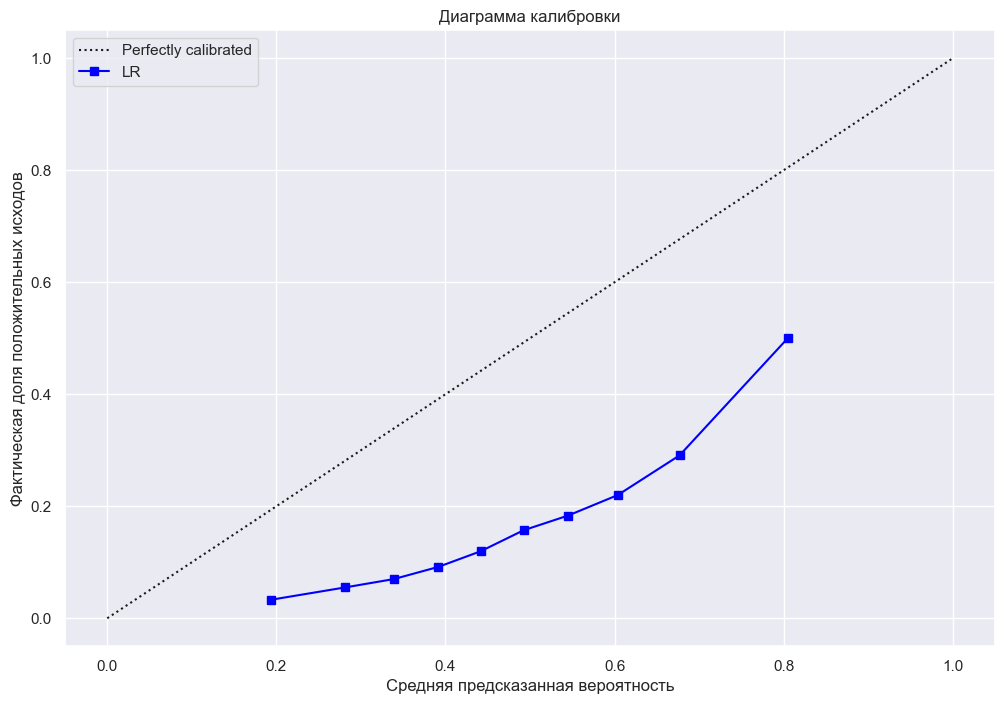

In [82]:
# 1. Получаем откалиброванные вероятности на ТЕСТОВОЙ выборке
# ВАЖНО: используем X_test (сырые данные), пайплайн сам применит препроцессинг
y_prob = best_lr_estimator.predict_proba(X_train)[:, 1]

# 2. Истинные метки тестовой выборки
y_true = y_train 

# 3. Вычисляем точки для кривой
prob_true, prob_pred = calibration_curve(
    y_true, 
    y_prob, 
    n_bins=10,          # Количество интервалов (бинов)
    strategy='quantile' # 'quantile' лучше распределяет точки при дисбалансе классов
)


# Визуализация через CalibrationDisplay
plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true, prob_pred, y_true).plot(label='LR', color='blue')
plt.title("Диаграмма калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()

В первых двух бинах вероятность предсказана верно. Наибольшие отклонения наблюдаются в 4, 7, 9 и 10. Например, в бине 4 модель слегка недооценивает вероятнсть, а в бине 9 наоборот немного завысила.

В целом, модель неплохо определила веса, но колибровка сделает вероятности более правдоподобными.

**Строим калибровочную кривую для модели SVC**

In [83]:
y_pred_svc = best_svc_estimator.predict(X_train)

<Figure size 600x600 with 0 Axes>

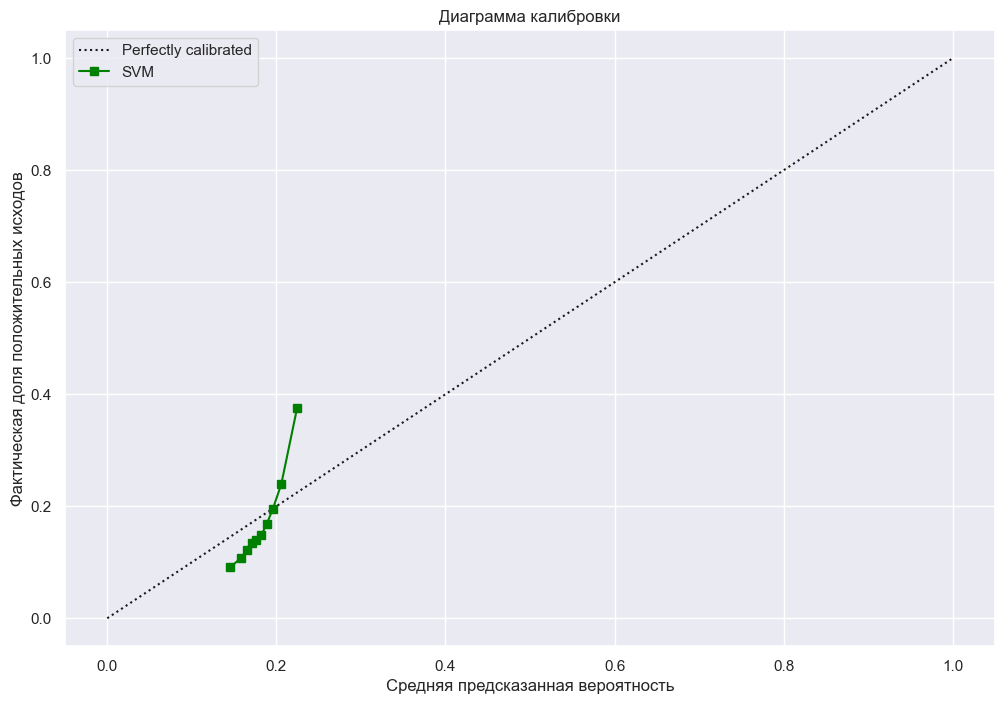

In [84]:
# 1. Получаем откалиброванные вероятности на ТЕСТОВОЙ выборке
# ВАЖНО: используем X_test (сырые данные), пайплайн сам применит препроцессинг
y_prob = best_svc_estimator.predict_proba(X_train)[:, 1]

# 2. Истинные метки тестовой выборки
y_true = y_train 

# 3. Вычисляем точки для кривой
prob_true, prob_pred = calibration_curve(
    y_train, 
    y_prob, 
    n_bins=10,          # Количество интервалов (бинов)
    strategy='quantile' # 'quantile' лучше распределяет точки при дисбалансе классов
)


# Визуализация через CalibrationDisplay
plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true, prob_pred, y_true).plot(label='SVM', color='green')
plt.title("Диаграмма калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()

Вероятности не соотвветствуют действительности!. Тут, на диаграмме это очень хорошо видно, все вероятности пересекают  идеальную прямую, а должны быть вдоль неё.

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

Для калибровки **svc** буду использовть калибровочную выборку **X_calib**

!!! Хотя и использую новую выборку X_calib, снова, отдельно выполнять предобработку не надо, поскольку она в модели svc_best_estimator сохранена и данные выборки X_calib подвергнуться тем же проебразованиям, что и на X_train!

Поскольку лучшая модель определена и сохранена, то с помощью frozen "заморозим" модель, т.е. её веса не будут меняться и пересчитываться.

In [85]:
frozen_svc = FrozenEstimator(best_svc_estimator)

# Шаг 2: Создаем калибратор iso_calibrator_svc
iso_calibrator_svc = CalibratedClassifierCV(
    estimator=frozen_svc, 
    method='isotonic', # или 'sigmoid'
    cv='prefit',              # Внутренняя кросс-валидация самого калибратора cv=5
    ensemble=False     # Критически важно при использовании FrozenEstimator
    
)

# Шаг 3: Обучаем ТОЛЬКО калибратор на отложенных данных
# ВАЖНО: X_calib должен быть "сырым" DataFrame (как ваш исходный X_train до препроцессинга)
display("Обучение калибратора...")
iso_calibrator_svc.fit(X_calib, y_calib) 
display("Калибровка завершена")

'Обучение калибратора...'

C:\Users\Geba\anaconda3\envs\my12_env\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


'Калибровка завершена'

In [86]:
# Получаем классы (0/1) на тесте
best_svc_estimator.predict(X_val)

array([1, 1, 1, ..., 1, 1, 1], shape=(8000,), dtype=int8)

In [87]:
# Получаем откалиброванные вероятности
final_probabilities_svc = iso_calibrator_svc.predict_proba(X_val)[:, 1]

**Считаем метрики откалиброванной модели svc**

In [88]:
y_proba_caliv_val_svc = iso_calibrator_svc.predict_proba(X_val)[:, 1]

final_metrics_calib_svc = {
    'ROC-AUC': roc_auc_score(y_val, y_proba_caliv_val_svc),
    'PR-AUC': average_precision_score(y_val, y_proba_caliv_val_svc),
    'F1': f1_score(y_val, (y_proba_caliv_val_svc > 0.5).astype(int)),
    'Recall': recall_score(y_val, (y_proba_caliv_val_svc > 0.5).astype(int)),
    'Precision': precision_score(y_val, (y_proba_caliv_val_svc > 0.5).astype(int))
}

# Округление для красивого вывода
final_metrics_calib_svc_rounded = {k: round(v, 4) for k, v in final_metrics_calib_svc.items()}
display(final_metrics_calib_svc_rounded)

{'ROC-AUC': 0.6384,
 'PR-AUC': 0.2715,
 'F1': 0.0672,
 'Recall': 0.0363,
 'Precision': 0.4505}

На тестовой выборке, результаты откалиброванной модели svc 

{'ROC-AUC': 0.6384,
 'PR-AUC': 0.2715,
 'F1': 0.0672,
 'Recall': 0.0363,
 'Precision': 0.4505}
 
. Эта метрика близка к рассчетам обучающей выборки.
 

**1. Как посмотреть результаты**

       y_true  probability
31401       1     0.522936
24705       1     0.132444
21494       0     0.132444
32301       0     0.234694
18610       0     0.128906


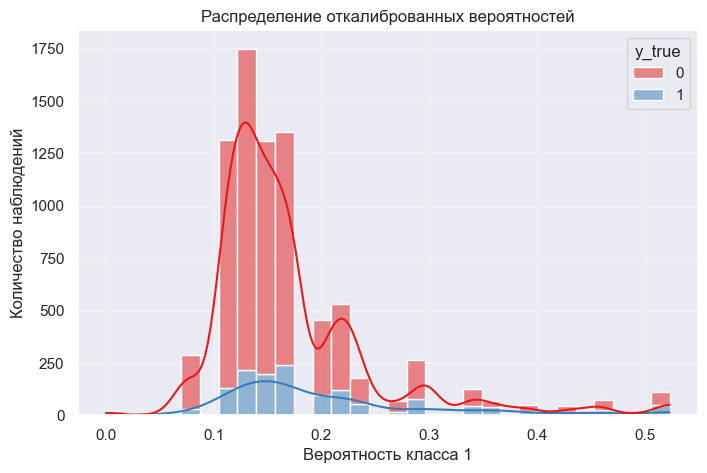

In [89]:
# Создаем DataFrame для удобства просмотра вместе с истинными метками
results_df = pd.DataFrame({
    'y_true': y_val,
    'probability': final_probabilities_svc
})

# Смотрим первые предсказания
print(results_df.head())

# Строим гистограмму распределения вероятностей
plt.figure(figsize=(8, 5))
sns.histplot(data=results_df, x='probability', hue='y_true', 
             bins=30, kde=True, palette='Set1', multiple='stack')
plt.title('Распределение откалиброванных вероятностей')
plt.xlabel('Вероятность класса 1')
plt.ylabel('Количество наблюдений')
plt.grid(True, alpha=0.3)
plt.show()

На что смотреть: В идеальной ситуации график должен быть бимодальным: большинство объектов класса 0 должны иметь вероятность близкую к 0, а объекты класса 1 — близкую к 1. Если распределение «размазано» посередине (около 0.5), модель не уверена в своих решениях.

В нашем случае модель ведет себя не уверенно!!!

**2. Что делать дальше: выбор порога (Threshold)**

In [90]:
precision, recall, thresholds = precision_recall_curve(y_val, final_probabilities_svc)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-10)

# Находим индекс лучшего F1
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"Оптимальный порог для F1: {optimal_threshold:.3f}")
print(f"F1-мера при этом пороге: {f1_scores[best_idx]:.3f}")

# Применяем новый порог к данным
final_predictions_optimal = (final_probabilities_svc >= optimal_threshold).astype(int)

Оптимальный порог для F1: 0.167
F1-мера при этом пороге: 0.343


Таким образом, при найденном оптимальном пороге для предсказаний в 0,162 мера F1 будет равна 0,329. Это низкое значение, опираясь на него, можно только сделать вывод о том, что надо учитывать дисбаланс классов при обучении, например, в сетке Grid Search задать значение 'balanced' или задать свой порог. Это было выполнено в пункте 7.1.

**Применим калибровку к модели Логистичекой регрессии**

In [91]:
best_lr_estimator = lr_grid_search.best_estimator_ 
#y_pred_lr = best_lr_estimator.predict(X_train)

In [92]:
frozen_lr = FrozenEstimator(best_lr_estimator)

# Шаг 2: Создаем калибратор
iso_calibrator_lr = CalibratedClassifierCV(
    estimator=frozen_lr, 
    method='isotonic', # или 'sigmoid'
    cv=5,              # Внутренняя кросс-валидация самого калибратора
    ensemble=False     # Критически важно при использовании FrozenEstimator
)

# Шаг 3: Обучаем ТОЛЬКО калибратор на отложенных данных
# ВАЖНО: X_calib должен быть "сырым" DataFrame (как ваш исходный X_train до препроцессинга)
display("Обучение калибратора...")
iso_calibrator_lr.fit(X_calib, y_calib) 
display("Калибровка завершена")

'Обучение калибратора...'

'Калибровка завершена'

In [93]:
# Получить жесткие классы (0/1)
best_lr_estimator.predict(X_val)

array([1, 0, 0, ..., 0, 0, 0], shape=(8000,), dtype=int8)

In [94]:
# Получить откалиброванные вероятности
final_probabilities_lr = iso_calibrator_lr.predict_proba(X_val)[:, 1]

**Считаем метрики откалиброванной модели lr**

In [95]:
y_proba_caliv_val_lr = iso_calibrator_lr.predict_proba(X_val)[:, 1]

final_metrics_calib_lr = {
    'ROC-AUC': roc_auc_score(y_val, y_proba_caliv_val_lr),
    'PR-AUC': average_precision_score(y_val, y_proba_caliv_val_lr),
    'F1': f1_score(y_val, (y_proba_caliv_val_lr > 0.5).astype(int)),
    'Recall': recall_score(y_val, (y_proba_caliv_val_lr > 0.5).astype(int)),
    'Precision': precision_score(y_val, (y_proba_caliv_val_lr > 0.5).astype(int))
}

# Округление для красивого вывода
final_metrics_calib_lr_rounded = {k: round(v, 4) for k, v in final_metrics_calib_lr.items()}
display(final_metrics_calib_lr_rounded)

{'ROC-AUC': 0.7436,
 'PR-AUC': 0.3856,
 'F1': 0.2144,
 'Recall': 0.1301,
 'Precision': 0.6088}

Смотрим результаты

       y_true  probability
31401       1     0.641509
24705       1     0.126042
21494       0     0.105408
32301       0     0.297872
18610       0     0.105408


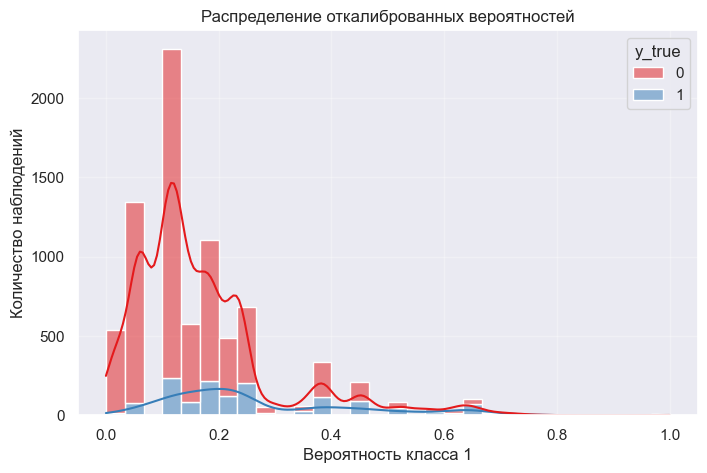

In [96]:
# Создаем DataFrame для удобства просмотра вместе с истинными метками
results_df = pd.DataFrame({
    'y_true': y_val,
    'probability': final_probabilities_lr
})

# Смотрим первые предсказания
print(results_df.head())

# Строим гистограмму распределения вероятностей
plt.figure(figsize=(8, 5))
sns.histplot(data=results_df, x='probability', hue='y_true', 
             bins=30, kde=True, palette='Set1', multiple='stack')
plt.title('Распределение откалиброванных вероятностей')
plt.xlabel('Вероятность класса 1')
plt.ylabel('Количество наблюдений')
plt.grid(True, alpha=0.3)
plt.show()

Распределение откалиброванных вероятностей лучше, по сравнению с SVC, но тоже четкого разделения классов нет. Модель ведет себя не уверенно

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

**Проверряем модели на тестовой выборке!!!**

**Модель SVC**

оценки Бриера для модели до и после калибровки практически не изменились. Чуть-чуть стали лучше, на 0.002. Но калибровочная кривая стала значительно лучше! Калибровка сделала лучше модель!

оценка Бриера ПОСЛЕ калибровки равна 0.135

In [97]:
final_probabilities_all = iso_calibrator_svc.predict_proba(X_val)
y_pred_svc_calib = final_probabilities_all[:, 1] # вероятность класса 1
score_svc_calib = round(brier_score_loss(y_val, y_pred_svc_calib), 3) 
print(score_svc_calib)

0.137


оценка Бриера ДО калибровки равна 0.14

In [98]:
probabilities = best_svc_estimator.predict_proba(X_train) # predict_proba - метод, определяющий
# предсказанные вероятности классов. Всегда проводить тольео ПОСЛЕ обучения, метода predict?
# иначе будет утечка данных!!!
y_pred_svc = probabilities[:,1] # вероятности предсказанного положительного класса "1"
score = round(brier_score_loss(y_train, y_pred_svc), 3) 
print(score)

0.14


После калибровки вероятность улучшилась не значительно, на 0.01 для класса 1. 

**Оценка качества калибровки SVC**

Чтобы убедиться, что изотоническая регрессия сработала правильно, построим диаграмму калибровки именно на тестовых данных:

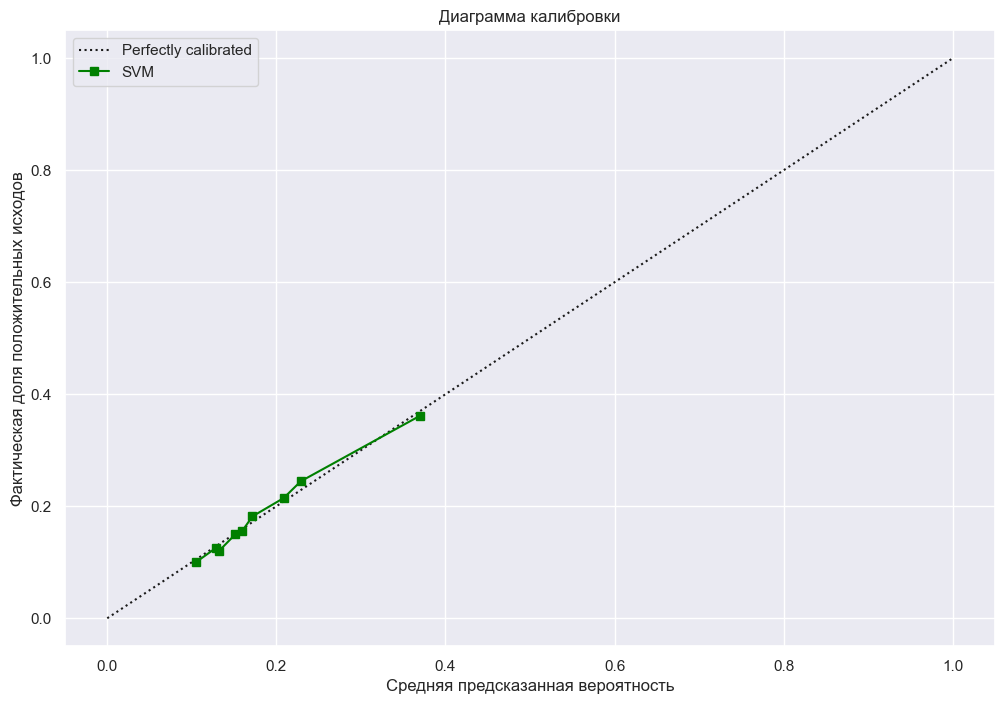

In [99]:
prob_true, prob_pred = calibration_curve(y_val, y_pred_svc_calib, n_bins=10, strategy='quantile')

CalibrationDisplay(prob_true, prob_pred, y_val).plot(label='SVM', color='green')
plt.title("Диаграмма калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()


Калибровочная линия в точках вначаае и в конца немного отклоняется от эталона.  

Но в целом, калибровочная кривая стала гораздо лучше на графике, по сравнению с превоначальным, вертикальным графиком (до колибрования)

**Модель логистической регрессии**

оценка Бриера после калибровки равна 0.125.

In [100]:
final_probabilities_lr = iso_calibrator_lr.predict_proba(X_val)
y_pred_lr_calib = final_probabilities_lr[:, 1] # вероятность класса 1
score_lr_calib = round(brier_score_loss(y_val, y_pred_lr_calib), 3) 
print(score_lr_calib)

0.125


оценка Бриера ДО калибровки равна 0.125

In [101]:
probabilities = best_lr_estimator.predict_proba(X_train) # predict_proba - метод, определяющий
# предсказанные вероятности классов. Всегда проводить тольео ПОСЛЕ обучения, метода predict?
# иначе будет утечка данных!!!
y_pred_lr = probabilities[:,1] # вероятности предсказанного положительного класса "1"
score_lr = round(brier_score_loss(y_train, y_pred_lr), 3) 
print(score_lr)

0.221


**Оценка качества калибровки Logistic Regression**

Чтобы убедиться, что изотоническая регрессия сработала правильно, построим диаграмму калибровки именно на тестовых данных:

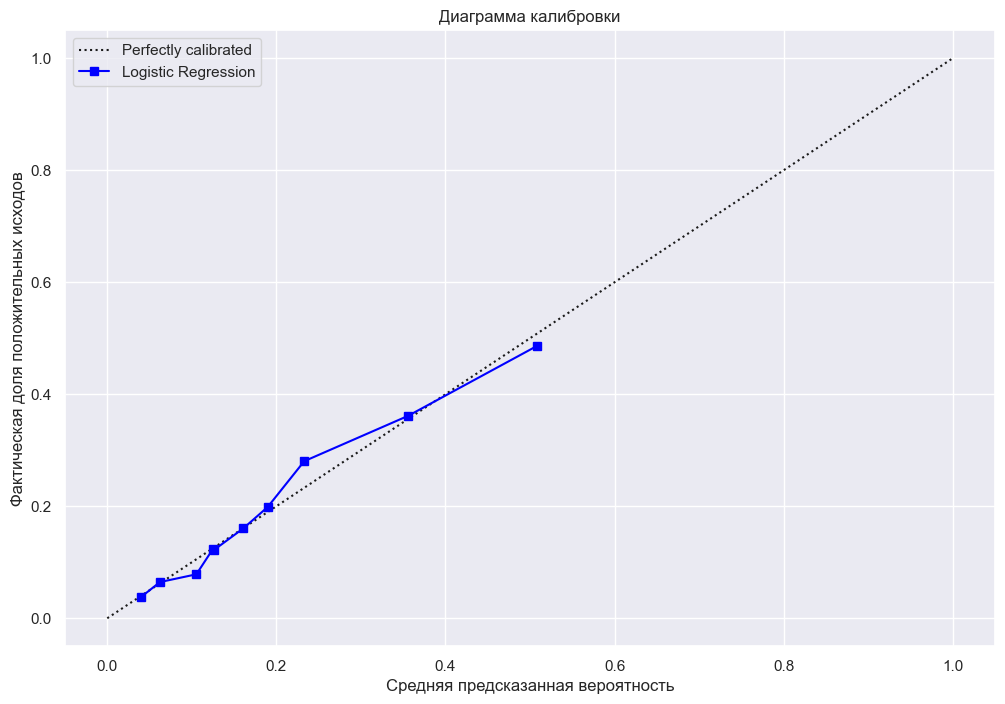

In [102]:
y_true = y_val
y_prob = y_pred_lr_calib 

prob_true, prob_pred = calibration_curve(y_val, y_prob, n_bins=10, strategy='quantile')

CalibrationDisplay(prob_true, prob_pred, y_prob).plot(label='Logistic Regression', color='blue')
plt.title("Диаграмма калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()


Здесь видно, что предсказанные вероятности тоже изменились. Но график калибровочной кривой **изменился в худшую** сторону. Отклонения от эталона в бинах стали больше. Проверим это на следующем этапе  исследования, с помощью дополнительных метрик **MCE и ECE** .

Есть подозрение, что калибровка весов для **логистической регрессии не требуется**. Веса для логистической регрессии хорошо определены самой моделью (алгоритм такой).

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

Калибровку по оценке Бриера нашли выше, в пункте 9.3 и сравнили результаты. Здесь рассчитаем MCE и ECE 

**Оценка MCE**

In [103]:
def calculate_mce(y_true, y_prob, n_bins=10):
    """
    Вычисляет Maximum Calibration Error (MCE).

    MCE — это максимальная разница между уверенностью модели и её
    фактической точностью в любом из бинов.

    Args:
        y_true (np.array): Истинные метки классов (0 или 1).
        y_prob (np.array): Предсказанные вероятности для класса 1.
        n_bins (int): Количество интервалов (бинов) для разбиения вероятностей.

    Returns:
        float: Значение MCE, равное наибольшей ошибке.
    """
    # Создаем границы бинов от 0 до 1, например, [0.0, 0.1, ..., 1.0].
    bins = np.linspace(0, 1, n_bins + 1)
    
    # Инициализируем максимальную ошибку нулем.
    max_error = 0
    
    # Итерируемся по каждому бину.
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Создаем логическую маску, чтобы выбрать объекты,
        # чьи вероятности попадают в текущий бин.
        # Последний бин включает верхнюю границу (1.0).
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)

        # Продолжаем, только если в бине есть хотя бы один объект.
        if np.sum(mask) > 0:
            # Вычисляем среднюю уверенность модели для этого бина.
            bin_conf = np.mean(y_prob[mask])#_______ Ваш код

            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask]) #_______ Ваш код

            # Вычисляем абсолютную разницу между точностью и уверенностью.
            diff = np.abs(bin_conf - bin_acc) #_______ Ваш код

            # Обновляем максимальную ошибку, если текущая разница больше.
            max_error =  max(max_error, diff) #_______ Ваш код
            
    # Возвращаем наибольшую найденную разницу.
    return max_error



MCE для SVC

In [104]:
# Истинные метки (0 или 1)
y_true = y_val

# Вероятности, предсказанные моделью для класса "1"
y_prob = y_pred_svc_calib

mce_value_svc = calculate_mce(y_true, y_prob, n_bins=5)
print("\nMaximum Calibration Error (MCE):", round(mce_value_svc, 3))



Maximum Calibration Error (MCE): 0.077


MCE для LR ПОСЛЕ калибровки

In [105]:
# Истинные метки (0 или 1)
y_true = y_val

# Вероятности, предсказанные моделью для класса "1"
y_prob = y_pred_lr_calib

mce_value_lr_calib = calculate_mce(y_true, y_prob, n_bins=5)
print("\nMaximum Calibration Error (MCE):", round(mce_value_lr_calib, 3))



Maximum Calibration Error (MCE): 0.03


MCE для LR ДО калибровки

In [106]:
# Истинные метки (0 или 1)
y_true = y_train

# Вероятности, предсказанные моделью для класса "1"
y_prob = y_pred_lr

mce_value_lr = calculate_mce(y_true, y_prob, n_bins=5)
print("\nMaximum Calibration Error (MCE):", round(mce_value_lr, 3))


Maximum Calibration Error (MCE): 0.375


Таким образом, сравнивая оценки MCE на моделях SVC и Logistic Regression, более худший показатель у модели SVC (0.077).

Для логистической регрессии ПОСЛЕ калибровки, метрика MCE стала лучше (0,375 и 0,03) значительно.


**оценка ECE**

In [107]:
def calculate_ece(y_true, y_prob, n_bins=10):
    """
    Вычисляет Expected Calibration Error (ECE) для предсказаний модели.
    
    ECE измеряет, насколько хорошо предсказанные вероятности модели
    соответствуют реальной частоте правильных предсказаний.
    
    Args:
        y_true (np.array): Истинные метки классов (0 или 1).
        y_prob (np.array): Предсказанные вероятности для класса 1.
        n_bins (int): Количество интервалов (бинов) для разбиения вероятностей.
        
    Returns:
            float: Значение ECE.
    """
    # Создаем границы бинов, равномерно распределенные от 0 до 1.
    # Например, для n_bins=10, это будут [0.0, 0.1, 0.2, ..., 1.0].
    bins = np.linspace(0, 1, n_bins + 1)
    
    ece = 0  # Инициализируем общую ошибку калибровки.
    n = len(y_true)  # Общее количество примеров.
    
    print("Расчет ECE по бинам:")
    
    # Итерируемся по каждому бину.
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Создаем логическую маску для отбора примеров, которые попадают в текущий бин.
        # Последний бин (i == n_bins - 1) включает правую границу, чтобы захватить
        # вероятность 1.0, остальные - нет.
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        
        # Проверяем, есть ли в текущем бине хотя бы один пример.
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            
            # Вычисляем среднюю предсказанную уверенность (confidence) для бина.
            bin_conf = np.mean(y_prob[mask])
            
            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask])
            
            # Вычисляем вклад текущего бина в общую ошибку.
            # Это абсолютная разница, умноженная на количество примеров в бине.
            contribution = np.abs(bin_conf - bin_acc) * bin_size
            ece += contribution
            
            # Выводим подробную информацию о расчетах для каждого бина.
            print(f"Бин {i+1} [{bin_lower:.2f}-{bin_upper:.2f}): размер={bin_size}, уверенность={bin_conf:.3f}, точность={bin_acc:.3f}, вклад={contribution / n:.3f}")
    
    # Возвращаем итоговое значение ECE, нормированное на общее количество примеров.
    return ece / n


ECE для SVC

In [108]:
# Истинные метки (0 или 1)
y_true = y_val

# Вероятности, предсказанные моделью для класса "1"
y_prob = y_pred_svc_calib

ece_value_svc = calculate_ece(y_true, y_prob, n_bins=5)

# Выводим итоговое значение ECE.
print(f"\nИтоговый ECE: {ece_value_svc:.3f}")

Расчет ECE по бинам:
Бин 1 [0.00-0.20): размер=6025, уверенность=0.137, точность=0.135, вклад=0.001
Бин 2 [0.20-0.40): размер=1744, уверенность=0.253, точность=0.268, вклад=0.003
Бин 3 [0.40-0.60): размер=231, уверенность=0.484, точность=0.407, вклад=0.002

Итоговый ECE: 0.007


ECE для LR

In [109]:
# Истинные метки (0 или 1)
y_true = y_val

# Вероятности, предсказанные моделью для класса "1"
y_prob = y_pred_lr_calib

ece_value_lr_calib = calculate_ece(y_true, y_prob, n_bins=5)

# Выводим итоговое значение ECE.
print(f"\nИтоговый ECE: {ece_value_lr_calib:.3f}")


Расчет ECE по бинам:
Бин 1 [0.00-0.20): размер=5882, уверенность=0.111, точность=0.106, вклад=0.004
Бин 2 [0.20-0.40): размер=1609, уверенность=0.270, точность=0.300, вклад=0.006
Бин 3 [0.40-0.60): размер=335, уверенность=0.485, точность=0.463, вклад=0.001
Бин 4 [0.60-0.80): размер=169, уверенность=0.649, точность=0.657, вклад=0.000
Бин 5 [0.80-1.00): размер=5, уверенность=1.000, точность=1.000, вклад=0.000

Итоговый ECE: 0.011


ECE для LR ДО калибровки

In [110]:
# Истинные метки (0 или 1)
y_true = y_train

# Вероятности, предсказанные моделью для класса "1"
y_prob = y_pred_lr

ece_value_lr = calculate_ece(y_true, y_prob, n_bins=5)

# Выводим итоговое значение ECE.
print(f"\nИтоговый ECE: {ece_value_lr:.3f}")

Расчет ECE по бинам:
Бин 1 [0.00-0.20): размер=1168, уверенность=0.160, точность=0.030, вклад=0.006
Бин 2 [0.20-0.40): размер=7614, уверенность=0.311, точность=0.063, вклад=0.079
Бин 3 [0.40-0.60): размер=9104, уверенность=0.497, точность=0.156, вклад=0.129
Бин 4 [0.60-0.80): размер=5018, уверенность=0.683, точность=0.307, вклад=0.078
Бин 5 [0.80-1.00): размер=1096, уверенность=0.860, точность=0.594, вклад=0.012

Итоговый ECE: 0.305


 Метрика ECE показывает на сколько в среднем предсказанные вероятности близки к реальным событиям. Чем меньше рассчитанная метрика, тем точнее прежсказывают вероятности.

Для модели SVC метрика после калибровки 0,007. Это очень хороший результат. Значит наши вероятности практически совпадают, а значит соответствуют истине. Это самый лучший результат и по сравнению с логистической регрессией.

Для логистической регрессии метрика ECE самая лучшая была ДО калибровки 0,305. После калибровки она ухудшилась до 0,011. Заметное улучшение. Значит калибровка нужна и для LR.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [111]:
table = {
    '': ['Оценка Бриера', 'MCE', 'ECE'],
    'SVC_Do': [round(brier_score_loss(y_train, y_pred_svc), 3) , '-', '-'],
    'SVC_Posle': [round(score_svc_calib, 3), round(mce_value_svc, 3), round(ece_value_svc, 3)],
    'LR_Do': [round(score_lr, 3), round(mce_value_lr, 3), round(ece_value_lr, 3)],
    'LR_Posle': [round(score_lr_calib, 3), round(mce_value_lr_calib, 3), round(ece_value_lr_calib, 3)]
}
df_table = pd.DataFrame(table)
final_columns = [
    'Метрика', 
    'Модель SVC\nДо', 'Модель SVC\nПосле', 
    'Модель  LR\nДо', 'Модель  LR\nПосле'
]
df_table.columns = final_columns

# Вывод простой текстовой таблицы
print(df_table.to_string(index=False))

      Метрика Модель SVC\nДо  Модель SVC\nПосле  Модель  LR\nДо  Модель  LR\nПосле
Оценка Бриера           0.14              0.137           0.221              0.125
          MCE              -              0.077           0.375              0.030
          ECE              -              0.007           0.305              0.011


Калибровка улучшила модель SVC несомненно. Это видно и на диаграмме калибровки, и по метрикам. Например, оценка Бриера стала лучше после калибровки (0,137). средние предсказанные вероятности практически не отличаются от реальных данных (ECE = 0.007, лучший результат), MCE 0,077. 

Для логистической регрессии калибровка тоже нужна, поскольку, модель стала лучше. Оценка Бриера снизилась до 0.125 после калибровки, и оценки MCE и ECE заметно улучшились: 0.03 и 0.01. 

Таким образом, калибровка полезна для обеих моделей.

**Считаю метрики PR-AUC на тестовой выборке для svc после калибровки**

считались выше, в п. 9.2 здесь привожу, чтобы сравнить с другим порогом вероятности (ниже)

In [112]:
# Предсказываем вероятности на НЕВИДАННОМ ТЕСТЕ
y_proba_val = iso_calibrator_svc.predict_proba(X_val)[:, 1]

final_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_proba_val),
    'PR-AUC': average_precision_score(y_val, y_proba_val),
    'F1': f1_score(y_val, (y_proba_val > 0.5).astype(int)),
    'Recall': recall_score(y_val, (y_proba_val > 0.5).astype(int)),
    'Precision': precision_score(y_val, (y_proba_val > 0.5).astype(int))
}

# Округление для красивого вывода
final_metrics_rounded = {k: round(v, 4) for k, v in final_metrics.items()}
display(final_metrics_rounded)

{'ROC-AUC': 0.6384,
 'PR-AUC': 0.2715,
 'F1': 0.0672,
 'Recall': 0.0363,
 'Precision': 0.4505}

Метрики модели SVC на тесте после калибровки:

{'ROC-AUC': 0.6384,
 'PR-AUC': 0.2715,
 'F1': 0.0672,
 'Recall': 0.0363,
 'Precision': 0.4505}

 Модель низкая, на несбалансированных данных.
 - 'ROC-AUC': 0.63 классифицирует немного выше среднего (63%)
 - 'PR-AUC': 0.27 значение площади под кривой Precission-Recall составляет 0.27, т.е разделяющая способность модели на уровне 0.27. Это крайне слабая способность выделять положительный класс.  

In [113]:
# 2. Устанавливаем оптимальный порог
threshold = 0.162

# 3. Преобразуем вероятности в жёсткие метки (0 или 1)
y_pred_optimal = (y_proba_val >= threshold).astype(int)

# 4. Проверяем итоговый F1-score
from sklearn.metrics import f1_score
f1_final = round(f1_score(y_val, y_pred_optimal), 3)
print(f"F1 при пороге 0,162: {f1_final}")

F1 при пороге 0,162: 0.343


Таким образом, даже при лучшем пороге разделения вероятностей на классы в 0,162 метрика **F1** будет всего 0,362, что достаточно низко. 

Поскольку с метрикой **F1**, которая не является значимой для нашей задачи, хорошего результата не получилось, то поищем порог классификации для нашей основной метрики **PR-AUC**. 

Пока, в нашем случае, модель svc в 4% процентах определяет положительный класс, и полнота низковата , на уровне 45%. Снизим порог принятия решений, чтобы повысить **Recall**. Для поиска оптимального порога воспользовались **precision_recall_curve** (ниже код). В результате выяснили, чтобы получить 10% кликов, порог должен быть: 0.0213. В этом случае Precission упадёт до 0.172. Для нас это тоже плохо, практически все будет помечаться как класс 1. Компания разорится

In [114]:
y_proba_calib_val = iso_calibrator_svc.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_proba_calib_val)

# Ищем индекс, где Recall достигает хотя бы 10%
target_recall = 0.10 
idx = np.where(recall >= target_recall)[0][0]
new_threshold = thresholds[idx]

print(f"Чтобы ловить {target_recall*100}% кликов, ставим порог: {new_threshold:.4f}")
print(f"В этом случае Precision упадет до: {precision[idx]:.3f}")

Чтобы ловить 10.0% кликов, ставим порог: 0.0000
В этом случае Precision упадет до: 0.172


Установим порог 0.25, чтобы увеличить число кликов и не уронить "0"

In [115]:
# Предсказываем вероятности на НЕВИДАННОМ ТЕСТЕ
y_proba_calib_val_svc02 = iso_calibrator_svc.predict_proba(X_val)[:, 1]

final_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_proba_calib_val_svc02),
    'PR-AUC': average_precision_score(y_val, y_proba_calib_val_svc02) ,
    'Recall': recall_score(y_val, (y_proba_calib_val_svc02 > 0.25).astype(int)),
    'Precision': precision_score(y_val, (y_proba_calib_val_svc02 > 0.25).astype(int))
}

# Округляем и выводим метрики:
final_metrics_calib_val_svc02_rounded = {k: round(v, 4) for k, v in final_metrics.items()}
display(final_metrics_calib_val_svc02_rounded)

{'ROC-AUC': 0.6384, 'PR-AUC': 0.2715, 'Recall': 0.2108, 'Precision': 0.3576}

До установки оптимального погора основыне метрики на тестовой откалибровонной выборке были:

{'ROC-AUC': 0.6384,
 'PR-AUC': 0.2715,
 'F1': 0.0672,
 'Recall': 0.0363,
 'Precision': 0.4505}

 **После применения порога 0,2 на тестовой откалибровонной выборке произошло перераспределение вероятностей:**
 
'ROC-AUC': 0.6384, 'PR-AUC': 0.2715, 'Recall': 0.2108, 'Precision': 0.3576

 Теперь модель **precission**, полноту, класс "0" определяет в **35%** случаев. Но для нашей задачи это неприемлемо. Класс "1" опреденяется с точностью **recall** в **21%**. **То есть модель находит 21% всех кликов, что не достаточно для поставленной здачи.**
 
**PR-AUC** - наша основная метрика, применяемая в случае не сбалансированных классов, равна 0,27, это не достаточный показатель, мало значение для поставленной задачи

**ROC-AUC** - значение в 0,64. Модель слабо научилась отделять классы, надо бы больше.

**Лучшие параметры svc модели:**
{'classifier__C': 0.001, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'classifier__probability': True}
Лучшая метрика PR-AUC: 0.3423  на train

**Считаю метрики PR-AUC на val выборке для lr после калибровки**

In [116]:
   # Предсказываем вероятности на НЕВИДАННОМ ТЕСТЕ
y_proba_calib_val_lr = iso_calibrator_lr.predict_proba(X_val)[:, 1]

final_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_proba_calib_val_lr),
    'PR-AUC': average_precision_score(y_val, y_proba_calib_val_lr),
    'Recall': recall_score(y_val, (y_proba_calib_val_lr > 0.25).astype(int)),
    'Precision': precision_score(y_val, (y_proba_calib_val_lr > 0.25).astype(int))
}

# Округление для красивого вывода
final_metrics_calib_val_lr_rounded_lr = {k: round(v, 4) for k, v in final_metrics.items()}
display(final_metrics_calib_val_lr_rounded_lr)

{'ROC-AUC': 0.7436, 'PR-AUC': 0.3856, 'Recall': 0.3103, 'Precision': 0.4485}

{'ROC-AUC': 0.7436, 'PR-AUC': 0.3856, 'Recall': 0.3103, 'Precision': 0.4485}
 
'PR-AUC': 0.38 остался на прежнем уровне, как и на train, а также на 26% лучше SVC

Модель LR ещё лучше (на 11% ) классифицирует по сравнению с SVC: 'ROC-AUC': 0.744 по сравнению с 'ROC-AUC': 0.6653 для SVC

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

**Лучшие параметры svc модели:**
{'classifier__C': 0.001, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'classifier__probability': True}


{'C': 0.001, 'class_weight': 'balanced', 
                     'gamma': 'scale', 'kernel': 'linear', 
                     'probability': True}

In [117]:
all_results = {
    'DummyClassifier на train': {
        'strategy': 'stratified',
        'metrics': {
            'Accuracy': round(dummy_model, 4)
            }
        },
    'SVC базовая на train': {
        'strategy': {'C': 1.0, 'class_weight': 'balanced', 
                     'kernel': 'linear'},
        'metrics': svc_basa_results_mean},

    
    'SVC на train после Gren Search': {
        'strategy': {'C': 0.001, 'class_weight': 'balanced', 
                     'gamma': 'scale', 'kernel': 'linear', 
                     'probability': True},
        'metrics': final_metrics_train_svc_rounded},
    'SVC_calib на val, порог 0.5': {
        'strategy': {'C': 0.001, 'class_weight': 'balanced', 
                     'gamma': 'scale', 'kernel': 'linear', 
                     'probability': True},
        'metrics': final_metrics_calib_svc_rounded
        },
     'SVC_calib на val, порог 0.25 ': {
        'strategy': {'C': 0.001, 'class_weight': 'balanced', 
                     'gamma': 'scale', 'kernel': 'linear', 
                     'probability': True},
        'metrics': final_metrics_calib_val_svc02_rounded
        },
    
    'LR базовая на train': {
        'strategy': {'C': 1.0, 'class_weight': 'balanced', 
                     'kernel': 'linear'},
        'metrics': lr_basa_results_mean},

    
    'LR на train': {
        'strategy': {'C': 0.01, 'class_weight': None, 
                     'penalty': 'l2', 'solver': 'saga'},
        'metrics': final_metrics_rounded
        },
    'LR_calib на val, порог 0.5': {
        'strategy': {'C': 0.01, 'class_weight': None, 
                     'penalty': 'l2', 'solver': 'saga'},
        'metrics': {
            'PR-AUC': round(average_precision_score(y_val, y_proba_calib_val_lr), 4),
            'Recall': round(recall_score(y_val, (y_proba_calib_val_lr > 0.5).astype(int)), 4),
            'Precision' : round(precision_score(y_val, (y_proba_calib_val_lr > 0.5).astype(int)), 4)}
        },
    'LR_calib на val, порог 0.25': {
        'strategy': {'C': 0.01, 'class_weight': None, 
                     'penalty': 'l2', 'solver': 'saga'},
        'metrics': final_metrics_calib_val_lr_rounded_lr},
}

print("Сводка по финальным моделям:")
print("=" * 50)

for model_name, model_data in all_results.items():
    # Получаем стратегию и метрики для текущей модели
    strategy = model_data['strategy']
    metrics = model_data['metrics']
    
    # Выводим заголовок для модели
    print(f"\nМодель: {model_name}")
    print(f"Стратегия валидации: {strategy}")
    print("-" * 50)
    
    # Выводим метрики в виде таблицы
    (f"| {'Метрика':<15} | {'Значение':<10} |")
    print("-" * 30)
    for metric_name, value in metrics.items():
        # :.4f форматирует число до 4 знаков после запятой
        print(f"| {metric_name:<15} | {value:<10.4f} |")
    
    print("=" * 50)

# Вывод таблицы по 
print('Сравнение моделей SVC и LR по мертикам Бриера, MCE, ECE:')
print("=" * 50)
print(df_table.to_string(index=False))

Сводка по финальным моделям:

Модель: DummyClassifier на train
Стратегия валидации: stratified
--------------------------------------------------
------------------------------
| Accuracy        | 0.7133     |

Модель: SVC базовая на train
Стратегия валидации: {'C': 1.0, 'class_weight': 'balanced', 'kernel': 'linear'}
--------------------------------------------------
------------------------------
| recall          | 0.5630     |
| precision       | 0.1800     |
| average_precision | 0.1880     |

Модель: SVC на train после Gren Search
Стратегия валидации: {'C': 0.001, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear', 'probability': True}
--------------------------------------------------
------------------------------
| ROC-AUC         | 0.6415     |
| PR-AUC          | 0.2919     |
| F1              | 0.2936     |
| Recall          | 1.0000     |
| Precision       | 0.1720     |

Модель: SVC_calib на val, порог 0.5
Стратегия валидации: {'C': 0.001, 'class_weight': 'b

Анализируя метрики моделей SVC и LR до и после калибровки сделали выводы:
- сама метрика PR-AUC немного снизилась, но не сильно, в пределах допустимого. После калибровки она равна 0.2715. Перераспределение precision и recall улучшились. Теперь модель находит 45% классса "0" и 4% элементов класса "1". Этот результат гораздо лучше, чем до калибровки.  
- для логарифмической регресси изменения заметнее: PR-AUC увеличился с 0.27 до 0.3856, recall немного повысился (с 0.04 до 0.13), а precision увеличился (с 0.45 до 0.608)

Калибровка улучшила обе модели. 

Улучшить результаты моледей можно с помощью изменения порога вероятностей, поскольку порог в 0.5 хорошо подходит для сбалансированных данных. В нашем случае, несбалансированной выборке, установим порог 0.25. Нолучше не стало, можно не заморачиваться сейчас.



Из модлей SVC, опорных векторов, и логистической регрессии **предпочтение отдаётся логистической регрессии, как лучшей по метрикам**.


Таким образом, **обе модели, и SVC, и LR** определяют вероятность клика слабо, а значит **не могут использоваться в продакшене**. 

Вывожу топ 5 самых важных признаков модели LR:

In [118]:
print(feature_importance_df_lr.head(5))

                  feature    weight
39            site_domain  4.876705
37  app_category_f95efa07  0.523676
6            ml_feature_9  0.366402
7           ml_feature_10  0.324391
5            ml_feature_8  0.182480


В ходе исследования провели:
- препроцессинг данных
- подготовили базовые модели
- отобрали лушие признаки
- отобрали лучшие параметры модели с помощью Gred Search
- отколибровали модели

Получили низкие метрики по PR-AUC

ВЫВОД: надо улучшать качесттво признаков или использовать другие методы

Ниже, для проверки нашего предположения провели поведение логистической регресси на 4-х самых сильных признаках. PR-Auc остался в пределах 0.38. Значит наш вывод подтверждается: математически модель достигла своего предела. Чтобы улучшить метрики надо улучшать данные, показатели или применять новые методы.

**ПРОВЕРКА. Оставим 4 лучших признака и найдём PR-AUC**

Как ведет себя самая простая логистическая регрессия на одном-двух сильнейших признаках? Если она дает те же 0.38 PR-AUC, значит, проблема в самих данных — они не позволяют надежно предсказывать клик.



In [119]:
X2 = df.drop(columns=['hour', 'c1', 'banner_pos', 
       'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8'
       ]).copy()
y2=df['click']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_SEED, stratify=y2 # <-- здесь тоже должен быть y2
)

# КРИТИЧНО ВАЖНО: Сбрасываем индексы для ОБЕИХ пар данных
X2_train = X2_train.reset_index(drop=True)
y2_train = y2_train.reset_index(drop=True)

X2_test = X2_test.reset_index(drop=True) 
y2_test = y2_test.reset_index(drop=True)



In [120]:
y2.unique()

array([0, 1], dtype=int8)

In [121]:
print(X2_train.shape, X2_test.shape, y2_train.shape, y2_test.shape)

(40000, 5) (10000, 5) (40000,) (10000,)


In [122]:
X2 = df.drop(columns=['hour', 'c1', 'banner_pos', 
       'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20',
       'c21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8'
       ]).copy()
y2=df['click']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_SEED, stratify=y2 # <-- здесь тоже должен быть y2
)
print(X2_train.shape, X2_test.shape, y2_train.shape, y2_test.shape)

# КРИТИЧНО ВАЖНО: Сбрасываем индексы для ОБЕИХ пар данных
X2_train = X2_train.reset_index(drop=True)
y2_train = y2_train.reset_index(drop=True)

X2_test = X2_test.reset_index(drop=True) 
y2_test = y2_test.reset_index(drop=True)



# I. Подготовка данных

num_column = ['ml_feature_9', 'ml_feature_10']
cat_column = ['app_category']
catEnc_column = ['site_domain']


X2_train = X2_train.reset_index(drop=True) 
y2_train = y2_train.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        # Борьба с утечкой TargetEncoder
        ('encoder', TargetEncoder(smoothing=10.0, handle_unknown='value', handle_missing='value')), 
        ('scaler', StandardScaler()) 
    ])


preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('cat_pipeline', cat_pipeline, cat_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
            
        ],
        remainder='drop',
        verbose_feature_names_out=False # Убираем технические префиксы в именах
)

full_preprocessing = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(C=0.1, solver='liblinear', class_weight= None, penalty='l1'))
])

full_preprocessing.fit(X2_train, y2_train)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

# словарь cv_results для сохранения результатов по трём метрикам: recall, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
lr_results={
        'recall' : [],
        'precision' : [],
        'pr_auc' : [],
        'log_loss' : []
}

scores_lr_basa = cross_validate(
    estimator=full_preprocessing,
    X=X2_train,
    y=y2_train,
    cv=cv, 
    scoring=['recall', 'precision', 'average_precision', 'neg_log_loss'],
    return_train_score=True, # Чтобы получить метрики и на трейне тоже
    n_jobs=-1 # Используем все ядра процессора для ускорения
)


lr_basa_results_mean1 = {
     #'accuracy': np.mean(scores["train_accuracy"]).round(3),  # среднее значение
     'recall': np.mean(scores_lr_basa["train_recall"]).round(3),  # среднее значение
     'precision' : np.mean(scores_lr_basa["train_precision"]).round(3),
     'pr_auc': np.mean(scores_lr_basa["train_average_precision"]).round(3),
     'log_loss': (-np.mean(scores_lr_basa["train_neg_log_loss"])).round(3) 
}

display(lr_basa_results_mean1)

#Для получения названия столбцов
#transformed_features=full_preprocessing.fit_transform(X_train, y_train)
#feature_names=full_preprocessing.get_feature_names_out()

#X_train_transformed_pre=pd.DataFrame(transformed_features, columns=feature_names)

(40000, 5) (10000, 5) (40000,) (10000,)


{'recall': np.float64(0.11),
 'precision': np.float64(0.594),
 'pr_auc': np.float64(0.382),
 'log_loss': np.float64(0.41)}

{'recall': np.float64(0.11),
 'precision': np.float64(0.594),
 'pr_auc': np.float64(0.382),
 'log_loss': np.float64(0.41)}

 Как видно, если в модели lr, с лучшими параметрами,  оставить 4 основных признака на train, то метрика pr-auc не изменилась и равна 0.382. Следовательно, математически, с помощью логистической регрессии, подбора лучших параметров и калибровки, найдены лучшие результаты. Значит надо улучшать сами данные или применять другие алгоритмы. 

Наибольий вес у признаков: app_category_f95efa07, site_domain, ml_feature_9, ml_feature_10, app_category_cef3e649.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?


Выведем метрики базовой модели на train

In [123]:
lr_basa_results_mean = {
    key.replace('train_', ''): np.mean(value).round(3) 
    for key, value in scores_lr_basa.items() 
    if key.startswith('train')
}
print("Тренировочные метрики lr кросс-валидации:", lr_basa_results_mean)

Тренировочные метрики lr кросс-валидации: {'recall': np.float64(0.11), 'precision': np.float64(0.594), 'average_precision': np.float64(0.382), 'neg_log_loss': np.float64(-0.41)}


Выведем метрики на test лучшеё модели

In [124]:
print('Метрики лучшей модели LR после калибровки, с порогом вероятностей 0.25 на test')
display(final_metrics_calib_val_lr_rounded_lr)

Метрики лучшей модели LR после калибровки, с порогом вероятностей 0.25 на test


{'ROC-AUC': 0.7436, 'PR-AUC': 0.3856, 'Recall': 0.3103, 'Precision': 0.4485}

- Метрики финальной модели Logistic Regression  после калибровки, с порогом вероятностей 0.25 на val  лучше базовой. PR-AUC практически равен 0.3806. Recall и Precision стали лучше.
- Больше всего на вероятность клика влияют признаки: app_category_f95efa07  0.780882, site_domain  0.591356, ml_feature_9  0.392461, ml_feature_10  0.342024 и app_category_cef3e649 -0.223921.
- Модель логистической регрессии откалибрована хорошо. Это видно и на калибровочной диаграмме (calibration_curve), где ломанная расположена вдоль идеального графика. Оценка Бриера близка к нулю и равна 0.125, а метрики MCE и ECE практически нулевые (0.04 и 0.007)
- Модель, к сожалению, не готова к использованию в продакшене. Слишком низкие метрики, PR-AUC на уровне 0.38, модель слабо отделяет классы, для продакщен этого не достаточно, будет много ошибок и напрасных расходов.

In [125]:
num_column = X.select_dtypes(include=['number']).columns.tolist()
cat_column = [
    col for col in X.select_dtypes(include=['object']).columns
    if col != 'site_domain'
]
catEnc_column = ['site_domain']


X_train = X_train.reset_index(drop=True) 
y_train = y_train.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        # Борьба с утечкой TargetEncoder
        ('encoder', TargetEncoder(smoothing=10.0, handle_unknown='value', handle_missing='value')), 
        ('scaler', StandardScaler()) 
    ])


preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('cat_pipeline', cat_pipeline, cat_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
            
        ],
        remainder='drop',
        verbose_feature_names_out=False # Убираем технические префиксы в именах
)

#Названия столбцов берём только из препроцессинга preprocessor,
# тогда не попадут отобранные столбцы на этапе RFE
#transformed_features=preprocessor.transform(X_train)
#feature_names=preprocessor.get_feature_names_out()
#X_train_transformed_pre=pd.DataFrame(transformed_features, columns=feature_names)


lr_final_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('variance_filter', VarianceThreshold(threshold=0.0)),
     ('feature_selector', RFE(
        estimator=LogisticRegression(solver='liblinear', class_weight='balanced'),
        n_features_to_select=40, 
        step=1
    )),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced'))
])

# Создаем финальный пайплайн
lr_pipeline = lr_final_pipeline.fit(X_train, y_train)

prep_step = lr_final_pipeline.named_steps['preprocessing'] 
rfe_step = lr_final_pipeline.named_steps['feature_selector'] # RFE включает в себя VarianceFilter

# Имена ПОСЛЕ трансформации (индексы/метки энкодера)
transformed_features = prep_step.transform(X_train)
reduced_features = rfe_step.transform(transformed_features)

# Получаем имена, которые соответствуют уже уменьшенной матрице
final_feature_names = rfe_step.get_feature_names_out()

X_train_final = pd.DataFrame(reduced_features, columns=final_feature_names)

print(f"Выбрано трансформированных признаков: {len(final_feature_names)}")
print("Список трансформированных признаков:", final_feature_names.tolist())

Выбрано трансформированных признаков: 40
Список трансформированных признаков: ['c1', 'banner_pos', 'device_type', 'device_conn_type', 'c15', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'app_category_09481d60', 'app_category_0bfbc358', 'app_category_0f2161f8', 'app_category_0f9a328c', 'app_category_2281a340', 'app_category_4681bb9d', 'app_category_4ce2e9fc', 'app_category_75d80bbe', 'app_category_879c24eb', 'app_category_8ded1f7a', 'app_category_8df2e842', 'app_category_a3c42688', 'app_category_cef3e649', 'app_category_d1327cf5', 'app_category_dc97ec06', 'app_category_f95efa07', 'app_category_fc6fa53d', 'ml_feature_2_A', 'ml_feature_2_B', 'ml_feature_2_C', 'ml_feature_2_E', 'ml_feature_7_Y', 'ml_feature_7_Z', 'site_domain']


### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

Вижу три возможности улучшения модели:
1. Собрать больше данных, похоже не хватает информации в самих признаках для разделения классов
2. Сделать более весомые признаки, может рассчетные. Пока самые весомые: app_category_f95efa07  0.780882, site_domain  0.591356, ml_feature_9  0.392461, ml_feature_10  0.342024 и app_category_cef3e649 -0.223921. Остальные признаки практически не вносят вклад в модель классификации.
3. Для решения задачи подобрать другие алгоритмы, например, градиентный бустинг (LightGBM, CatBoost)

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

Сохраняю пайплайн предобработки данных preprocessor

In [126]:
joblib.dump(lr_pipeline, 'lr_pipeline.joblib')

['lr_pipeline.joblib']

Сохраняю пайплайн предобработки данных preprocessor

способ2: создаю пайплайн проедобработки для продакшен

'''1. Для надежного сохранения модели:

Использую обученный пайплайн lr_basa
Сохраняю его временно, чтобы достать названия колонок после отбора:'''

lr_basa.fit(X_train, y_train)

prep_step = lr_basa.named_steps['preprocessing']
rfe_step = lr_basa.named_steps['feature_selector']

feature_names = rfe_step.get_feature_names_out()

#2.  Беру уже обученные объекты напрямую
fitted_preprocessor = lr_basa.named_steps['preprocessing']
fitted_classifier = lr_basa.named_steps['classifier'] 

production_pipeline = Pipeline([
    ('preprocessing', fitted_preprocessor),
    ('classifier', fitted_classifier)
])

#3. сохраняю 
joblib.dump(production_pipeline, 'preprocessor_model.joblib')

**Сохраняю финальную модель calibrated_model**

In [127]:
joblib.dump(iso_calibrator_lr, 'calibrator_lr.joblib') 

['calibrator_lr.joblib']

**Сохраняю информацию о выбранных признаках**

In [128]:
#import json

# feature_names у меня получены выше:
# feature_names = rfe_step.get_feature_names_out()

with open('selected_features.json', 'w', encoding='utf-8') as f:
    # Преобразуем numpy array со строками в обычный список Python
    json.dump(feature_names.tolist(), f, ensure_ascii=False, indent=4)

print("Список признаков сохранен в selected_features.json")

Список признаков сохранен в selected_features.json


**ПРОВЕРЯЮ РАБОТОСПОСОБНОСТЬ КОДА**

1. Проверка: загружаю модель, загружаю данные по новому клиенту и сделаю предсказание

**Проверяю модель на тестовой выборке test**

In [129]:
loaded_pipe = joblib.load('lr_pipeline.joblib')
result = loaded_pipe.predict_proba(X_test)[:, 1][0] # [0] достаем число из массива
# метод .predict_proba() всегда возвращает двумерный массив формы (n_samples, n_classes). 
# После среза [:, 1] у ас всё равно остается одномерный массив numpy.ndarray длиной 1.
print(f'\nВероятность клика для нового объекта ДО калибровки: {result:.4f}')


Вероятность клика для нового объекта ДО калибровки: 0.4803


Пропишем вероятность определения клика в виде сообщения для порога верятности 0.25

In [130]:
predicted_class = loaded_pipe.predict(X_test)[0]
threshold = 0.25 # Ваш рабочий порог отсечения

if  result > threshold:
    print(f"Прогноз: КЛИК (Probability={result:.2f} > Threshold={threshold})")
else:
    print(f"Прогноз: НЕ КЛИК (Probability={result:.2f} <= Threshold={threshold})")

Прогноз: КЛИК (Probability=0.48 > Threshold=0.25)


**Проверяем калибратор calibrator_lr.joblib на test**

In [131]:
# 1. Загрузка
calibrator = joblib.load('calibrator_lr.joblib')

# 2. Предсказание вероятностей на НОВЫХ данных (X_test)
probs = calibrator.predict_proba(X_test)[:, 1]

# 3. Базовые метрики качества вероятностей
auc_val = roc_auc_score(y_test, probs)
brier_val = brier_score_loss(y_test, probs)
pr_auc_val = average_precision_score(y_test, probs)

# Округление для красивого вывода
final_metrics = {k: round(v, 4) for k, v in final_metrics.items()}
display(final_metrics)

# 4. Пример принятия решения (если нужен бинарный ответ с кастомным порогом)
custom_threshold = 0.4
binary_predictions = (probs >= custom_threshold).astype(int)

# Метрики, требующие жестких классов (оценка итогового решения)
recall_val = recall_score(y_test, binary_predictions)
precision_val = precision_score(y_test, binary_predictions)

print(f"ROC-AUC на тесте: {auc_val:.4f}")
print(f"Brier Score на тесте: {brier_val:.4f}")
print(f"PR-AUC на тесте: {pr_auc_val:.4f}")
print(f"Recall при пороге 0.4: {recall_val:.4f}")
print(f"Precision при пороге 0.4: {precision_val:.4f}")

{'ROC-AUC': 0.7436, 'PR-AUC': 0.3856, 'Recall': 0.3103, 'Precision': 0.4485}

ROC-AUC на тесте: 0.7460
Brier Score на тесте: 0.1249
PR-AUC на тесте: 0.3838
Recall при пороге 0.4: 0.1941
Precision при пороге 0.4: 0.5344


**Проверяем признаки**

Считываю признаки из файла 'selected_features.json'

In [132]:
# Создаём датафрейм features_df, считывая признаки из файла 'selected_features.json'
features_df = pd.read_json('selected_features.json')

print(f'Выводим первые 5 признаков: {features_df.head()}')

print(f'\nСписок всех сохранённых признаков:\n {features_df.squeeze().tolist()}') # squeeze превращает одну колонку в Series

Выводим первые 5 признаков:                             0
0          num_pipeline__hour
1            num_pipeline__c1
2           num_pipeline__c15
3           num_pipeline__c18
4  num_pipeline__ml_feature_1

Список всех сохранённых признаков:
 ['num_pipeline__hour', 'num_pipeline__c1', 'num_pipeline__c15', 'num_pipeline__c18', 'num_pipeline__ml_feature_1', 'num_pipeline__ml_feature_3', 'num_pipeline__ml_feature_4', 'num_pipeline__ml_feature_5', 'num_pipeline__ml_feature_6', 'num_pipeline__ml_feature_8', 'num_pipeline__ml_feature_9', 'num_pipeline__ml_feature_10', 'log_pipeline__c17', 'log_pipeline__c19', 'log_pipeline__c21', 'sqrt_pipeline__c20', 'sqrt_pipeline__banner_pos', 'sqrt_pipeline__device_type', 'sqrt_pipeline__device_conn_type', 'cat_pipeline__ml_feature_2_D', 'cat_pipeline__ml_feature_2_E', 'cat_pipeline__ml_feature_7_X', 'cat_pipeline__ml_feature_7_Y', 'cat_pipeline__ml_feature_7_Z']


ССылка на проект на Git Hub:

https://github.com/Konopatskaya/Ad_click